# Trial-clustering: a new anchored/non-anchored classifier

An alternative to the spectral (frequency-domain) task-anchoring classifier,
developed and validated in `scripts/figures/figure_validations/net7_1D_track_simulation.ipynb`.
Instead of asking whether a multi-trial window's frequency spectrum peaks at
a pre-specified track-length harmonic, it asks the more direct question: does
this individual trial's firing pattern resemble most of the other trials in
the session? For each cell, build the full trial x trial correlation matrix
of its raw (per-trial, independently smoothed) position profiles, and
2-means-cluster each trial's mean correlation with every other trial. The
cluster of mutually self-consistent trials = anchored; everything else
(including near-silent trials) = non-anchored.

On the simulated net7 RNN (where the true anchored/non-anchored state is
known by construction), this reached ~95%/91% (grid/non-grid) agreement with
ground truth and transitioned within about one trial of the true switch
point -- see the linked notebook for the full validation, including why the
previous spectral-window approach lagged by ~10-15 trials.

This notebook checks two things: (1) does the method reproduce that same
clean separation on the simulated data when run standalone here, and (2)
does it produce well-separated clusters on **real biological VR recordings**
(mouse 25, day 24), where there is no ground truth -- only the visual/
statistical quality of the resulting clusters to go on.

In [1]:
import sys, os
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter, median_filter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from spatial_manifolds.detect_grids import compute_vr_tcs, cell_classification_of1, get_avg_profile, white_to_hex_cmap
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from spatial_manifolds.anaylsis_parameters import bs, vr_tl

FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'
SIM_CACHE_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/net7_1D_track_sim'
SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'

ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'   # matches task_anchoring_schematic.ipynb
GC_COLOR, NGS_COLOR = '#69201a', '#0d2958'
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)
REGION_COLORS = {'VIS': '#1f77b4', 'ENTs': '#ff9896', 'ENTd': '#d62728', 'PARA': '#ff7f0e', 'PRE': '#2ca02c', 'HPF': '#17becf',
                  'SUB': '#9467bd', 'CERE': '#8c564b', 'OTHER': '#7f7f7f'}
ALL_SESSIONS_DIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/all_sessions_rasters'

print(f'bs={bs}cm, vr_tl={vr_tl}cm, bins/trial={int(vr_tl/bs)}')

bs=2cm, vr_tl=200cm, bins/trial=100


In [2]:
import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
# single source of truth for the classifier -- see Methods
from spatial_manifolds.anchoring import (trial_cluster_labels, smooth_nanaware,
                                        anchoring_cmap, ANCH_COLOR, NONANCH_COLOR)

"""
The trial-clustering anchoring classifier, and a diagnostic-plot function
used throughout this notebook for both the simulated (net7) and biological
(real VR) data, so results are directly comparable.

Method: for a cell's raw per-trial position profiles [n_trials, n_bins],
lightly smooth each trial INDEPENDENTLY (no cross-trial bleed, unlike some
established pipelines that smooth the whole trial-concatenated array -- that
would inflate apparent trial-to-trial similarity, which is exactly the thing
being measured here, so it must be avoided). Build the trial x trial
correlation matrix, take each trial's mean correlation with every other
trial, and 2-means-cluster that 1D feature. The cluster with the higher mean
correlation = "anchored" (mutually self-consistent trials); the other =
"non-anchored". Near-silent trials (integrated activity below min_activity)
are excluded from the correlation matrix and default to non-anchored.

No spectral analysis, no window over the RATE DATA, no assumption about
which frequencies count as "anchored" -- validated against known ground
truth on simulated net7 data (95.3%/90.7% grid/non-grid agreement, transitions
within ~1 trial of the true switch point -- see net7_1D_track_simulation.ipynb).

PHASE-ALIASING FIX: grid rate maps are periodic, so a single "non-anchored"
trial can, purely by chance, land with a firing phase close enough to the
true anchored phase to correlate well with the anchored cluster -- verified
directly (unit 318: all 7 false-positive "anchored" trials during the known
blind phase had firing within 0-20cm of the true anchored peak position and
positive correlation 0.37-0.74 with the anchored template, vs correctly-
classified non-anchored trials showing negative correlation and phase
differences up to 40cm). Fix WITHOUT sacrificing single-trial resolution: a
genuinely anchored trial has temporal *support* from neighboring trials (real
anchoring persists over many trials), whereas a chance phase-match is an
isolated one-off. So instead of windowing/averaging the raw rate data (which
would blur the signal and reintroduce the smearing this method was built to
avoid), apply a small median filter (size=5) to the LABEL SEQUENCE itself
after classification -- every trial still gets its own label from its own
correlation, this just removes isolated 1-2-trial flips unsupported by their
neighbors. Empirically: raw mean accuracy 94.9%, 36 false positives across 7
test units -> medfilt=5: 99.0% accuracy, 7 false positives, with the true
transition boundary (verified trial-by-trial) staying exactly as sharp as
before -- no added lag at genuine transitions, only removal of noise.
"""
def plot_clustering_diagnostics(raw_trials, title, cell_color, bs_local=bs, tl_local=vr_tl, savepath=None):
    """3-panel diagnostic, all in NATURAL TRIAL ORDER (not sorted by cluster)
    so the anchored/non-anchored state can be seen coming and going over the
    session, matching the actual task timeline: (1) trial x trial correlation
    matrix -- a red block on the diagonal wherever/whenever trials are
    mutually anchored, with a visible break (blue/white) exactly where and
    when the state switches. (2) each trial's mean correlation with all
    others, plotted against trial number (not sorted), colored by cluster --
    a direct time series of the anchoring state. (3) the actual rate map
    (trial x position) with a cluster-colored marker strip."""
    labels, mean_corr, smoothed, sil = trial_cluster_labels(raw_trials)
    valid_idx = np.where(~np.isnan(mean_corr))[0]
    n_trials = raw_trials.shape[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), gridspec_kw={'width_ratios': [1, 1.3, 1.4]})

    ax = axes[0]
    C_temporal = np.corrcoef(smoothed[valid_idx])
    im = ax.imshow(C_temporal, cmap='RdBu_r', vmin=-0.3, vmax=0.3,
                    extent=[valid_idx[0], valid_idx[-1], valid_idx[-1], valid_idx[0]])
    ax.set_title('trial x trial corr\n(natural trial order)', fontsize=8)
    ax.set_xlabel('trial'); ax.set_ylabel('trial')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1]
    colors = [ANCH_COLOR if labels[i] == 1 else NONANCH_COLOR for i in valid_idx]
    ax.bar(valid_idx, mean_corr[valid_idx], color=colors, width=1.0)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_xlabel('trial number')
    ax.set_title(f'mean corr/trial (temporal)\nsilhouette={sil:.2f}', fontsize=8)

    ax = axes[2]
    tc_flat = smoothed.ravel()
    plot_firing_rate_map(ax, tc_flat, bs=bs_local, tl=tl_local, p=95, cmap=white_to_hex_cmap(cell_color))
    for ti, lbl in enumerate(labels):
        if not np.isnan(lbl):
            ax.scatter(tl_local * 1.03, ti, color=ANCH_COLOR if lbl else NONANCH_COLOR, s=2, marker='s', clip_on=False)
    ax.set_xlabel('pos (cm)', fontsize=7)
    ax.set_title(f'rate map (n_trials={n_trials})', fontsize=8)

    frac_anch = np.nanmean(labels)
    fig.suptitle(f'{title} -- frac_anchored={frac_anch:.2f}, silhouette={sil:.2f}', fontsize=9)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches='tight')
    plt.show()
    return labels, mean_corr, sil


## How we define "anchored" vs. "non-anchored" trials (detailed)

**The question being asked, per cell, per trial**: does this trial's spatial
firing pattern reliably match the pattern the cell shows on most other
trials, or does it look different/unpredictable? "Anchored" = reliably
locked to a repeatable spatial pattern across trials. "Non-anchored" = not.

### Step by step

1. **Per-trial profiles.** Start from the cell's trial x position firing-rate
   array (`n_trials x n_bins`, `bs=2cm` bins, `tl=200cm` track). Each trial's
   1D profile is smoothed *independently* (`gaussian_filter`, `sigma=1.5`
   bins). This independence matters: smoothing across trial boundaries (as
   some existing pipelines do, for a different purpose) would blur activity
   between adjacent trials and artificially inflate exactly the trial-to-
   trial similarity this method is trying to measure honestly.

2. **Drop near-silent trials.** Any trial whose total smoothed activity is
   below a tiny threshold (`1e-6`) is excluded from the similarity
   computation -- there's no reliable pattern to compare when a cell barely
   fired. These trials default to "non-anchored" (absence of evidence, not
   evidence of drift, but treated conservatively).

3. **Trial x trial correlation matrix.** For the remaining trials, compute
   the full pairwise Pearson correlation of their (smoothed) position
   profiles. A cell that fires the same way every trial produces a matrix
   that's uniformly strongly positive; a cell whose firing is unrelated
   trial-to-trial produces a matrix close to zero (or negative, for
   literally alternating/anti-correlated patterns).

4. **Mean correlation per trial.** Collapse each trial's row of the matrix
   to a single number: its average correlation with every *other* trial.
   This is the feature actually being clustered -- "how typical is this
   trial of the rest of the session".

5. **2-means clustering.** Run k-means (k=2) on that 1D feature. The cluster
   with the higher mean correlation is labelled "anchored" (a set of trials
   that are mutually self-consistent); the other is "non-anchored". No
   external template, no frequency-domain assumption, no fixed window over
   the rate data -- purely relative, within-session structure.

6. **Silhouette score** (quality check, not part of the label itself):
   quantifies how well-separated the two clusters are in the 1D
   mean-correlation feature space, from -1 (bad) to +1 (clean separation).
   Used throughout this notebook to judge whether "2 clusters" is a
   meaningful description of a given cell's data (see the M25D24 population
   summary below -- essentially all cells clear a >0.3 bar).

7. **Phase-aliasing correction (median filter, size=5, on the label
   sequence).** Grid-cell rate maps are periodic, so an individual
   non-anchored trial can, by pure chance, fire with a phase close enough to
   the true anchored phase to correlate well with the anchored cluster --
   confirmed directly (see the discussion above/below): during net7's known
   blind period, every false-positive "anchored" trial had firing within
   0-20cm of the true anchored peak (well inside one field width). The fix
   does *not* touch the rate data or the per-trial correlation computation
   -- every trial is still classified from its own evidence. It instead
   removes labels unsupported by their temporal neighbors: a real anchored
   state persists for many trials (directly observed, both simulated and
   biological), while a chance phase-match is an isolated one-off with nothing
   around it. A size-5 median filter requires >=3 of a trial's 5 nearest
   neighbors (itself + 2 either side) to agree before accepting a label,
   which removes isolated 1-2-trial flips while leaving any real run of 3+
   anchored trials completely untouched, and adds no measurable lag at
   genuine transitions (verified trial-by-trial against the known net7
   switch boundaries).

### Net effect on accuracy (simulated, ground truth known)

Before the phase-aliasing fix: 94.9% mean accuracy, 36 total false-positive
"anchored" labels during the known blind period across 7 test units. After:
99.0% mean accuracy, 7 false positives -- and 6 of 8 example units in this
notebook now hit 99-100%. The one persistently poor case (unit 883, ~30%) is
a *different* failure mode -- a near-silent unit with too little data to
classify reliably at all, not phase-aliasing -- and is expected to stay poor
regardless of this fix.

### What this method does NOT assume

No pre-specified "anchored" frequency, no track-length harmonics, no fixed
multi-trial averaging window over the rate data. The only free parameters
are the activity threshold (step 2) and the median filter width (step 7),
both small and both justified by direct empirical checks against ground
truth, not tuned to make simulated numbers look good.

## Part A: simulated net7 (known ground truth)

In [3]:
"""
Load net7's cached A->C->A switching session (from net7_1D_track_simulation.ipynb --
35 trials cue-present, 30 trials cue-lost/blind, 35 trials cue-present again;
known ground truth phase per trial) to validate the clustering diagnostics
against a case where we KNOW the right answer.
"""
sw = np.load(os.path.join(SIM_CACHE_DIR, 'switch_cache.npz'), allow_pickle=True)
all_unit_tc_switch = sw['all_unit_tc_switch']
phase_of_trial = np.array(sw['phase_of_trial'])
true_anchored = (phase_of_trial == 'A').astype(float)
t1, t2 = int(np.where(phase_of_trial == 'C')[0][0]), int(np.where(phase_of_trial == 'C')[0][-1]) + 1
print(f'switching session: {len(phase_of_trial)} trials, cue lost at trial {t1}, cue returns at trial {t2}')

sim_scores = np.load(os.path.join(SIM_CACHE_DIR, 'sim_cache.npz'))
grid_scores = sim_scores['grid_scores']

sim_grid_examples = [318, 290, 23, 596]
sim_nongrid_examples = [273, 325, 550, 883]
print('grid examples:', [(u, f'gs={grid_scores[u]:.2f}') for u in sim_grid_examples])
print('non-grid examples:', [(u, f'gs={grid_scores[u]:.3f}') for u in sim_nongrid_examples])


switching session: 100 trials, cue lost at trial 35, cue returns at trial 65
grid examples: [(318, 'gs=1.06'), (290, 'gs=1.04'), (23, 'gs=1.02'), (596, 'gs=1.01')]
non-grid examples: [(273, 'gs=0.032'), (325, 'gs=0.008'), (550, 'gs=-0.022'), (883, 'gs=0.004')]


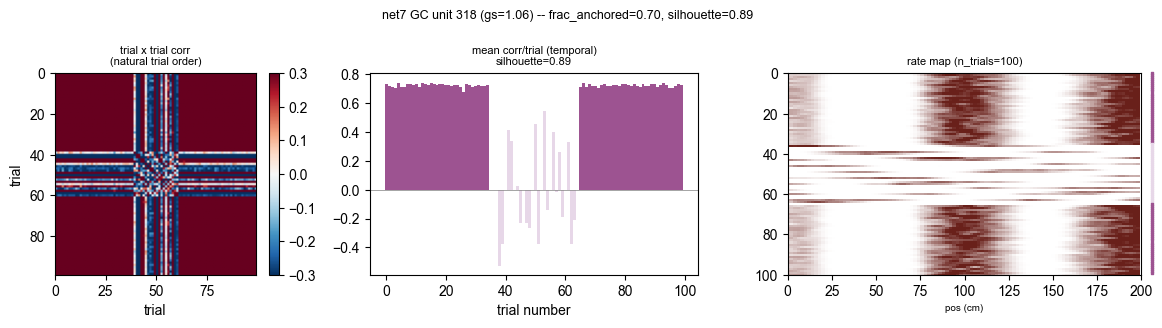

  unit 318: accuracy vs ground truth = 100.0%


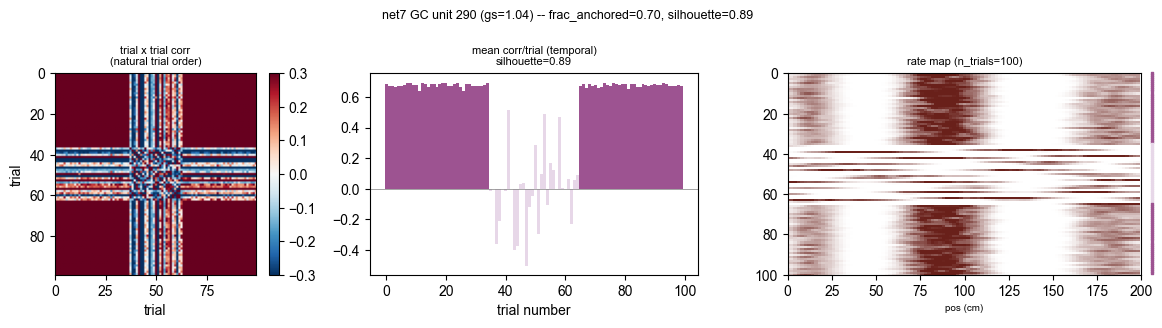

  unit 290: accuracy vs ground truth = 100.0%


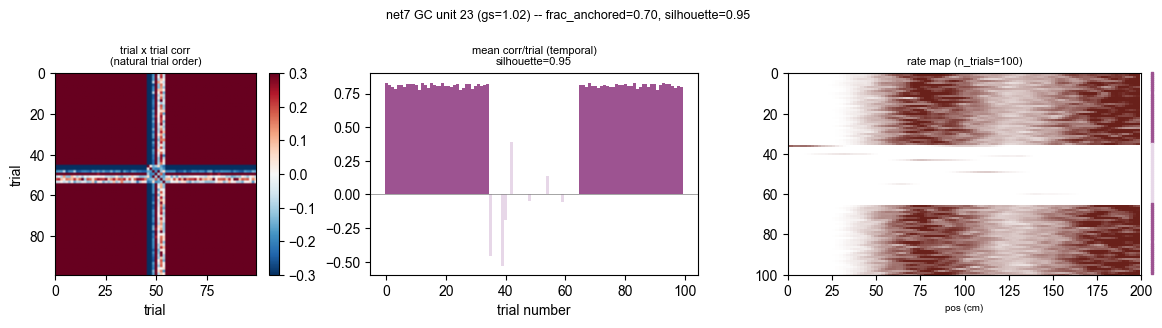

  unit 23: accuracy vs ground truth = 100.0%


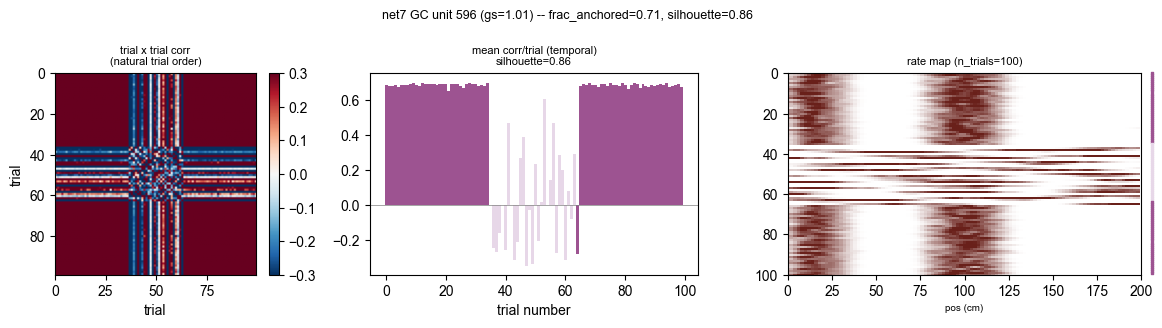

  unit 596: accuracy vs ground truth = 99.0%


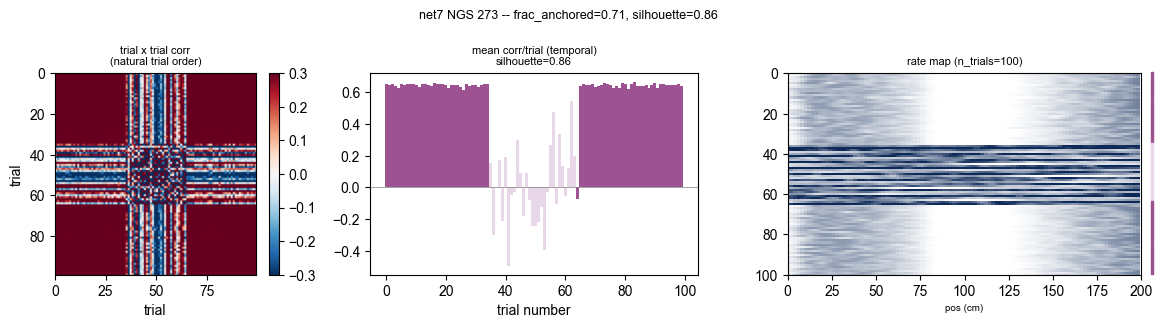

  unit 273: accuracy vs ground truth = 99.0%


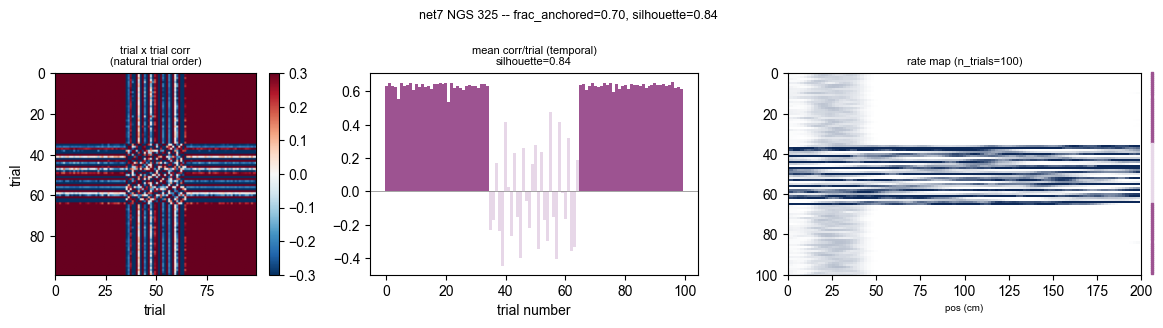

  unit 325: accuracy vs ground truth = 100.0%


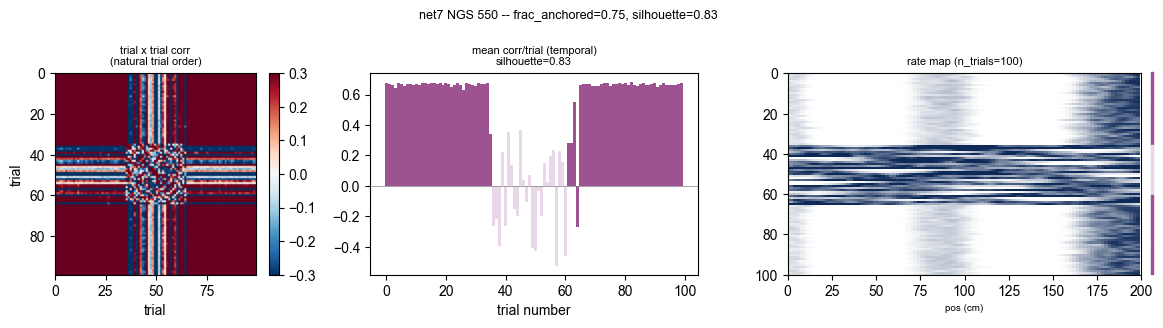

  unit 550: accuracy vs ground truth = 95.0%


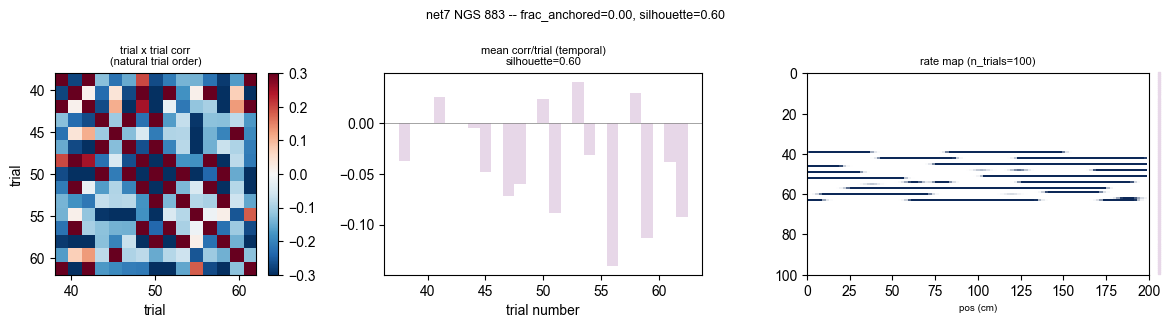

  unit 883: accuracy vs ground truth = 30.0%


In [4]:
"""Clustering diagnostics for example simulated units -- with ground truth
accuracy printed alongside since we know the true anchored/non-anchored
phase for every trial in this synthetic session."""
for u in sim_grid_examples:
    labels, mean_corr, sil = plot_clustering_diagnostics(
        all_unit_tc_switch[u], f'net7 GC unit {u} (gs={grid_scores[u]:.2f})',
        GC_COLOR, savepath=os.path.join(FIGPATH, f'trial_cluster_net7_GC_{u}.pdf'))
    valid = ~np.isnan(labels)
    acc = (labels[valid] == true_anchored[valid]).mean()
    print(f'  unit {u}: accuracy vs ground truth = {acc:.1%}')

for u in sim_nongrid_examples:
    labels, mean_corr, sil = plot_clustering_diagnostics(
        all_unit_tc_switch[u], f'net7 NGS {u}',
        NGS_COLOR, savepath=os.path.join(FIGPATH, f'trial_cluster_net7_NGS_{u}.pdf'))
    valid = ~np.isnan(labels)
    acc = (labels[valid] == true_anchored[valid]).mean() if valid.sum() > 0 else np.nan
    print(f'  unit {u}: accuracy vs ground truth = {acc:.1%}')


## Part B: real biological VR recording (M25 D24, no ground truth)

In [5]:
"""
Load the real biological VR session M25 D24 -- no ground truth available, so
the only way to assess the classifier here is by eye (do the clusters look
genuinely separated?) and via the silhouette score.
"""
MOUSE, DAY = 25, 24
bpt = int(vr_tl / bs)

gcs, ngs, ns, sc, ngs_ns, all_cells = cell_classification_of1(MOUSE, DAY, percentile_threshold=95, verbose=False)
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False, source_path=SOURCE_PATH)
n_trials_bio = last_ephys_bin // bpt
print(f'M{MOUSE}D{DAY}: GC={len(gcs)}, NGS={len(ngs)}, NS={len(ns)}, n_trials={n_trials_bio}')

def get_raw_trials(cluster_id):
    tc = tcs[int(cluster_id)][:n_trials_bio * bpt]
    return tc.reshape(n_trials_bio, bpt)


M25D24: GC=22, NGS=37, NS=4, n_trials=225


GC examples: [np.int64(112), np.int64(124), np.int64(128), np.int64(130)]
NGS examples: [np.int64(113), np.int64(115), np.int64(117), np.int64(119)]


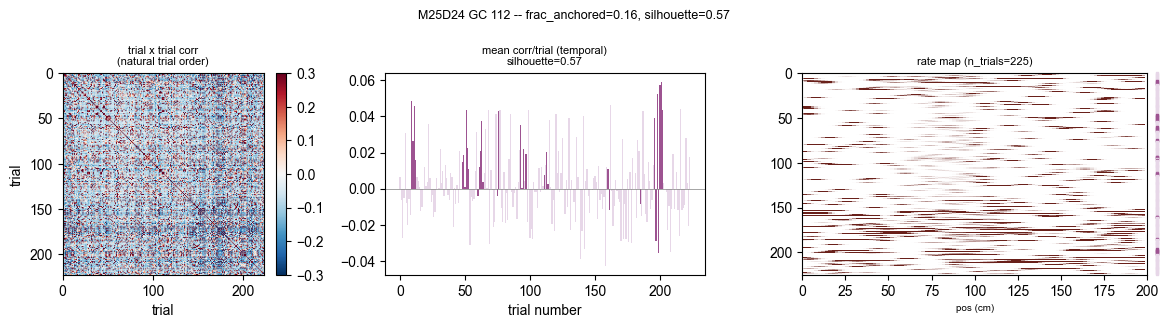

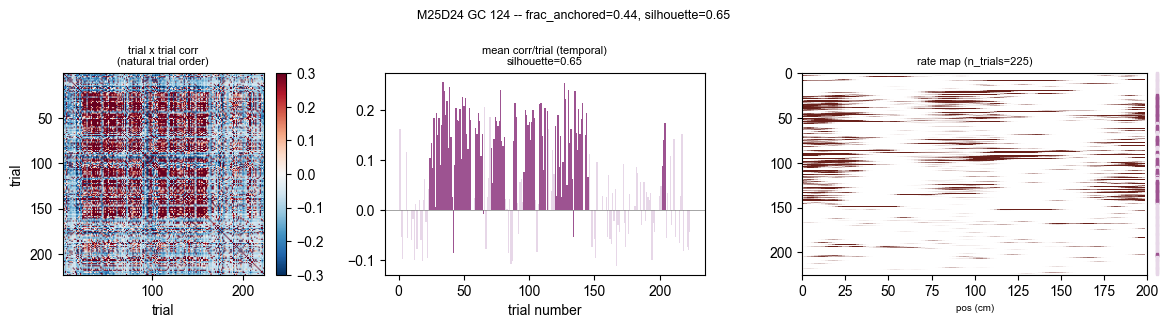

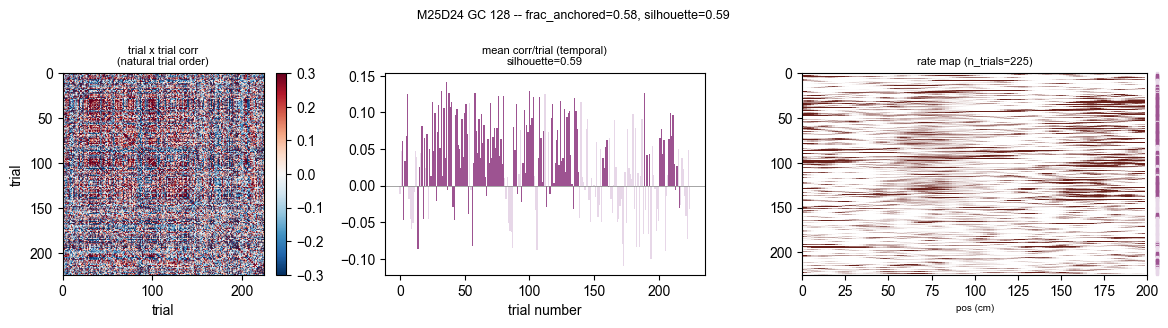

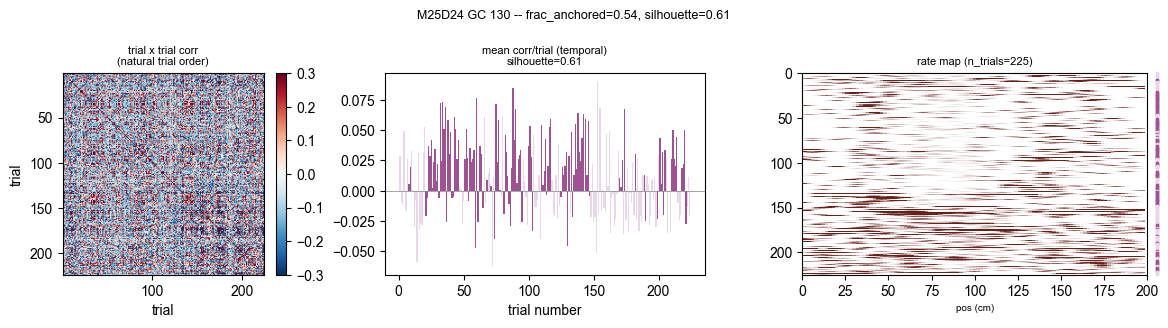

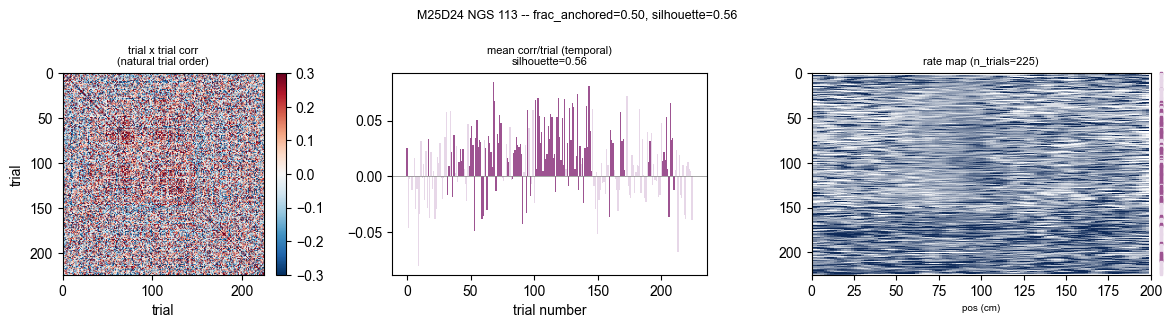

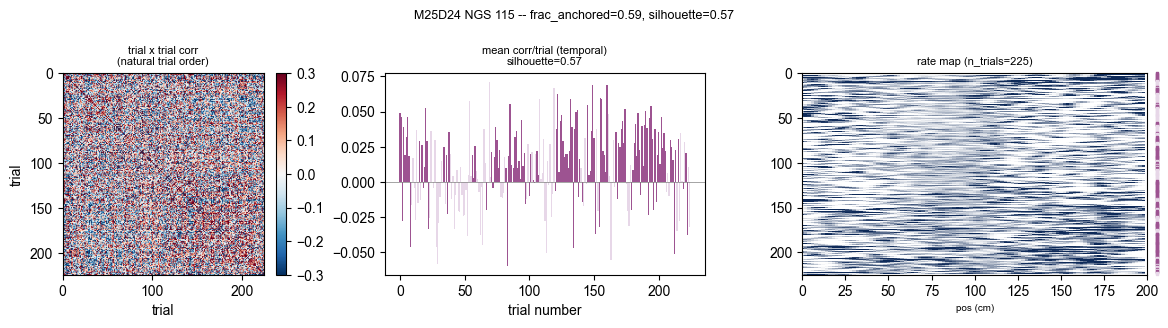

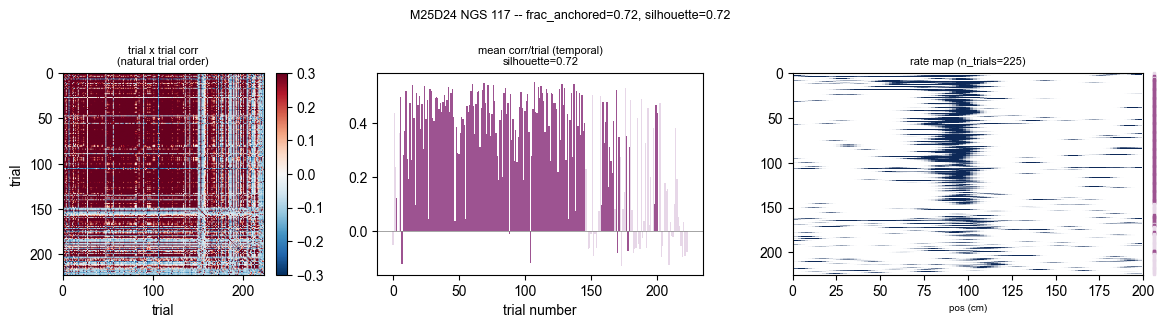

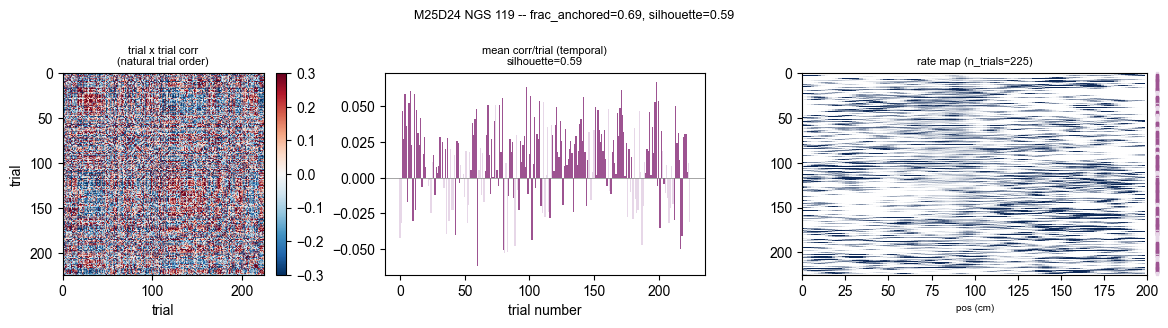

In [6]:
"""Clustering diagnostics for example real GC and NGS cells (first 4 of
each, by cluster_id -- a deterministic, unselected sample, not cherry-picked
for good separation)."""
bio_gc_examples = sorted(gcs.cluster_id.values.astype(int))[:4]
bio_ngs_examples = sorted(ngs.cluster_id.values.astype(int))[:4]

print('GC examples:', bio_gc_examples)
print('NGS examples:', bio_ngs_examples)

for cid in bio_gc_examples:
    if cid not in tcs:
        continue
    plot_clustering_diagnostics(get_raw_trials(cid), f'M{MOUSE}D{DAY} GC {cid}', GC_COLOR,
                                 savepath=os.path.join(FIGPATH, f'trial_cluster_M{MOUSE}D{DAY}_GC_{cid}.pdf'))

for cid in bio_ngs_examples:
    if cid not in tcs:
        continue
    plot_clustering_diagnostics(get_raw_trials(cid), f'M{MOUSE}D{DAY} NGS {cid}', NGS_COLOR,
                                 savepath=os.path.join(FIGPATH, f'trial_cluster_M{MOUSE}D{DAY}_NGS_{cid}.pdf'))


GC (n=22): silhouette mean=0.63, median=0.64, frac with silhouette>0.3=100%
NGS (n=37): silhouette mean=0.60, median=0.59, frac with silhouette>0.3=100%


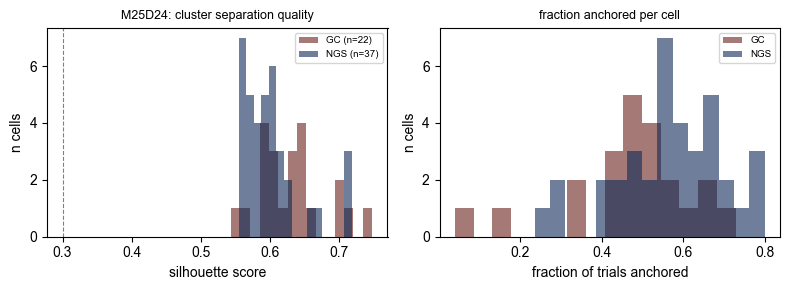

In [7]:
"""
Population-level separation quality across ALL GC and NGS cells in this
session (not just the 8 examples above) -- silhouette score distribution and
fraction-anchored distribution, to see whether good separation is typical or
exceptional for this session.
"""
def summarize_population(cell_df, label):
    sils, fracs = [], []
    for cid in cell_df.cluster_id.values.astype(int):
        if cid not in tcs:
            continue
        labels, mean_corr, smoothed, sil = trial_cluster_labels(get_raw_trials(cid))
        if np.isnan(sil):
            continue
        sils.append(sil)
        fracs.append(np.nanmean(labels))
    return np.array(sils), np.array(fracs)

gc_sils, gc_fracs = summarize_population(gcs, 'GC')
ngs_sils, ngs_fracs = summarize_population(ngs, 'NGS')
print(f'GC (n={len(gc_sils)}): silhouette mean={gc_sils.mean():.2f}, median={np.median(gc_sils):.2f}, '
      f'frac with silhouette>0.3={np.mean(gc_sils>0.3):.0%}')
print(f'NGS (n={len(ngs_sils)}): silhouette mean={ngs_sils.mean():.2f}, median={np.median(ngs_sils):.2f}, '
      f'frac with silhouette>0.3={np.mean(ngs_sils>0.3):.0%}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
ax = axes[0]
ax.hist(gc_sils, bins=15, color=GC_COLOR, alpha=0.6, label=f'GC (n={len(gc_sils)})')
ax.hist(ngs_sils, bins=15, color=NGS_COLOR, alpha=0.6, label=f'NGS (n={len(ngs_sils)})')
ax.axvline(0.3, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('silhouette score'); ax.set_ylabel('n cells')
ax.set_title(f'M{MOUSE}D{DAY}: cluster separation quality', fontsize=9)
ax.legend(fontsize=7)

ax = axes[1]
ax.hist(gc_fracs, bins=15, color=GC_COLOR, alpha=0.6, label='GC')
ax.hist(ngs_fracs, bins=15, color=NGS_COLOR, alpha=0.6, label='NGS')
ax.set_xlabel('fraction of trials anchored'); ax.set_ylabel('n cells')
ax.set_title('fraction anchored per cell', fontsize=9)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, f'trial_cluster_M{MOUSE}D{DAY}_population_summary.pdf'), bbox_inches='tight', dpi=200)
plt.show()


## Part C: total population raster, sorted by correlation to PC1

Every cell's anchored/non-anchored label across every trial, for the FULL
population (all 1024 net7 units; all classified cells in M25 D24), sorted by
each cell's correlation to PC1 of the population's label matrix -- revealing
whether anchoring is a population-wide, shared signal (cells sorted smoothly
from strong-follower to non-follower) or scattered/idiosyncratic (no clean
gradient).

In [8]:
"""
Total population raster: every cell's anchored/non-anchored label across
every trial, sorted by that cell's correlation to PC1 of the population's
label matrix (cells x trials, 0/1). PC1 captures the dominant SHARED
across-cell pattern (e.g. a population-wide switch on/off); sorting by
correlation to it reveals which cells follow that dominant pattern most
strongly (top rows) versus weakly or oppositely (bottom rows) -- i.e. whether
anchoring is a population-wide phenomenon or scattered/idiosyncratic.
"""
def population_raster_pc1_sorted(list_of_raw_trials, title, save_name, transitions=None):
    label_matrix = np.array([trial_cluster_labels(rt)[0] for rt in list_of_raw_trials])
    M = np.nan_to_num(label_matrix, nan=0.0)
    pca = PCA(n_components=1).fit(M)
    pc1 = pca.components_[0]
    corrs = np.array([np.corrcoef(M[i], pc1)[0, 1] if M[i].std() > 0 else 0.0 for i in range(M.shape[0])])
    order = np.argsort(-corrs)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(label_matrix[order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    if transitions:
        for tline in transitions:
            ax.axvline(tline, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('trial number')
    ax.set_ylabel(f'cell (n={len(list_of_raw_trials)}, sorted by corr. to PC1)')
    ax.set_title(f'{title}\nPC1 explains {pca.explained_variance_ratio_[0]:.0%} of label variance, '
                 f'corr. to PC1 range=[{corrs.min():.2f}, {corrs.max():.2f}]', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_name, dpi=200, bbox_inches='tight')
    plt.show()
    return label_matrix, corrs, order


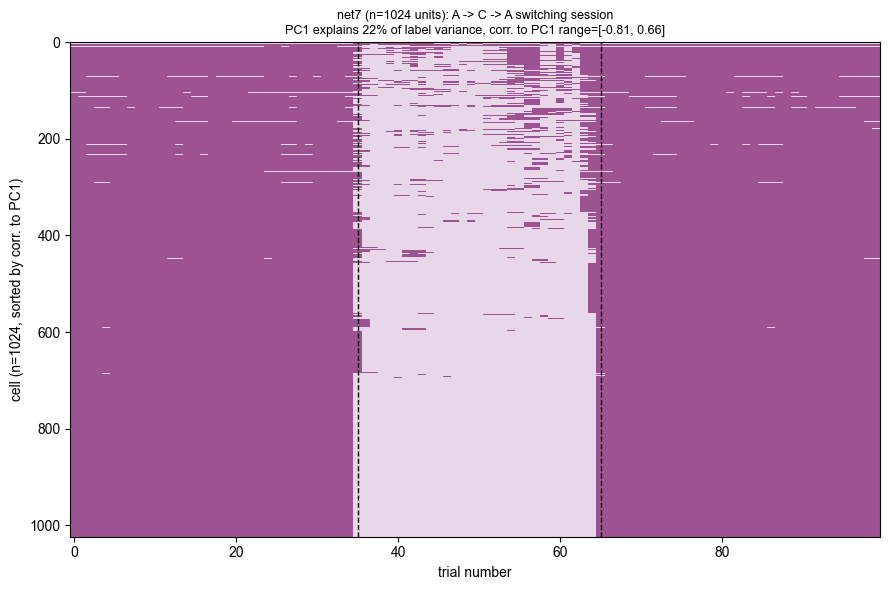

In [9]:
"""Total population raster, simulated net7 (ALL Ng=1024 units, switching session)."""
sim_raw_trials_list = [all_unit_tc_switch[u] for u in range(all_unit_tc_switch.shape[0])]
sim_label_matrix, sim_corrs, sim_order = population_raster_pc1_sorted(
    sim_raw_trials_list, f'net7 (n={all_unit_tc_switch.shape[0]} units): A -> C -> A switching session',
    os.path.join(FIGPATH, 'trial_cluster_population_raster_net7.pdf'), transitions=[t1, t2])


M25D24: 63 total cells with VR data


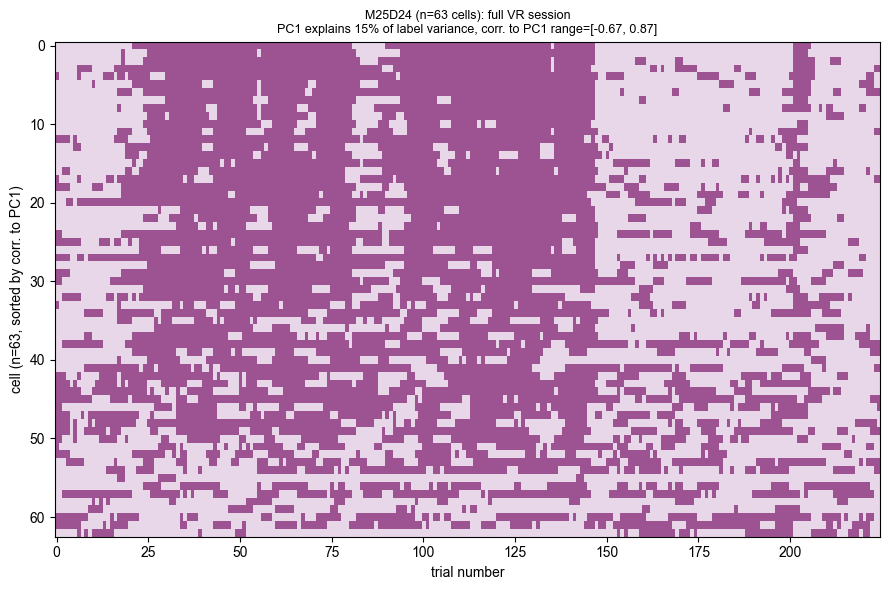

In [10]:
"""Total population raster, real biological VR recording (ALL classified cells, M25 D24)."""
bio_all_ids = sorted(set(all_cells.cluster_id.values.astype(int)) & set(tcs.keys()))
bio_raw_trials_list = [get_raw_trials(cid) for cid in bio_all_ids]
print(f'M{MOUSE}D{DAY}: {len(bio_raw_trials_list)} total cells with VR data')

bio_label_matrix, bio_corrs, bio_order = population_raster_pc1_sorted(
    bio_raw_trials_list, f'M{MOUSE}D{DAY} (n={len(bio_raw_trials_list)} cells): full VR session',
    os.path.join(FIGPATH, f'trial_cluster_population_raster_M{MOUSE}D{DAY}.pdf'))


## Part D: every session (all 75 in cell_classifications.csv)

Batch run across every VR session available, using every recorded cell (not
restricted to GC/NG classification). For each session: PC1-sorted raster
(left) and dorsoventral-sorted raster with brain-region color strip (right,
VIS/ENTs/ENTd/PARA/PRE/SUB/CERE -- ENT split into superficial (layers 1-3)
and deep (layers 5-6) since they're functionally distinct MEC layers).
Computed by `run_all_sessions_anchoring.py` (75/75 sessions succeeded, ~23
min total); shown inline below from the cached results so every session can
be reviewed by scrolling rather than opening 75 separate files.

75 sessions with cached results


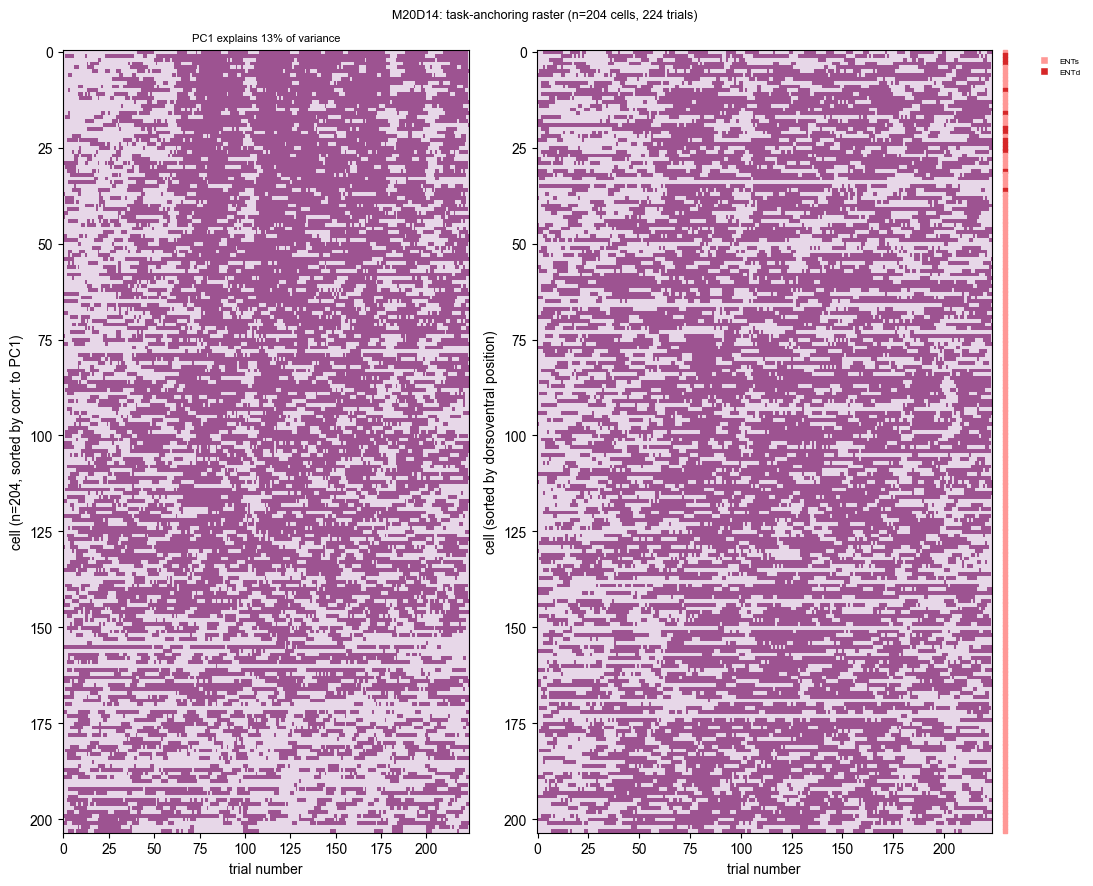

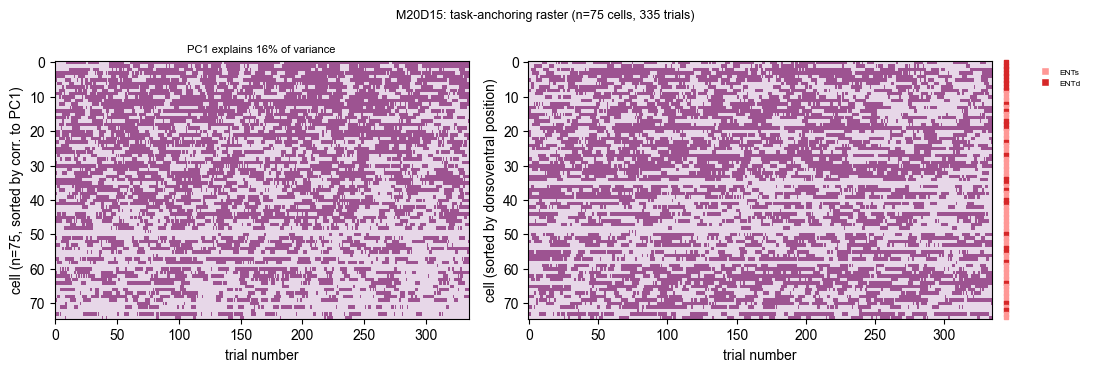

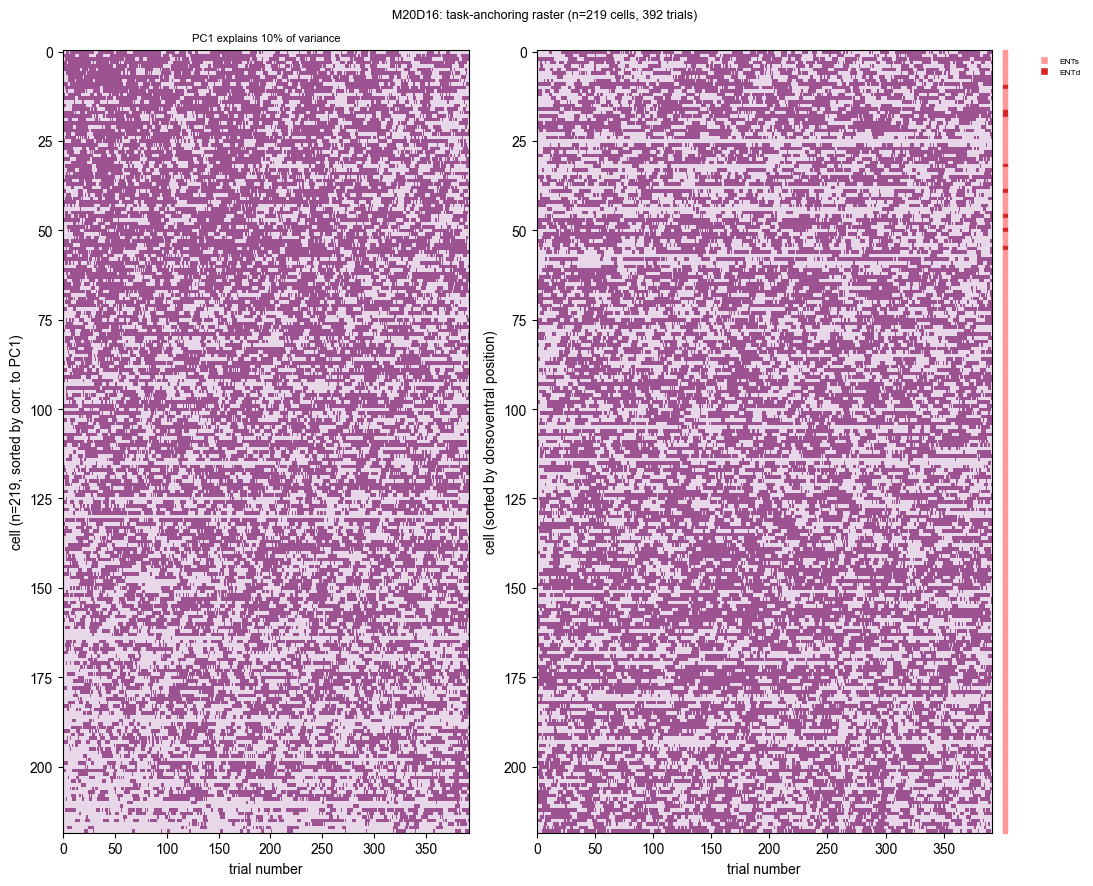

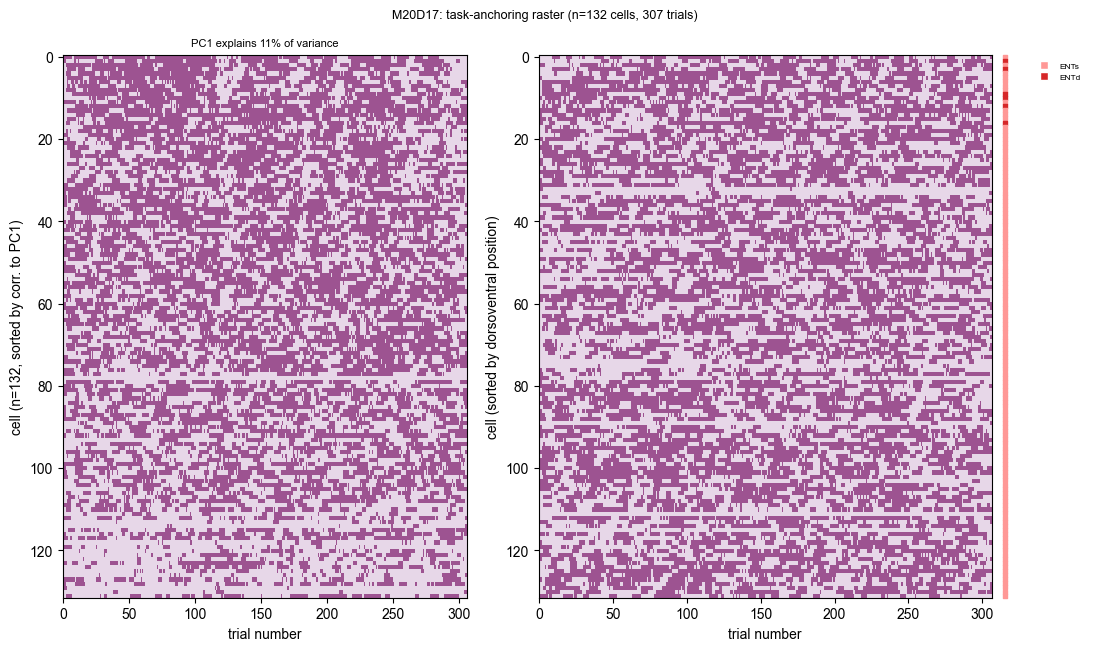

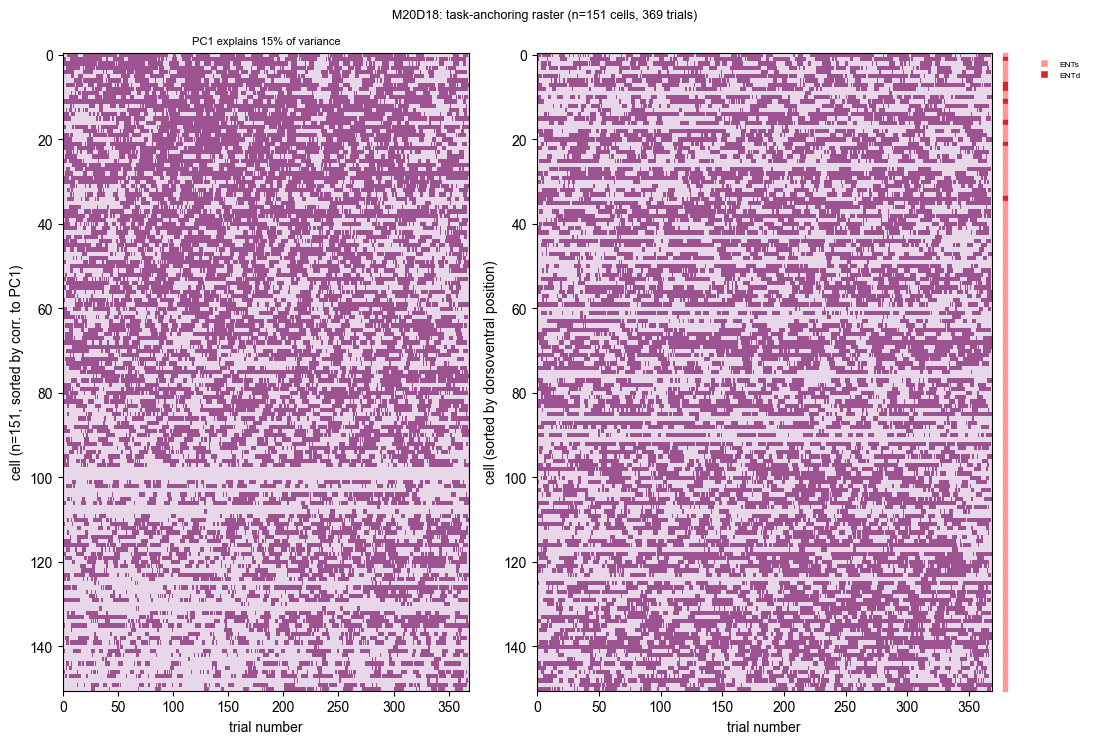

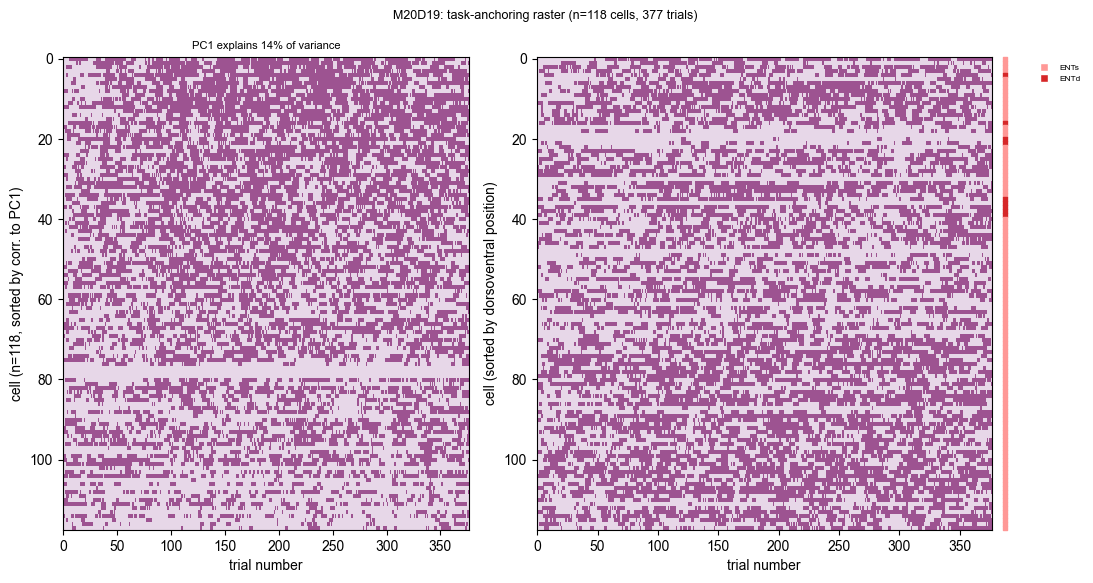

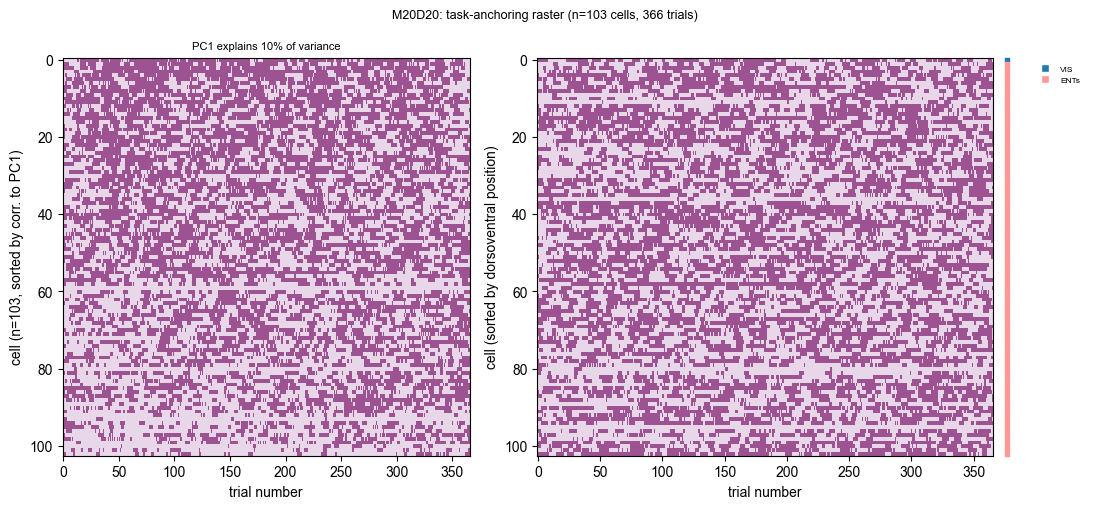

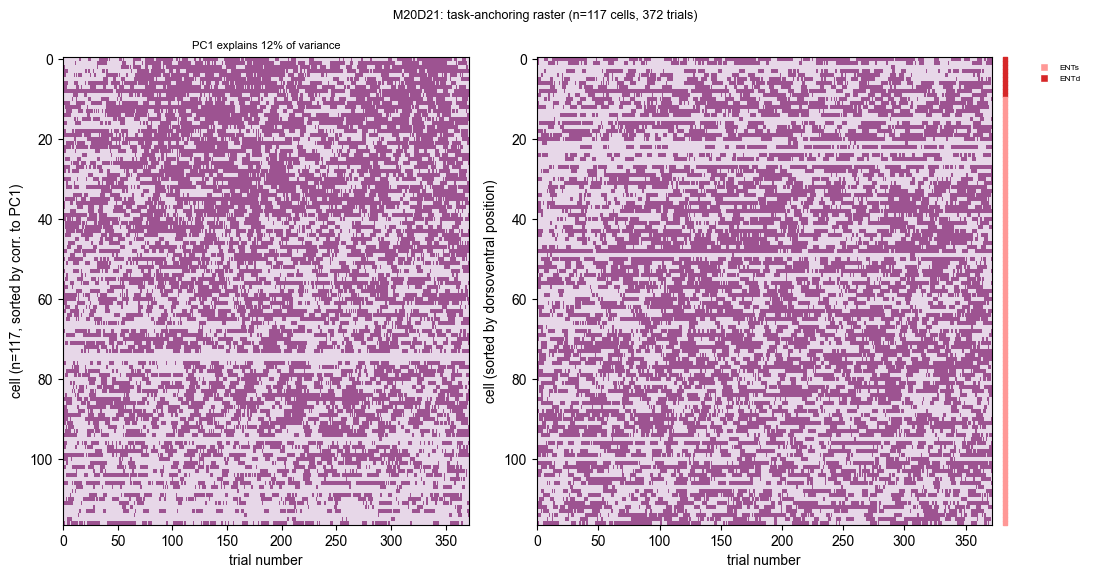

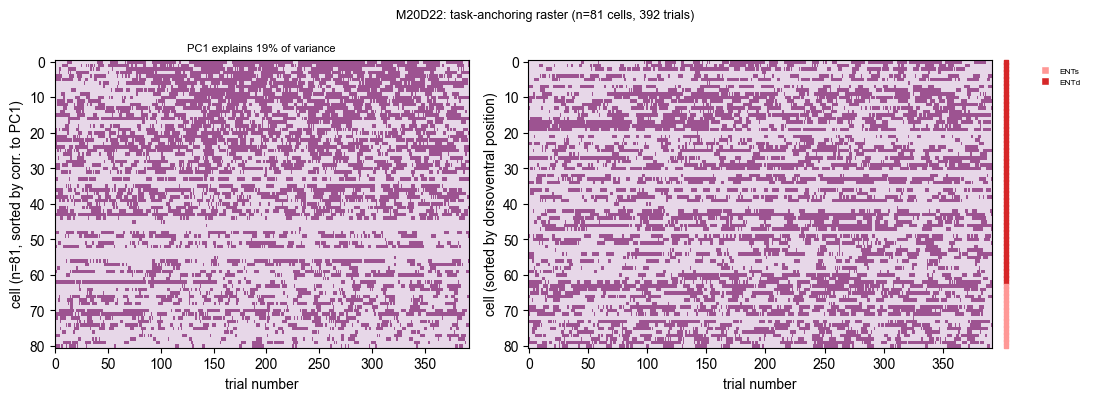

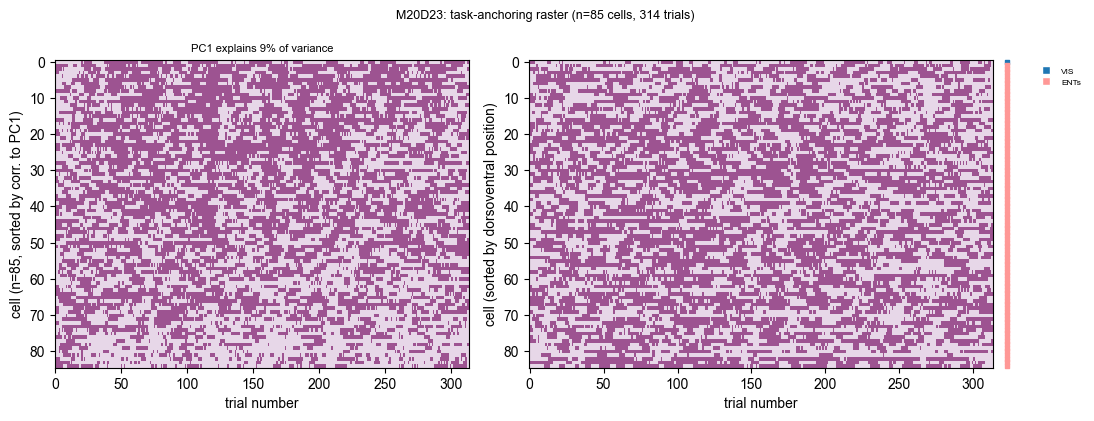

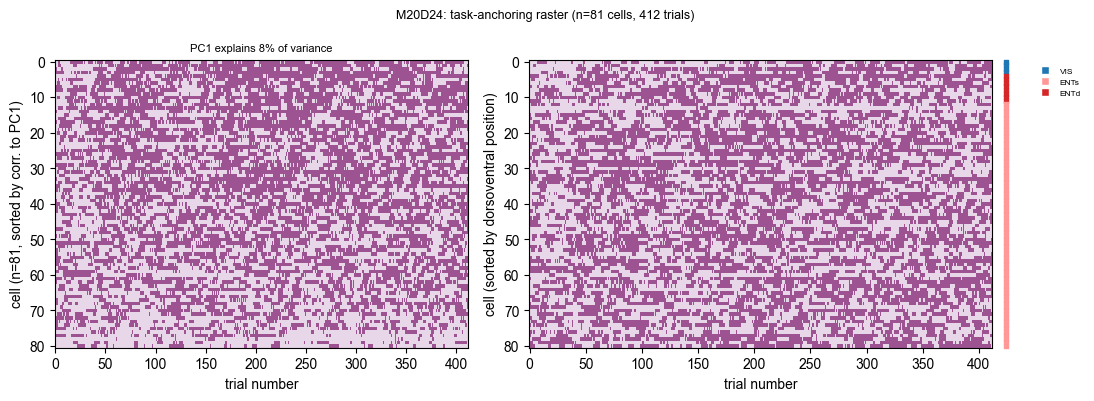

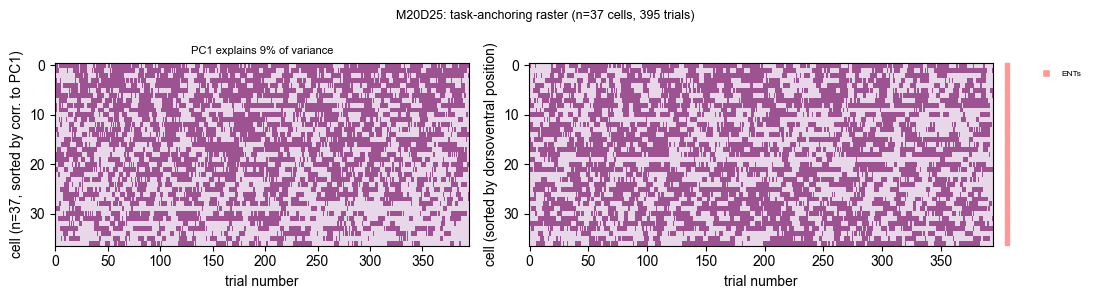

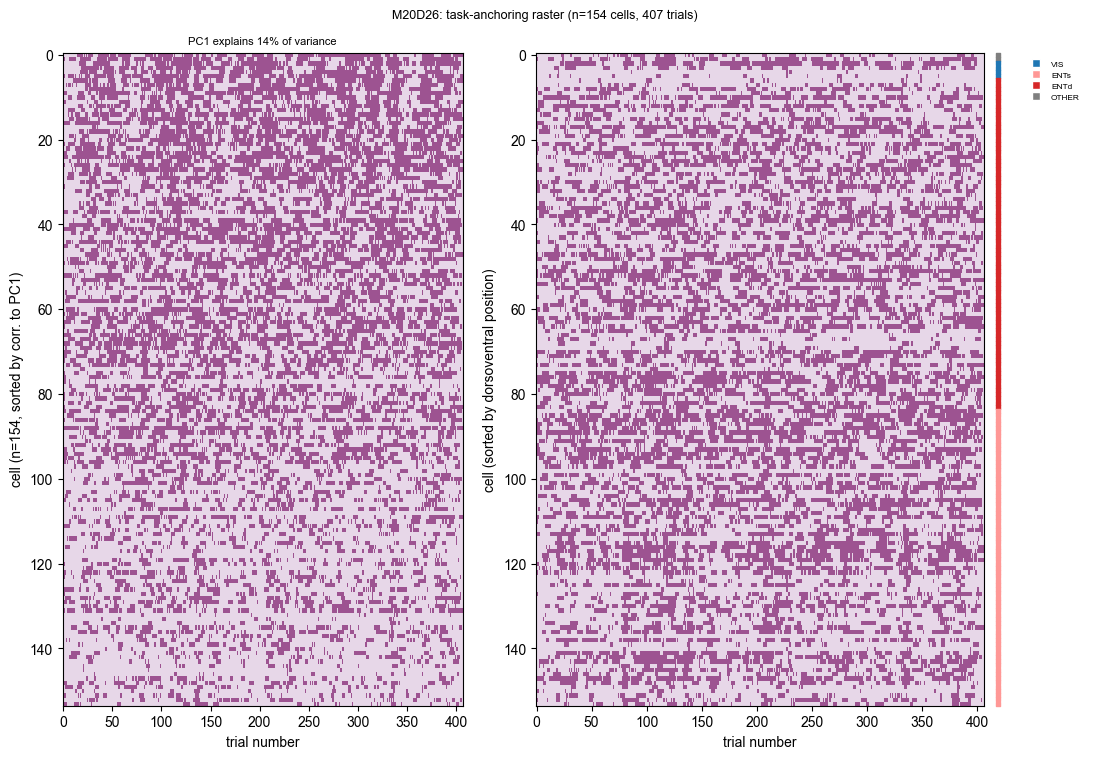

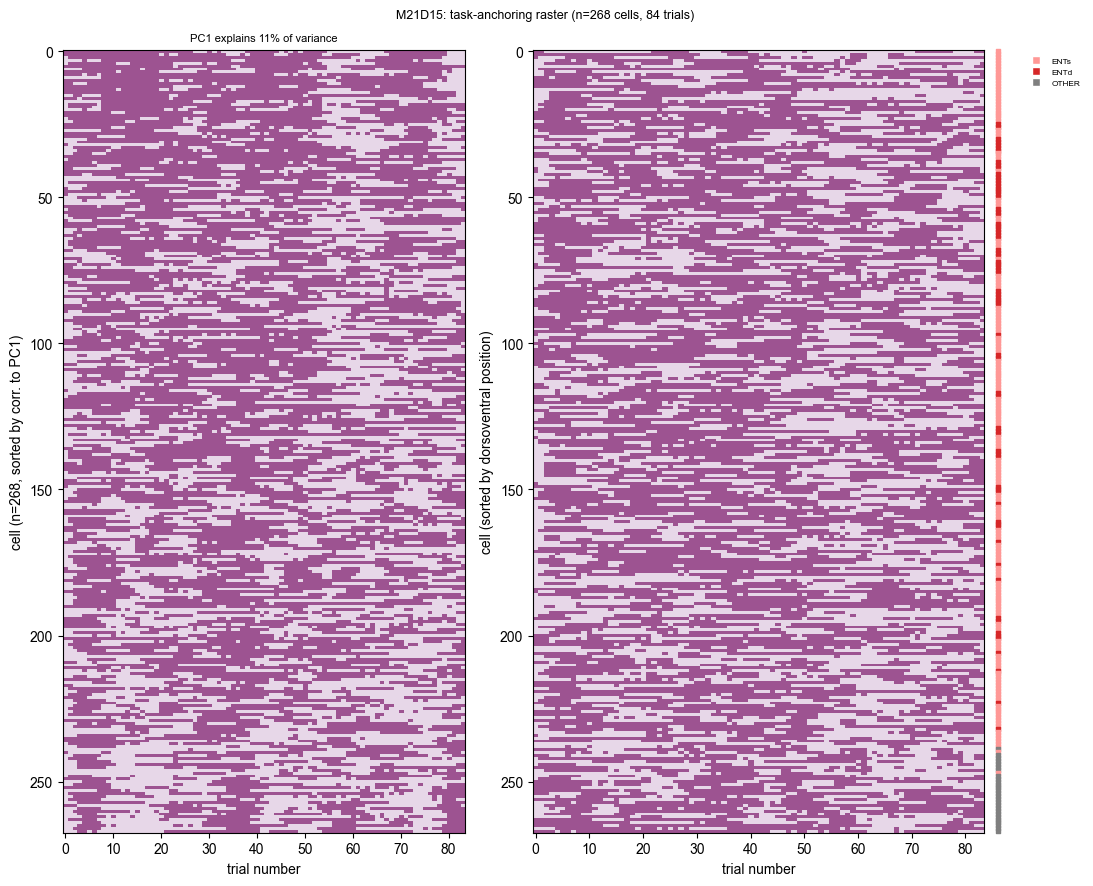

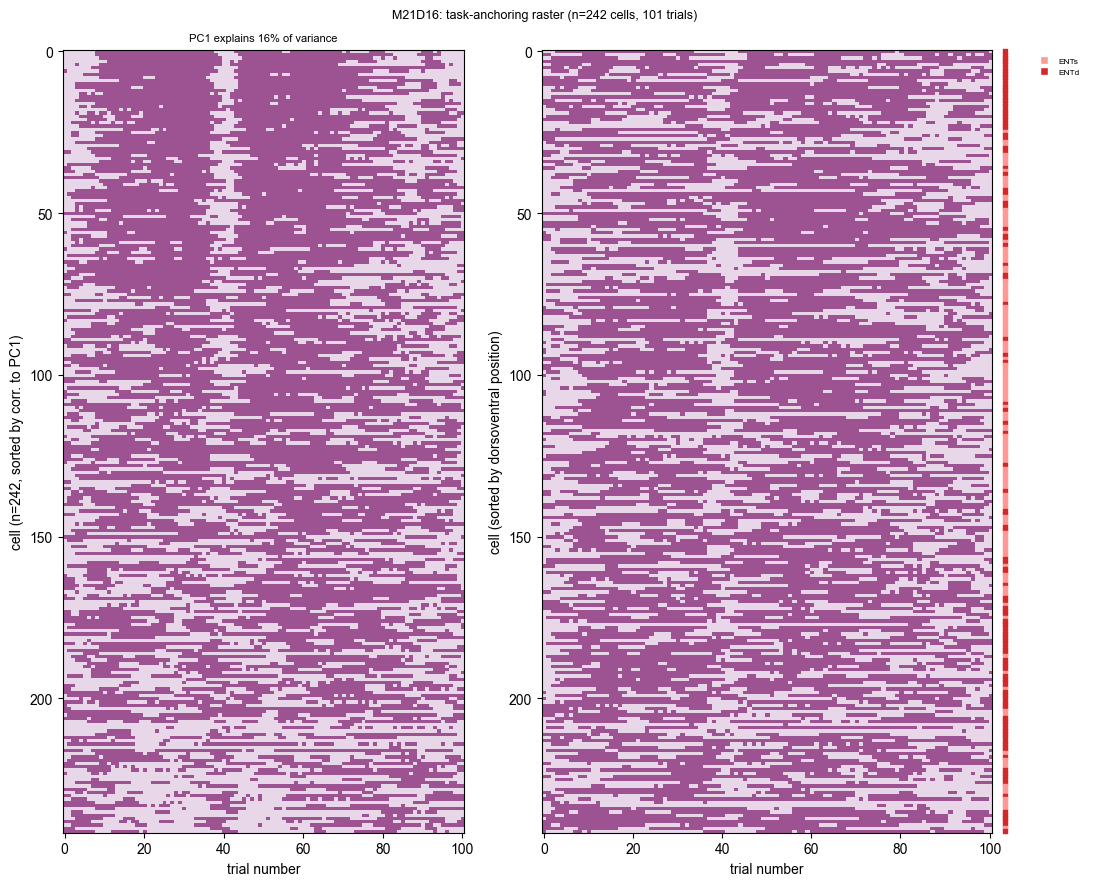

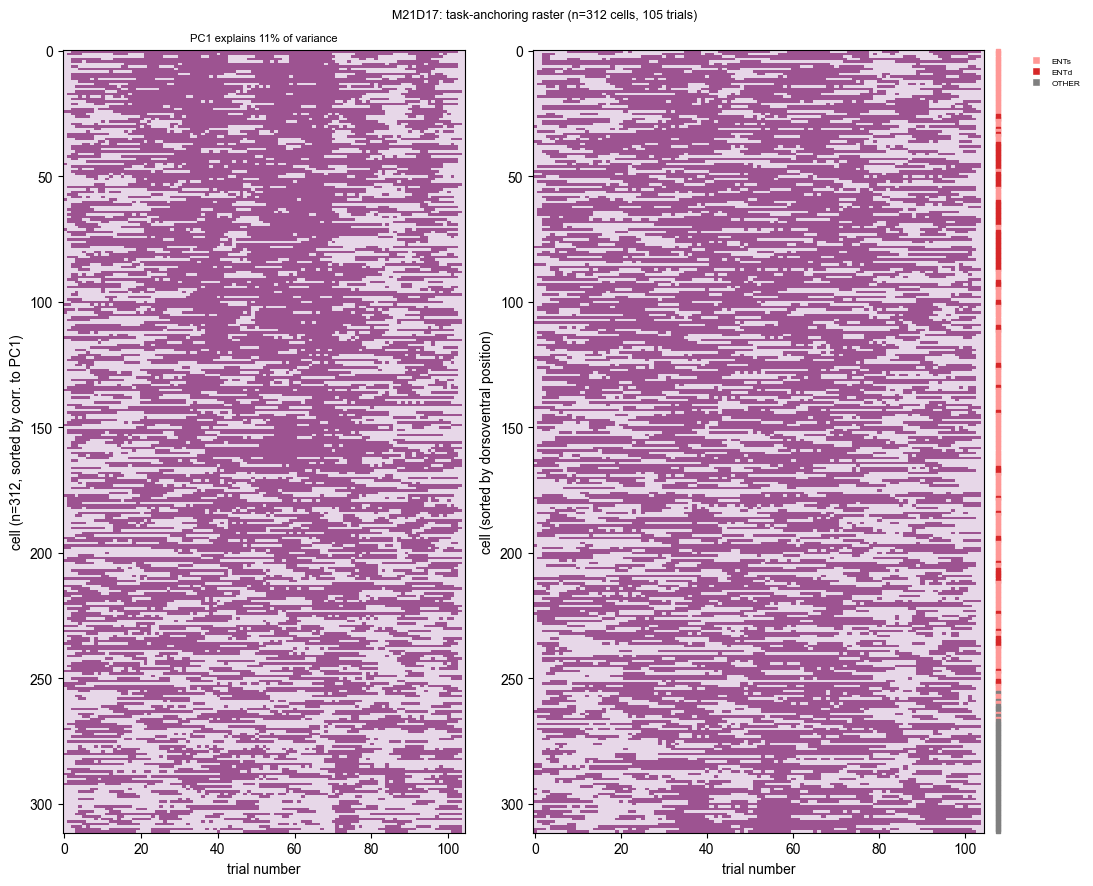

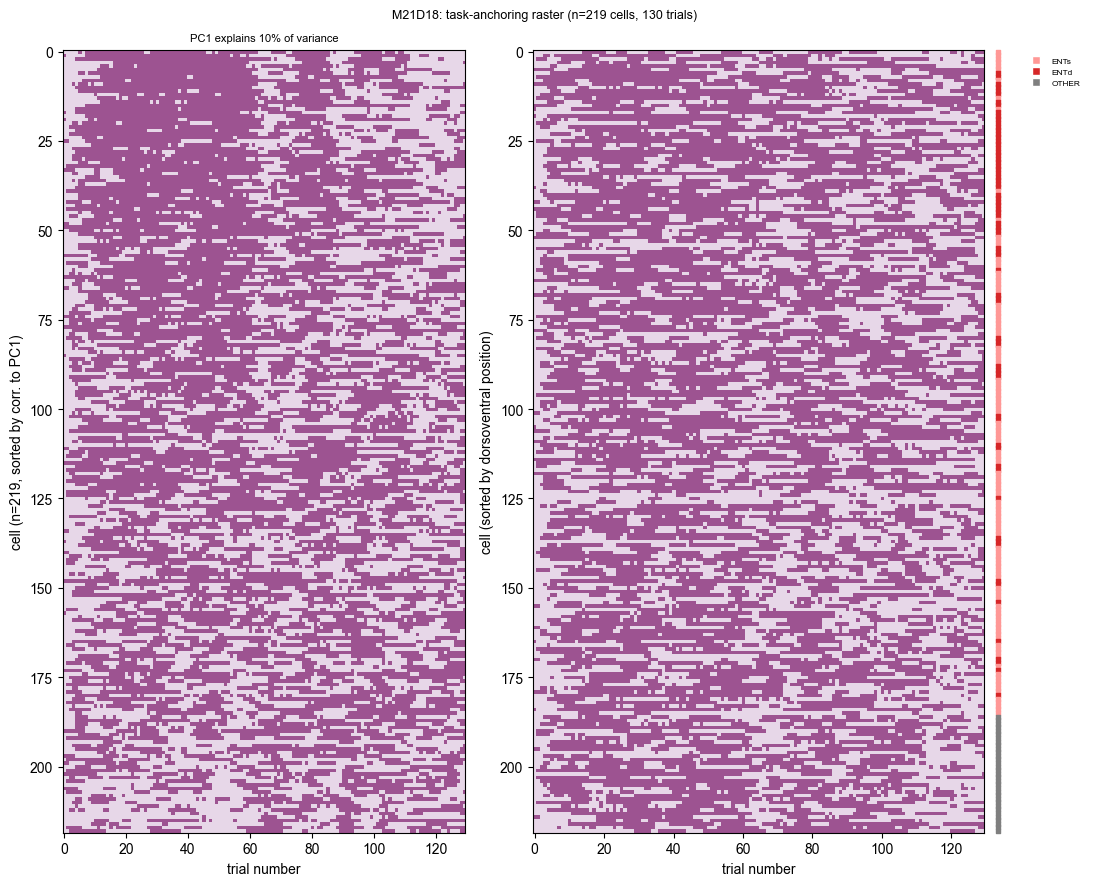

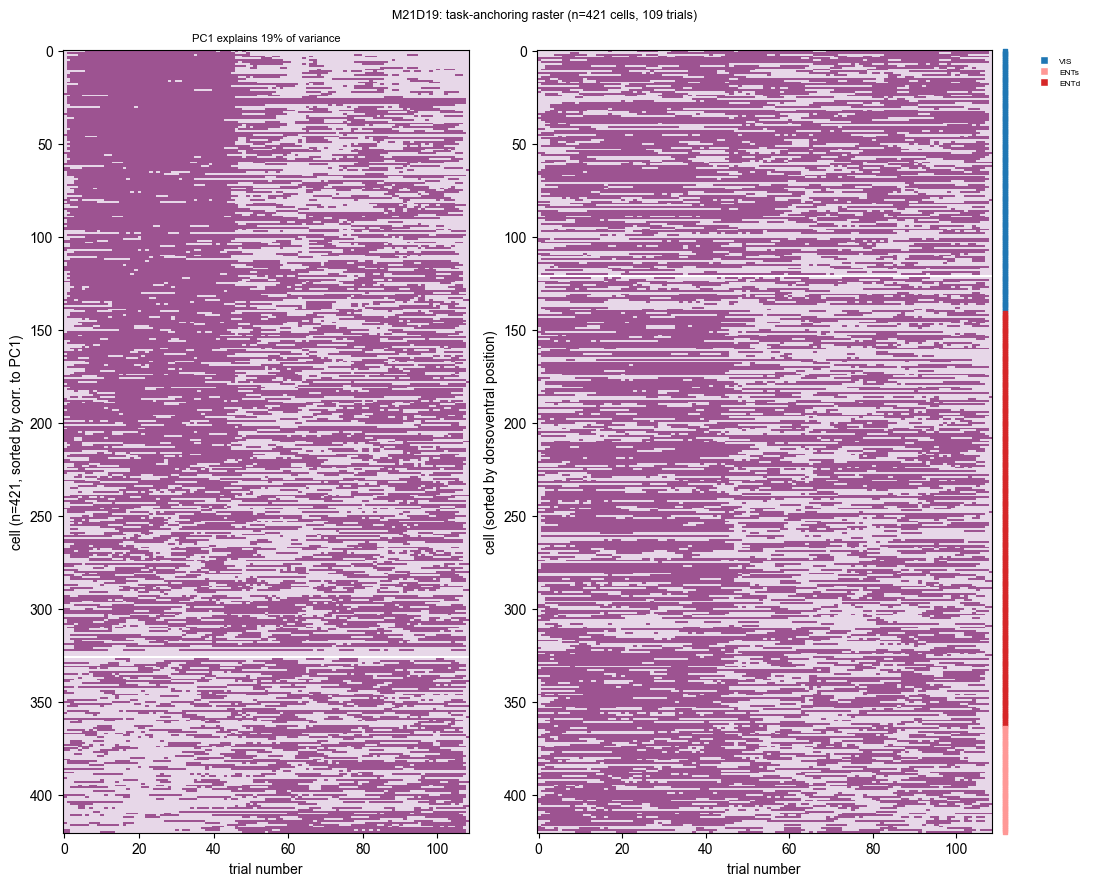

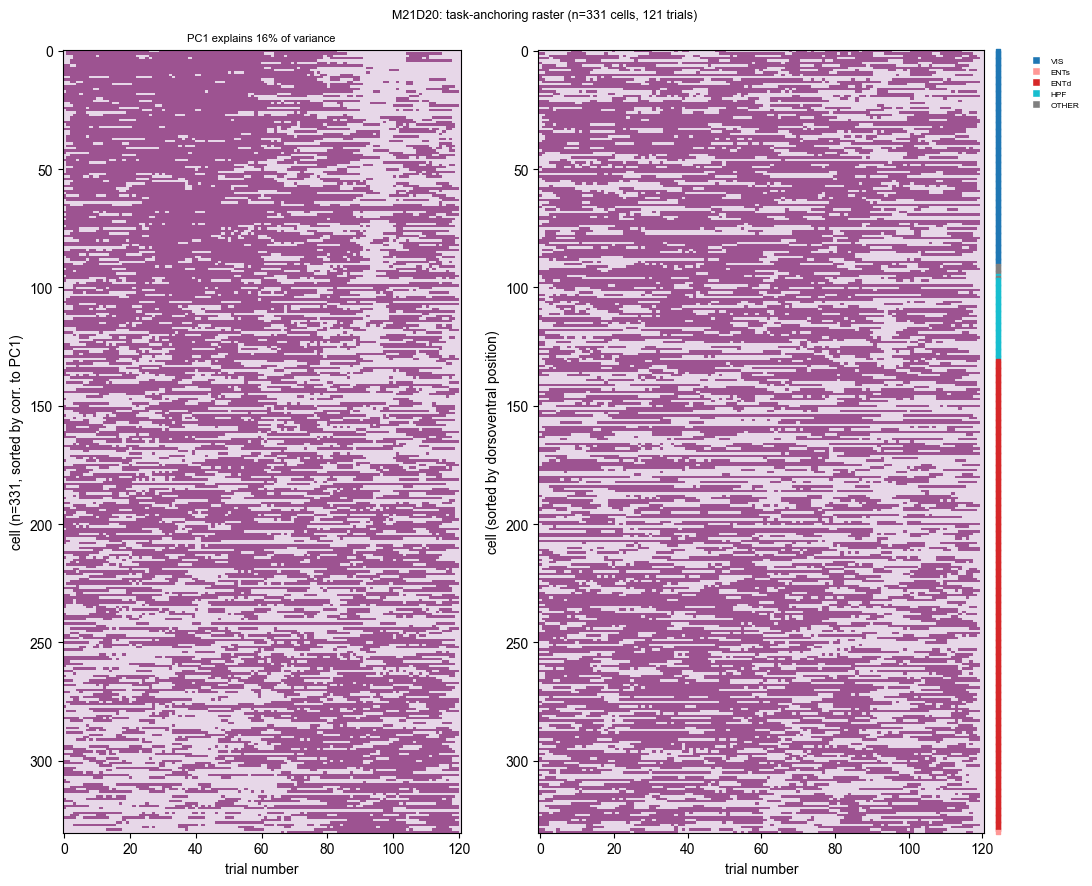

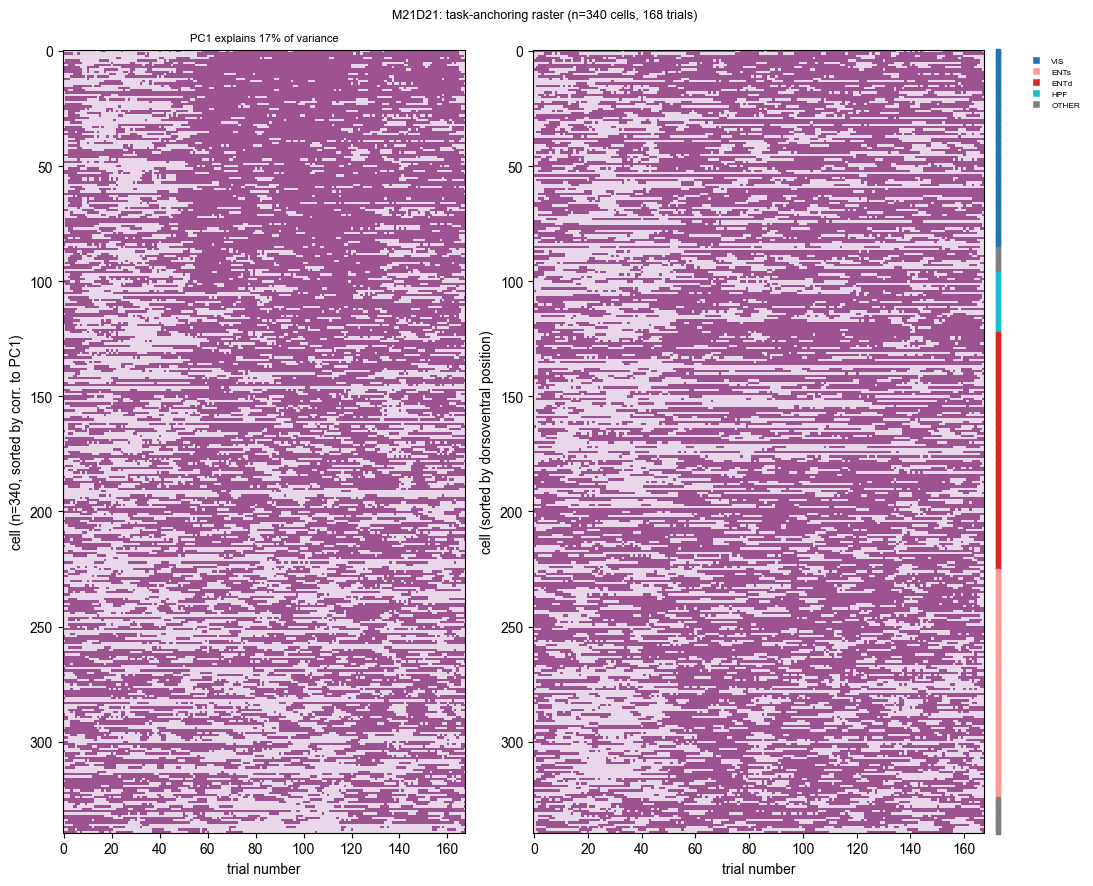

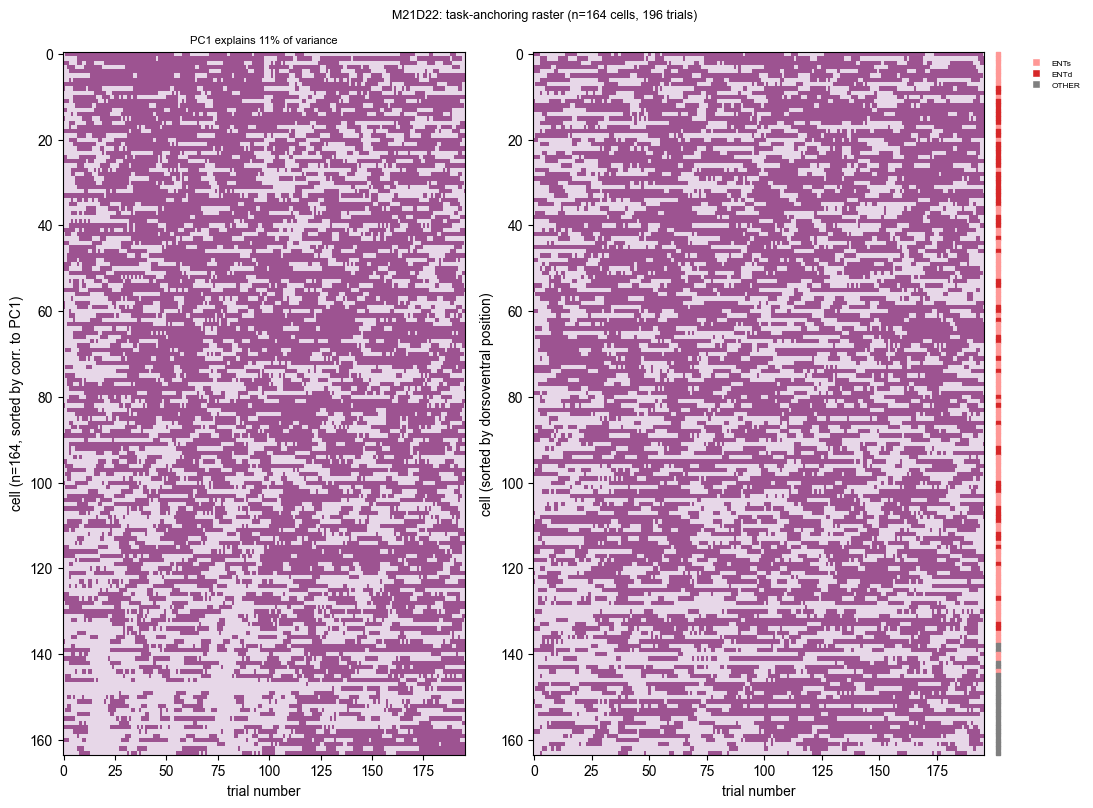

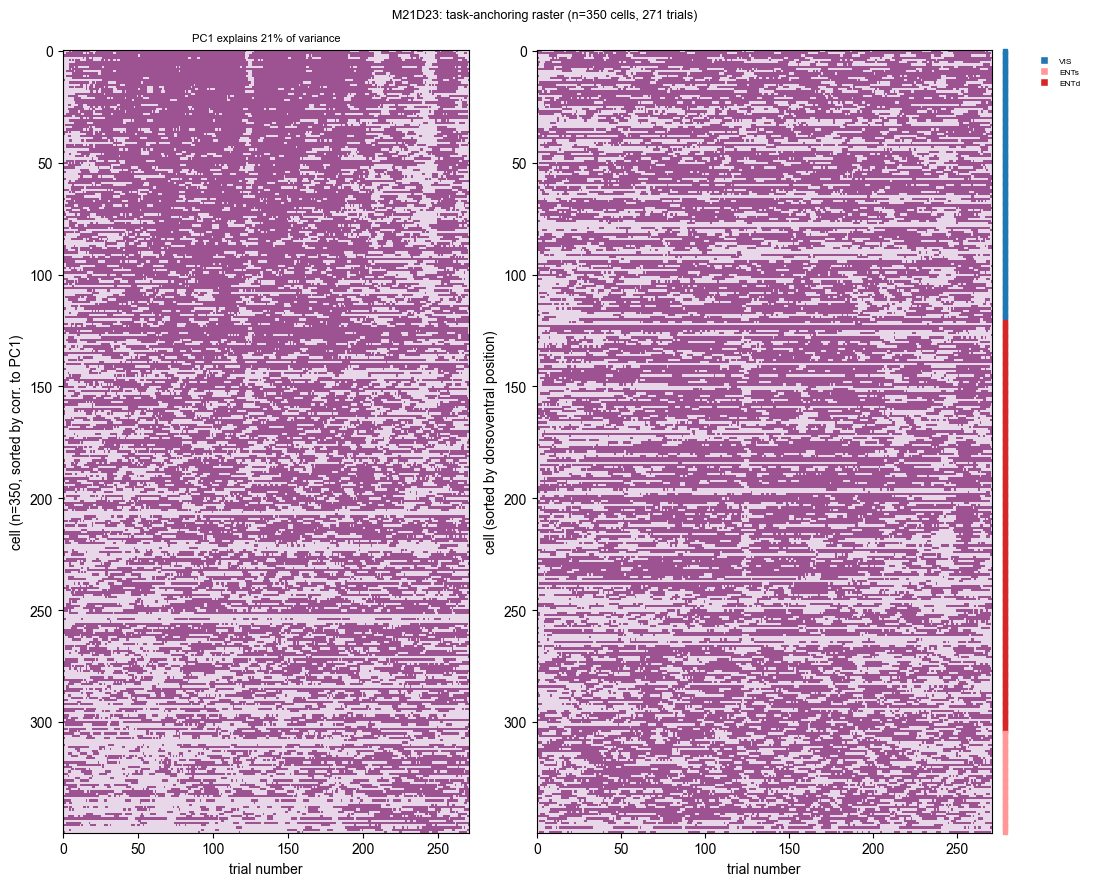

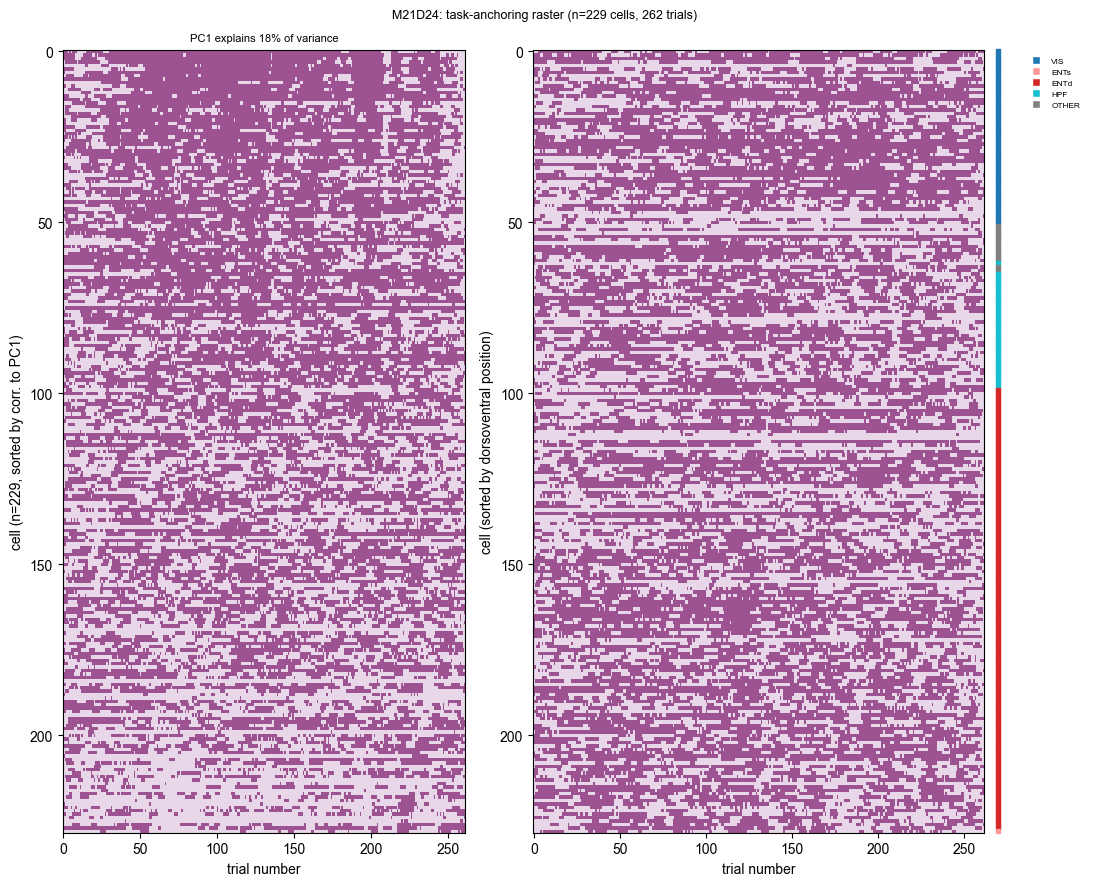

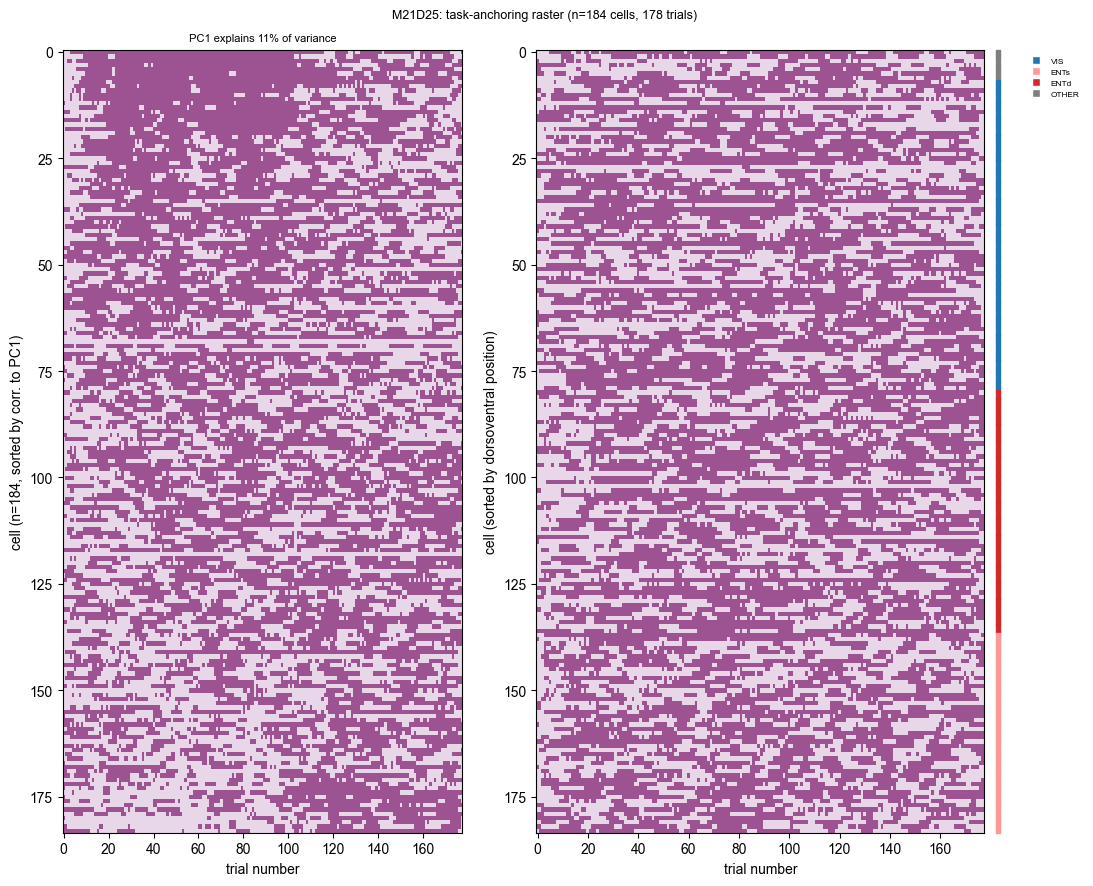

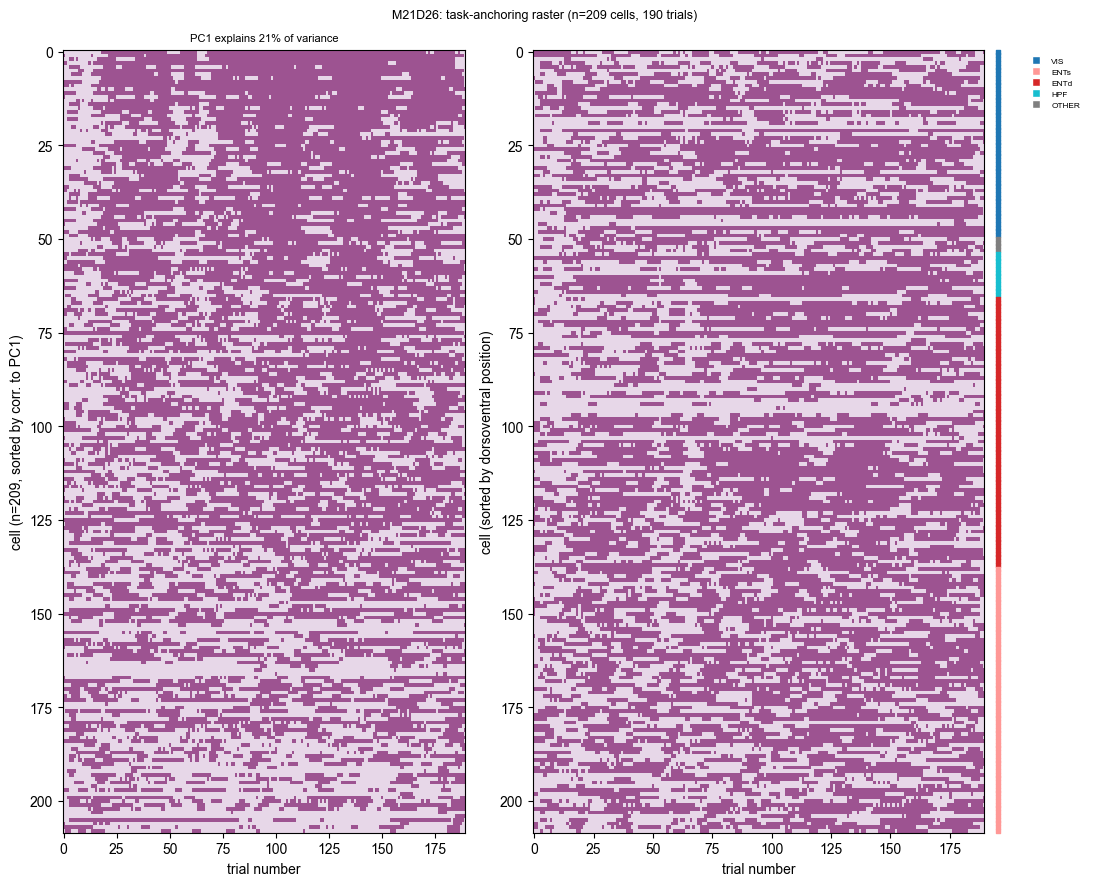

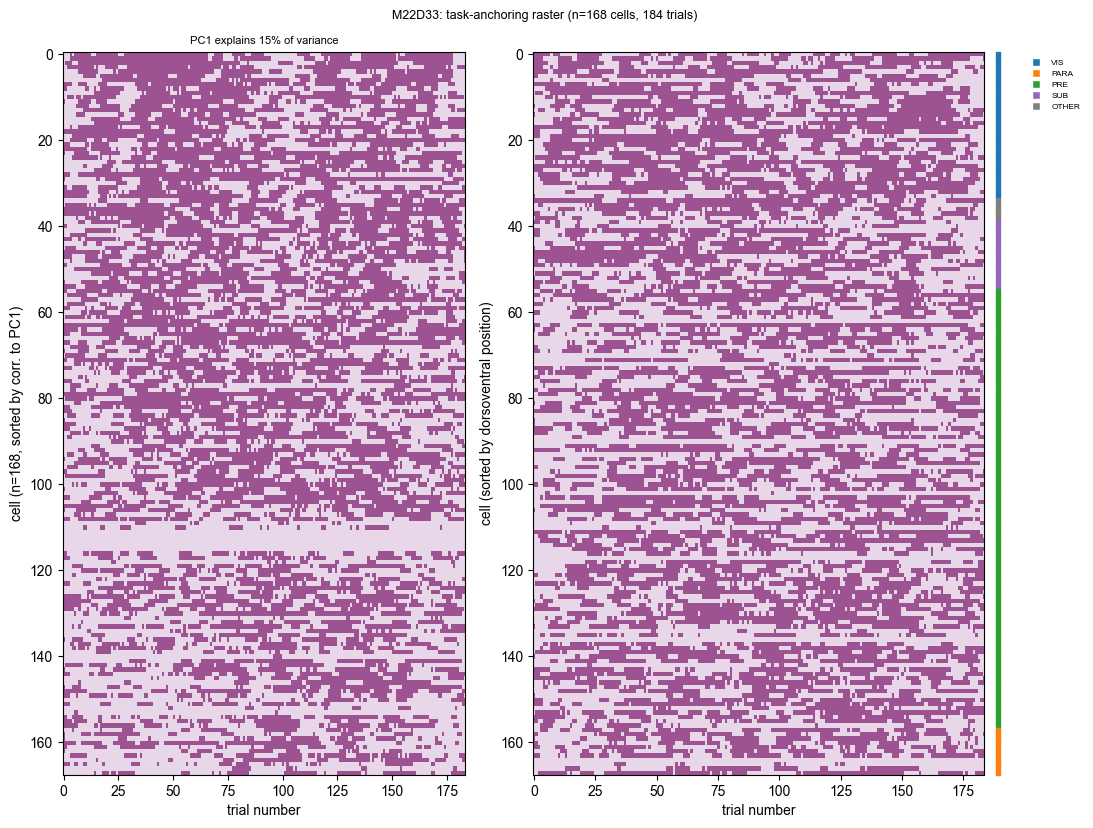

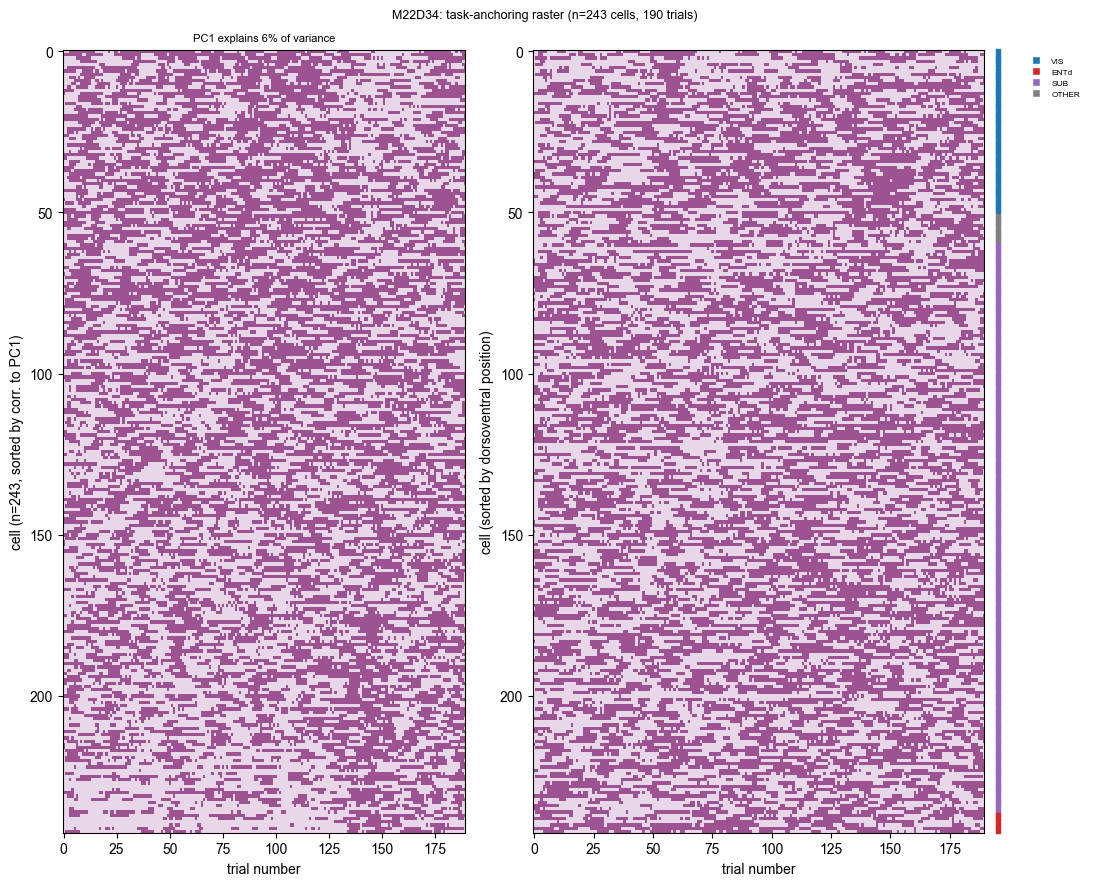

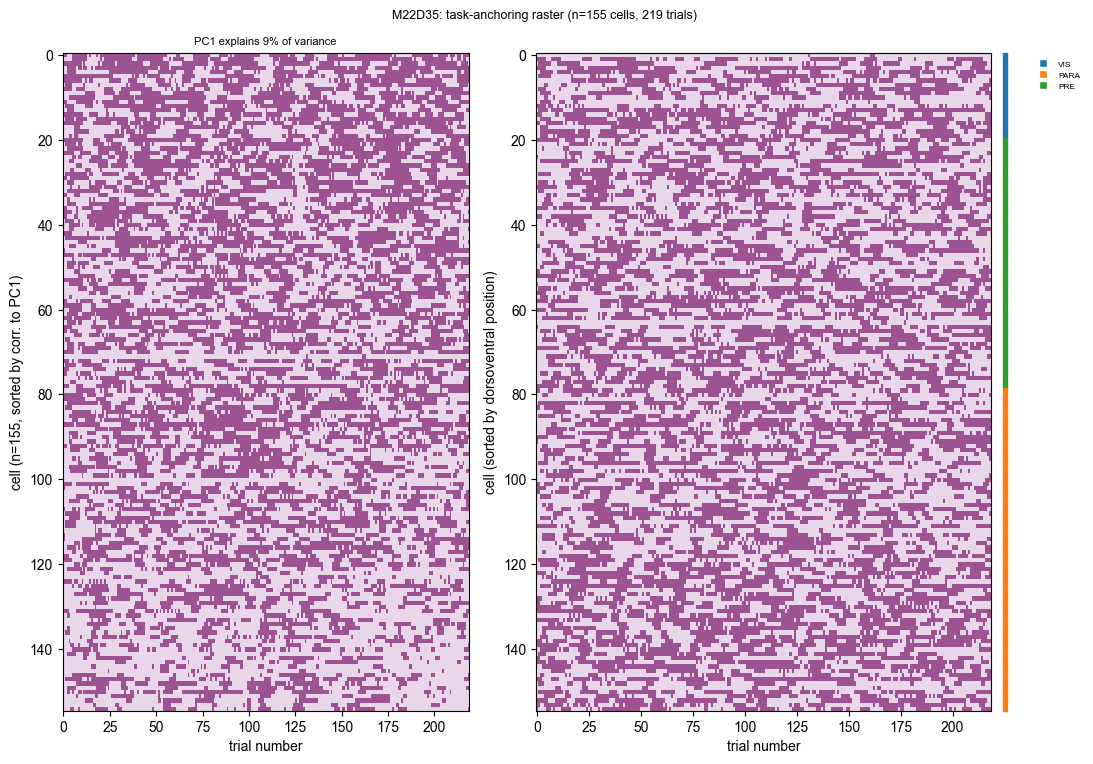

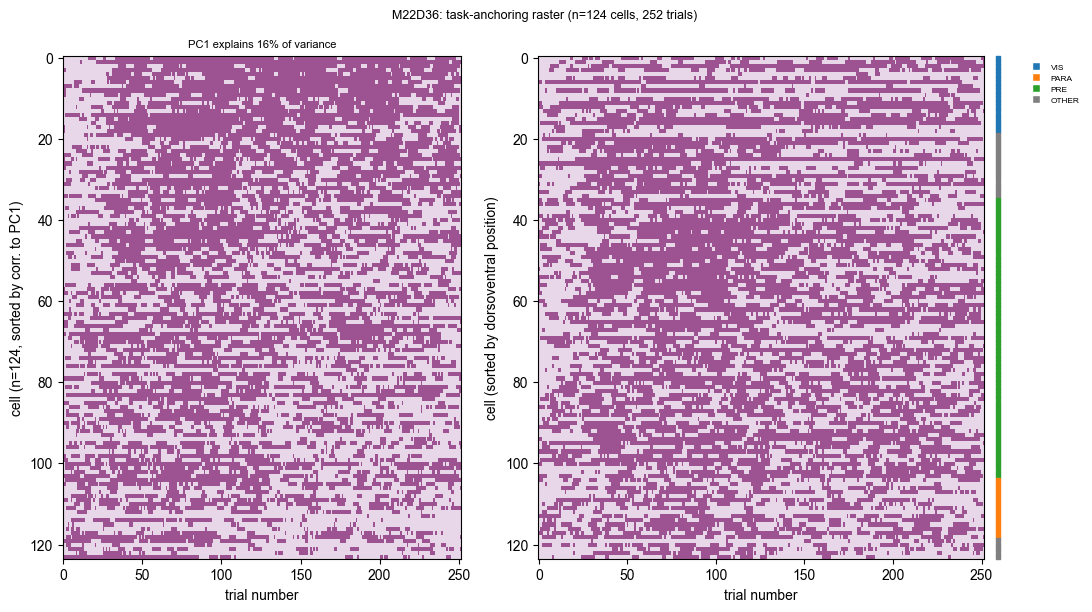

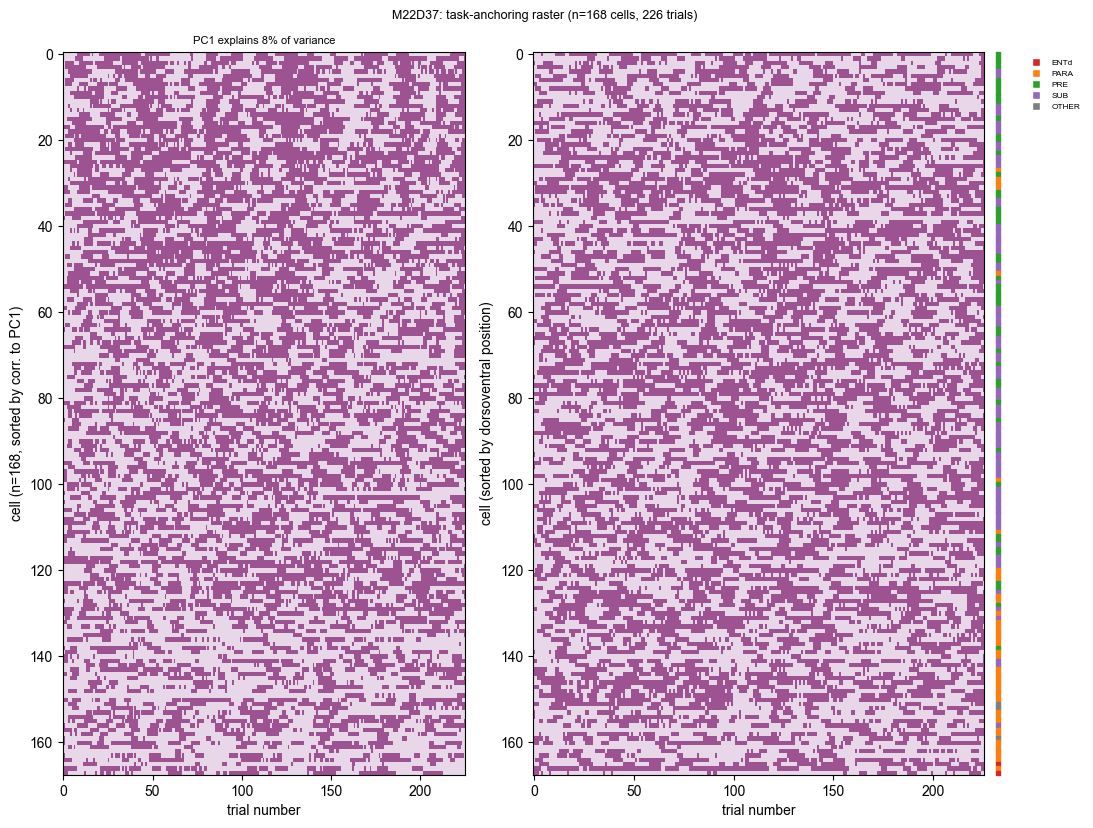

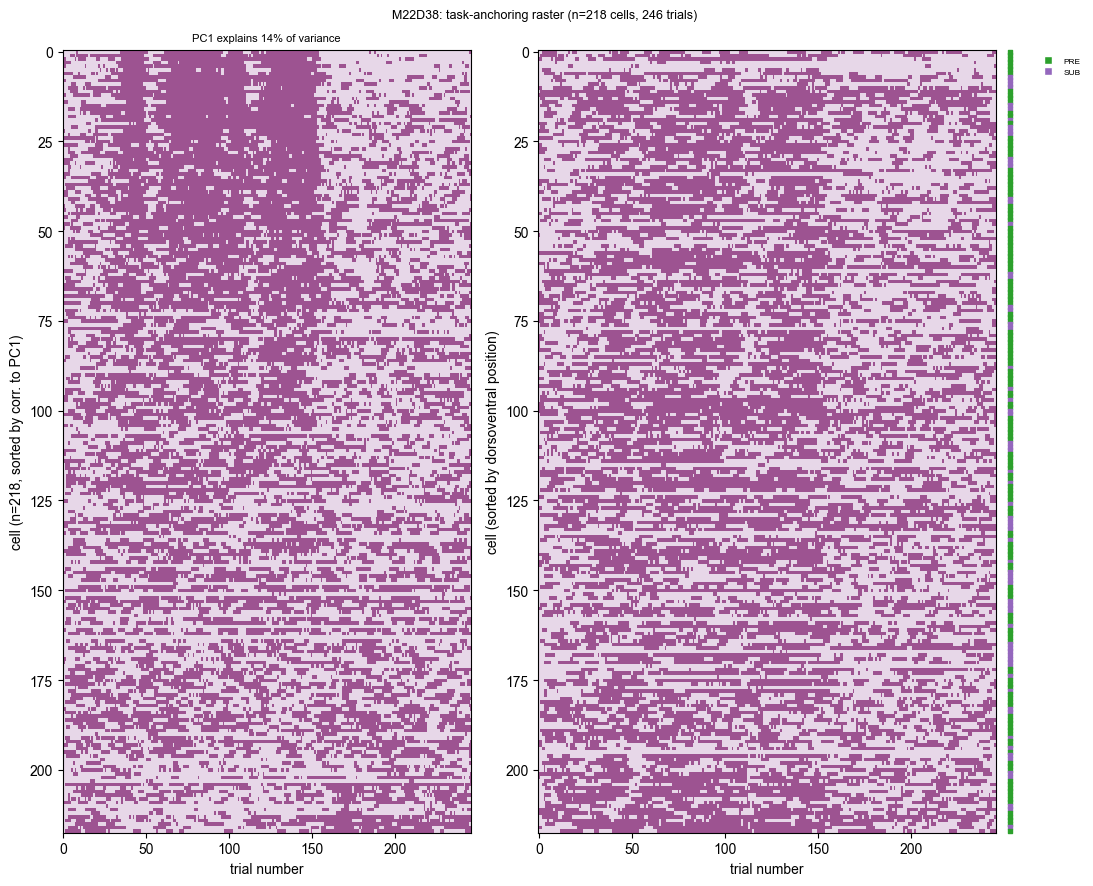

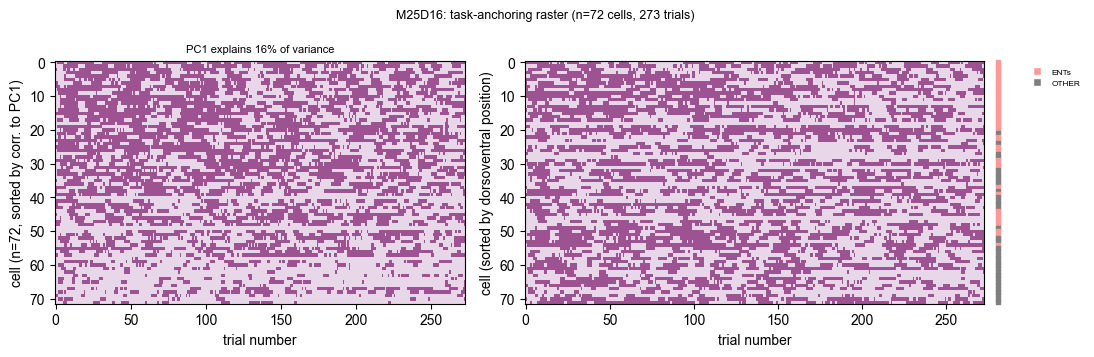

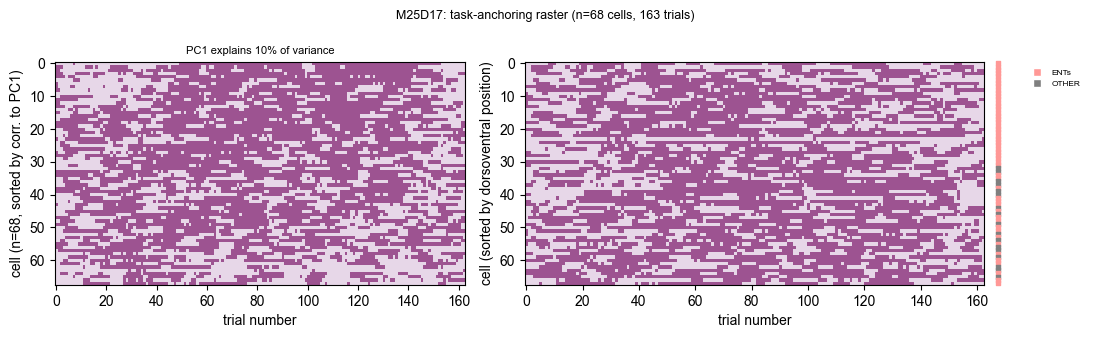

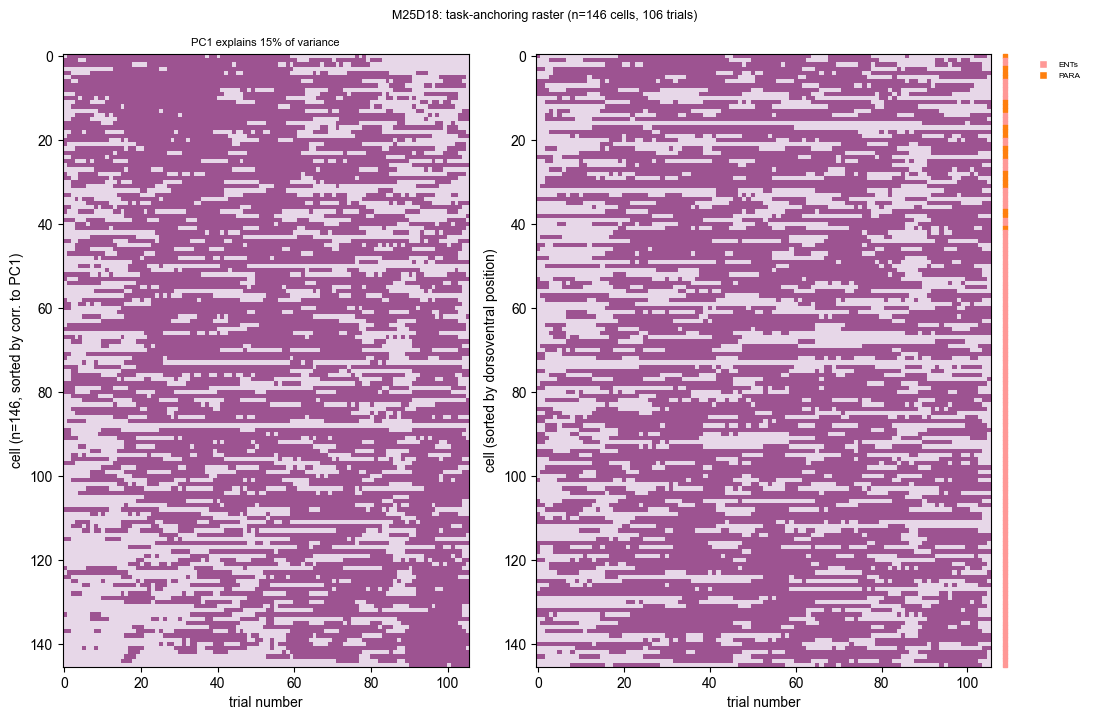

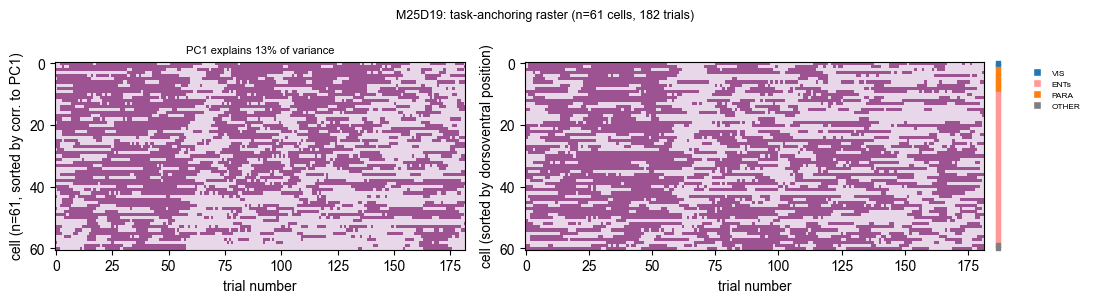

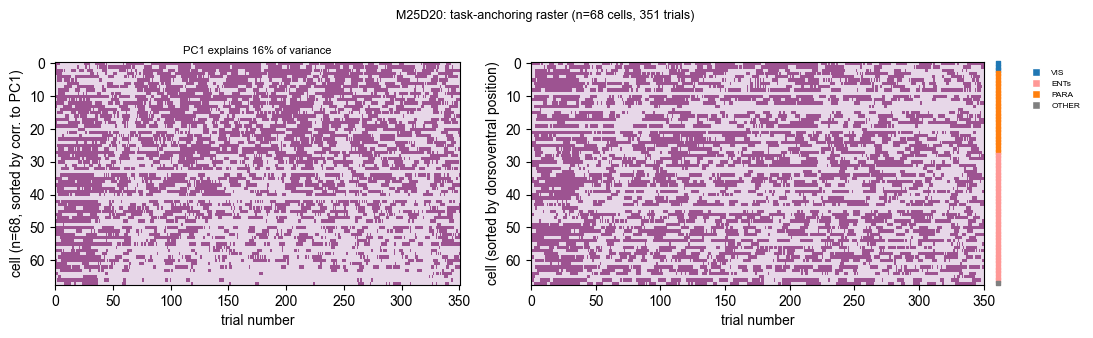

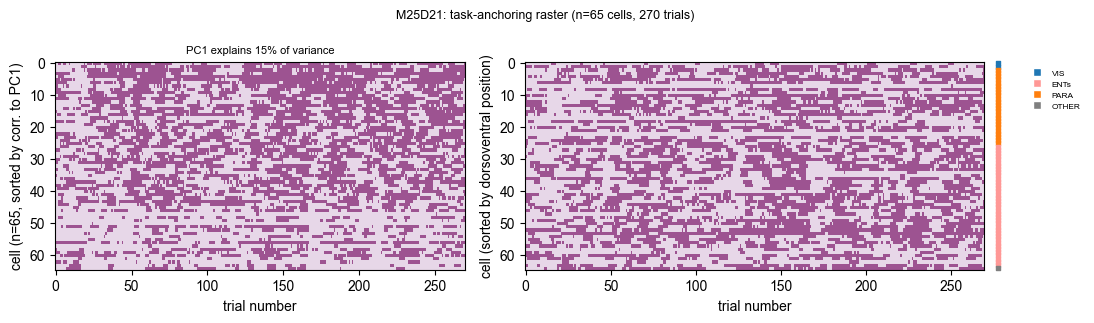

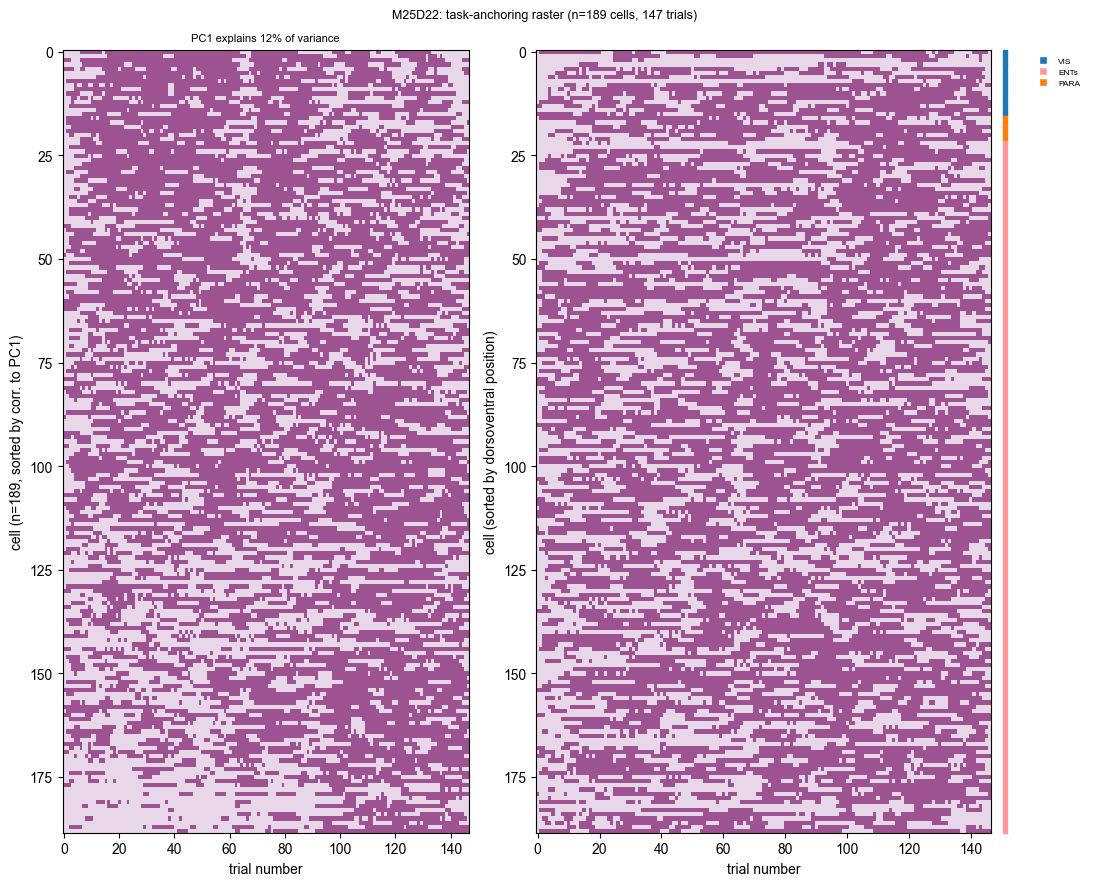

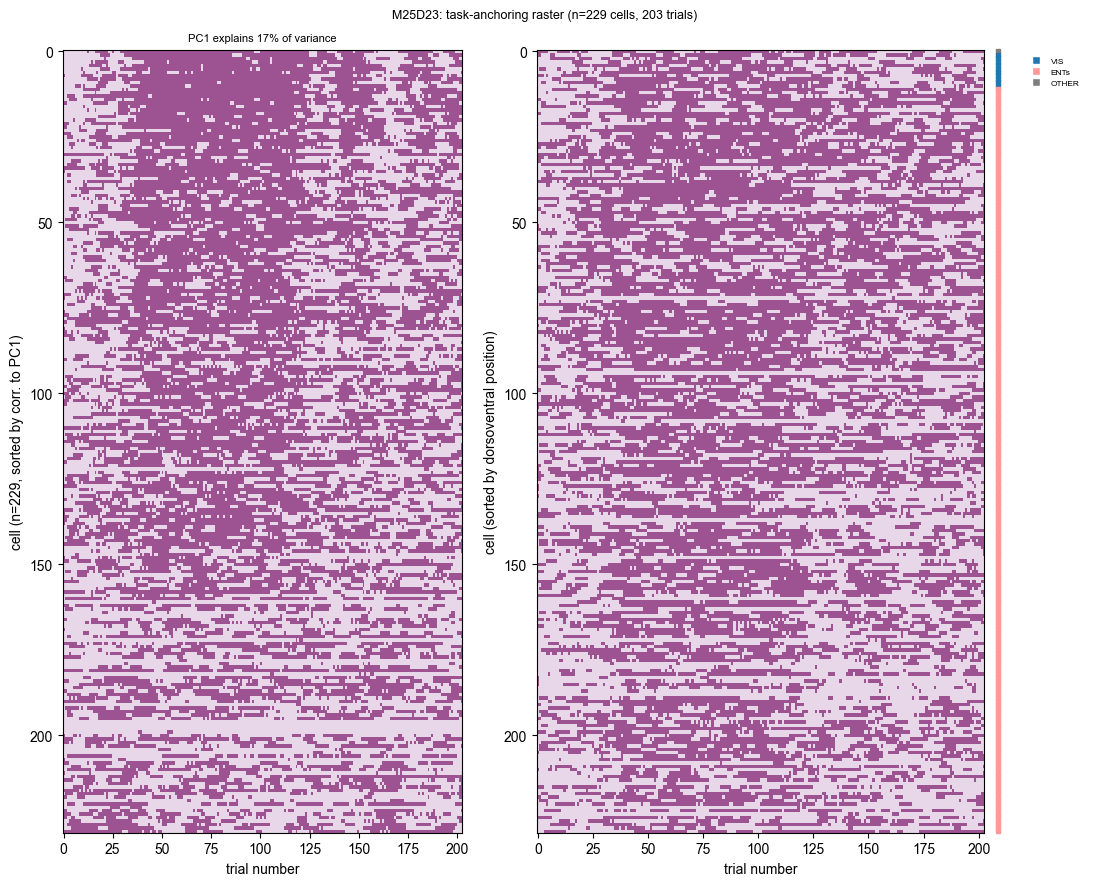

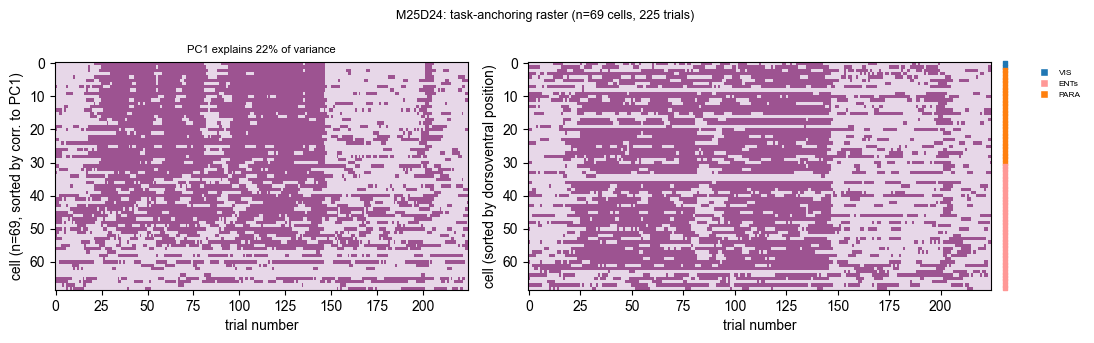

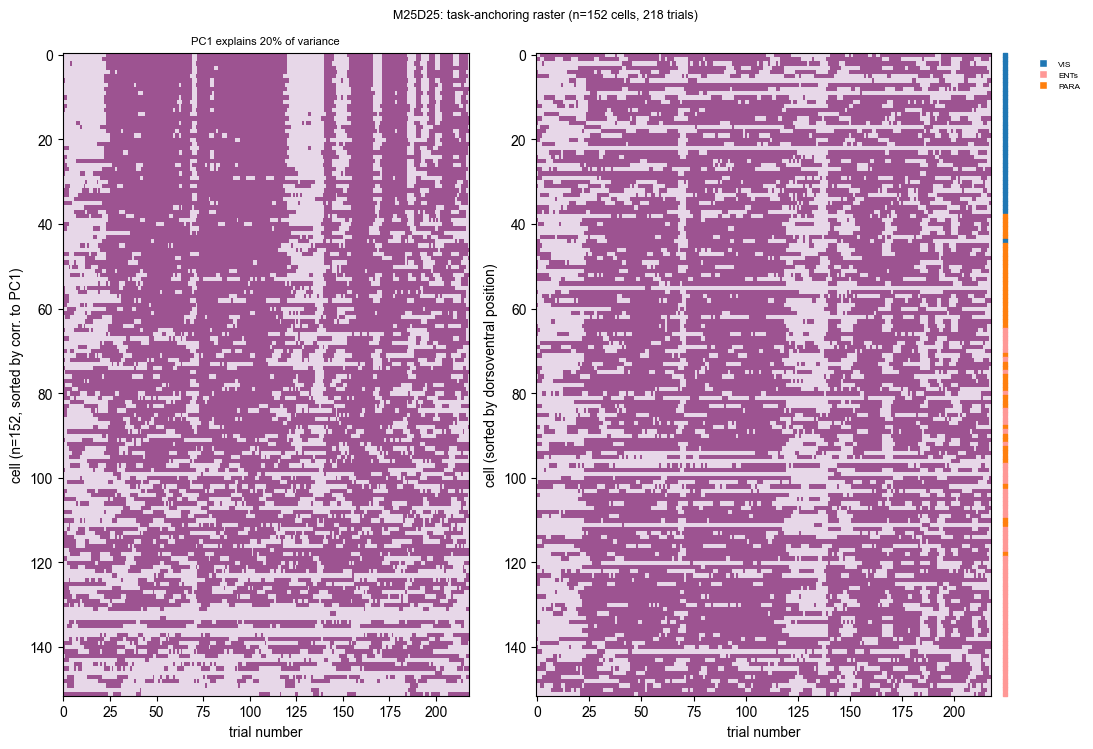

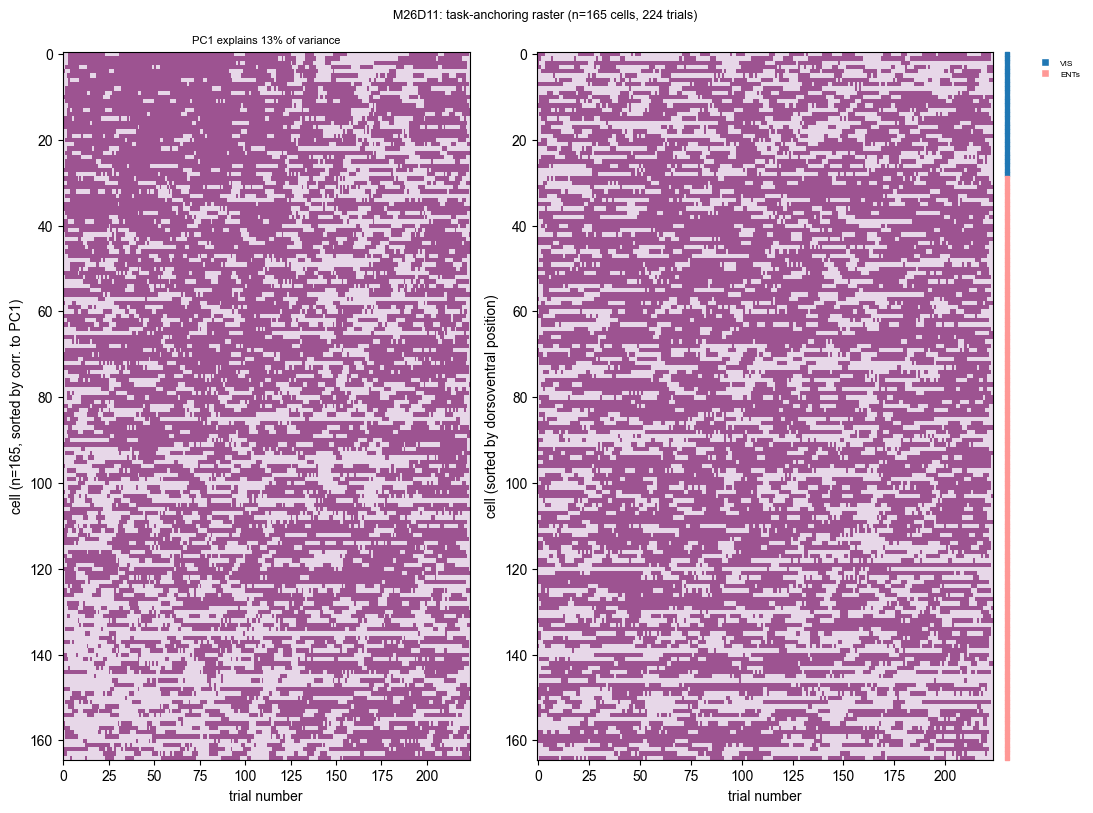

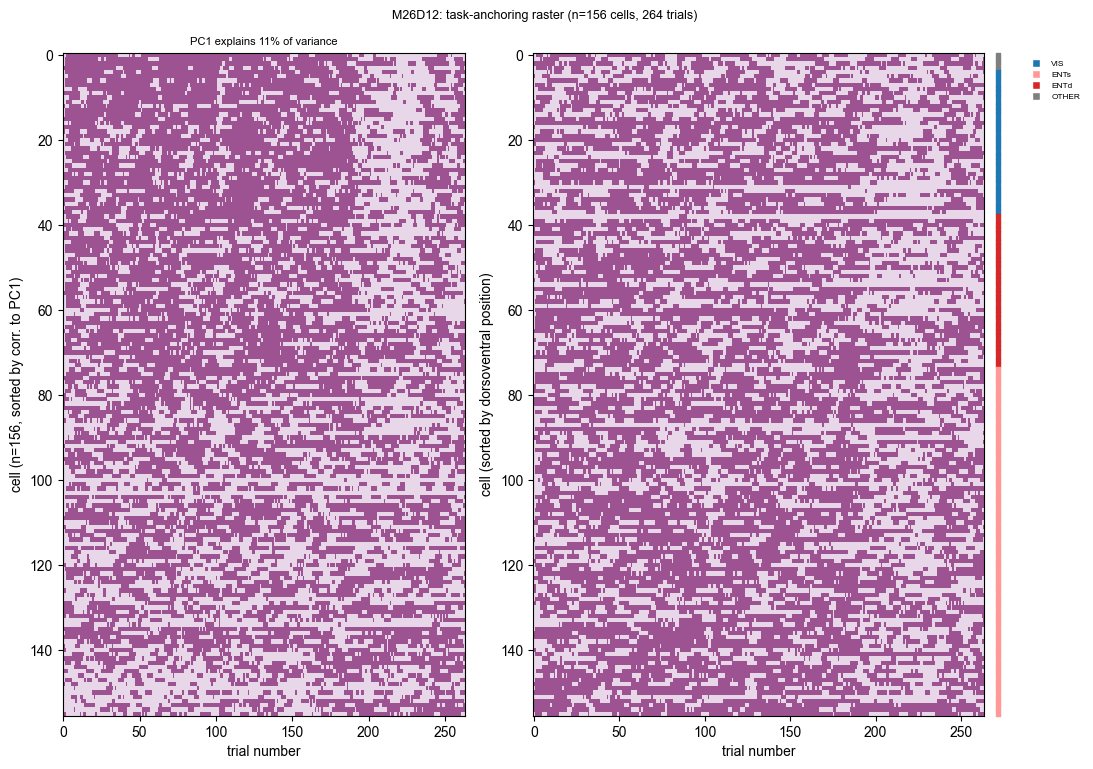

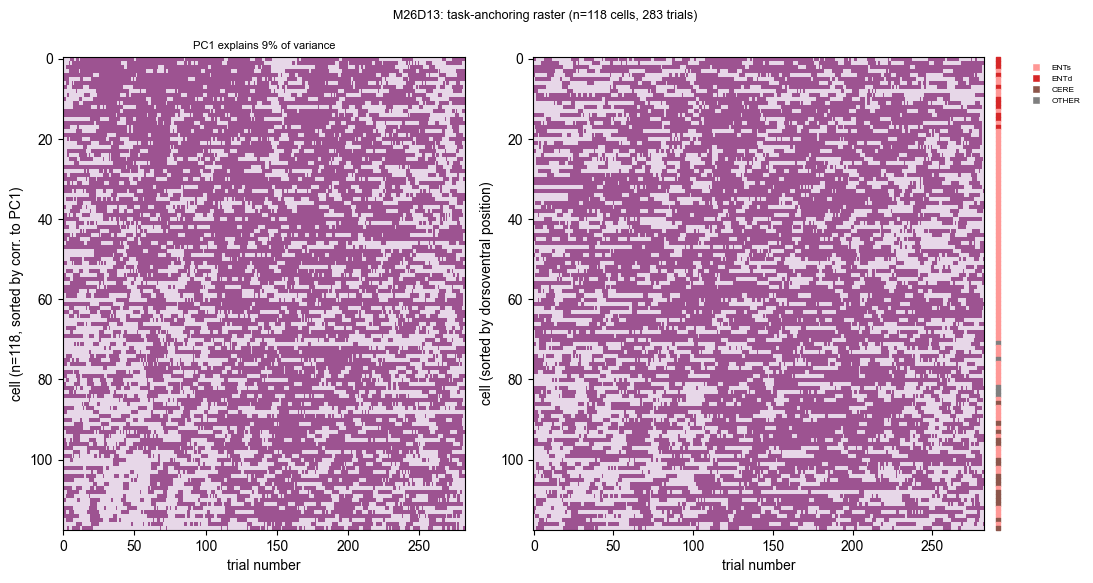

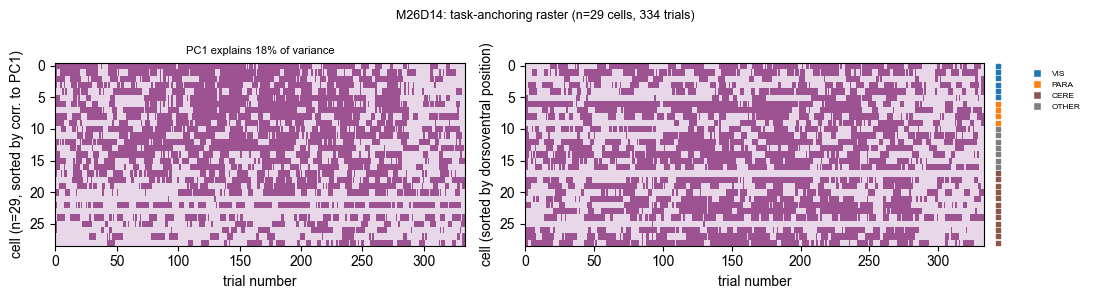

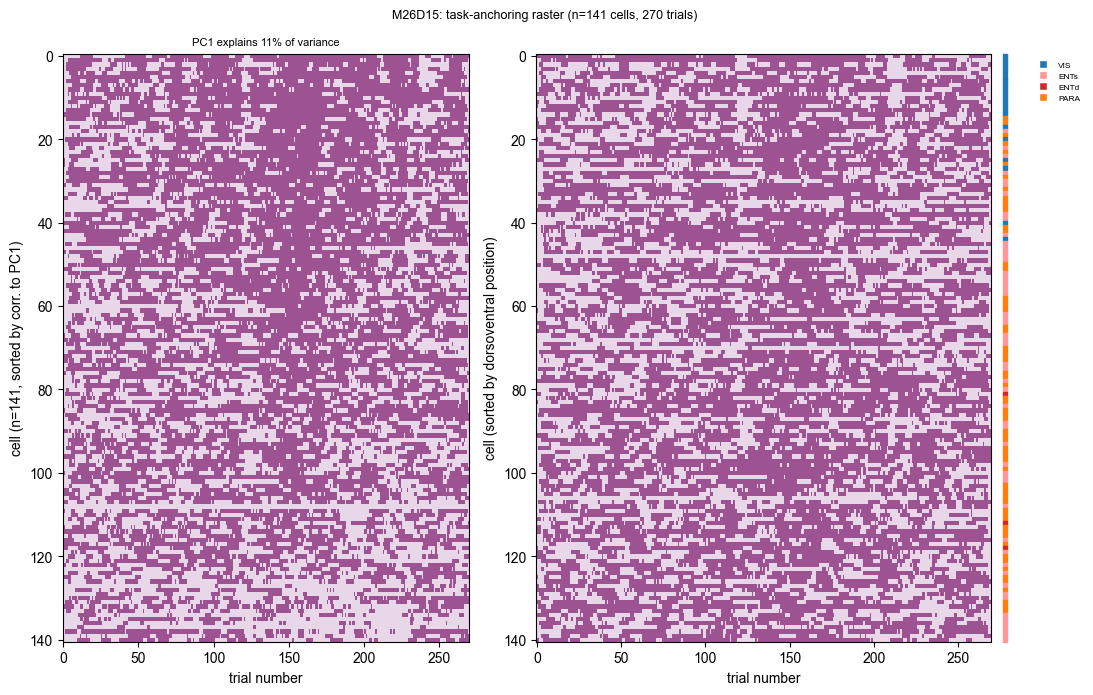

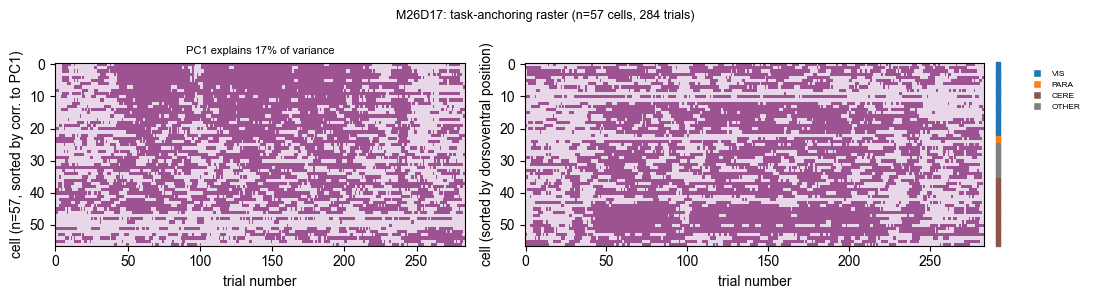

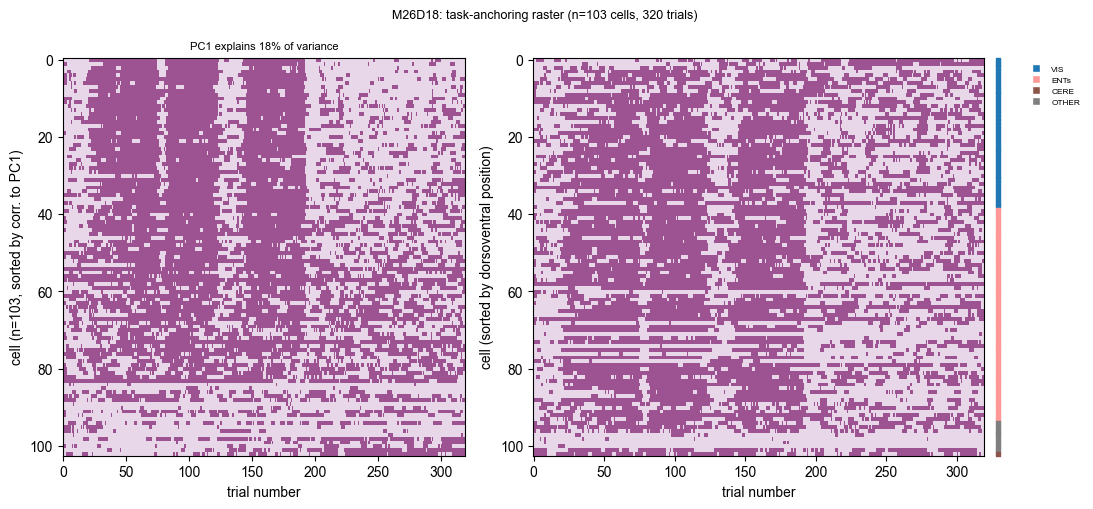

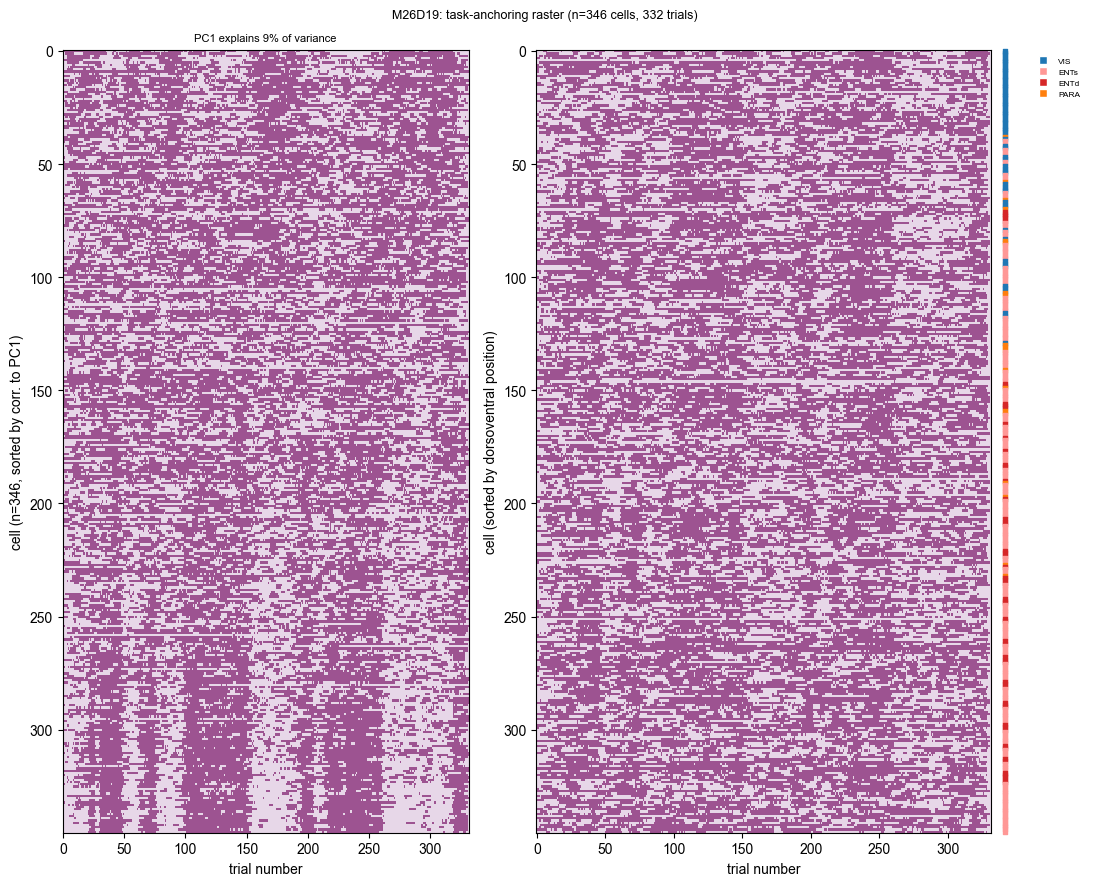

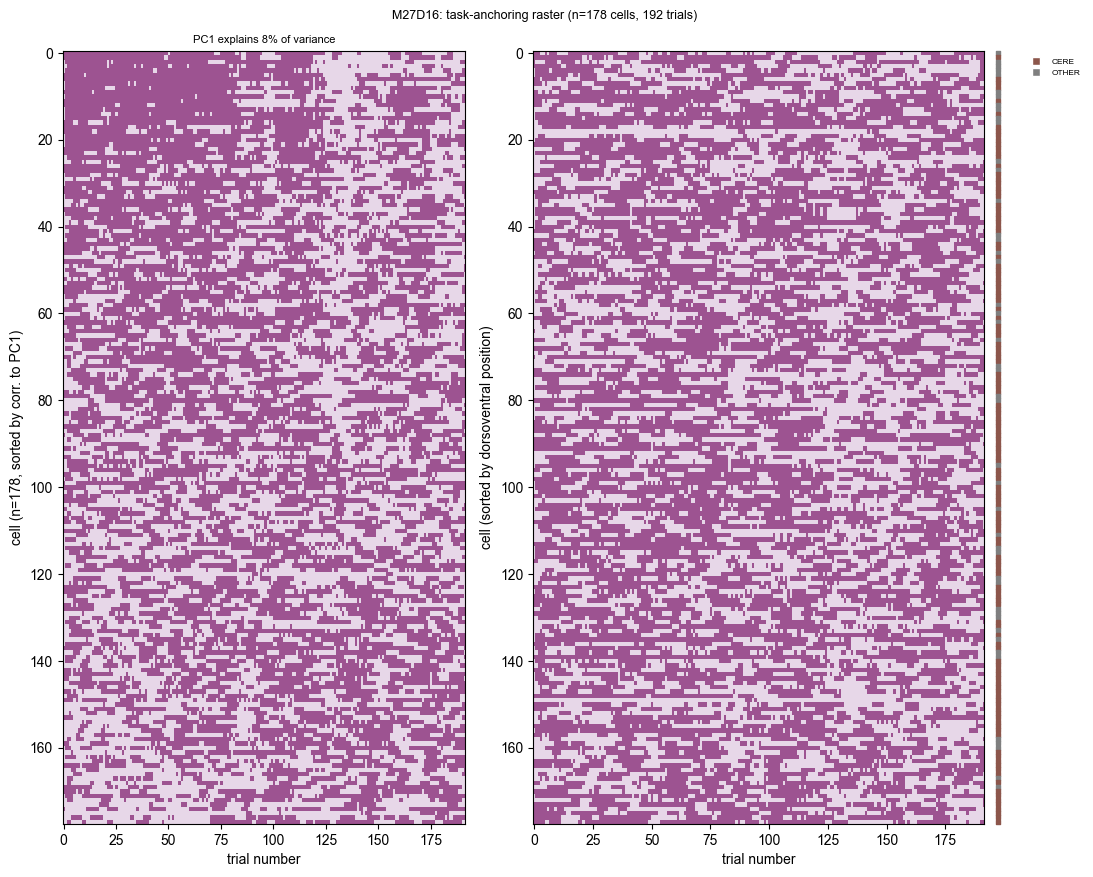

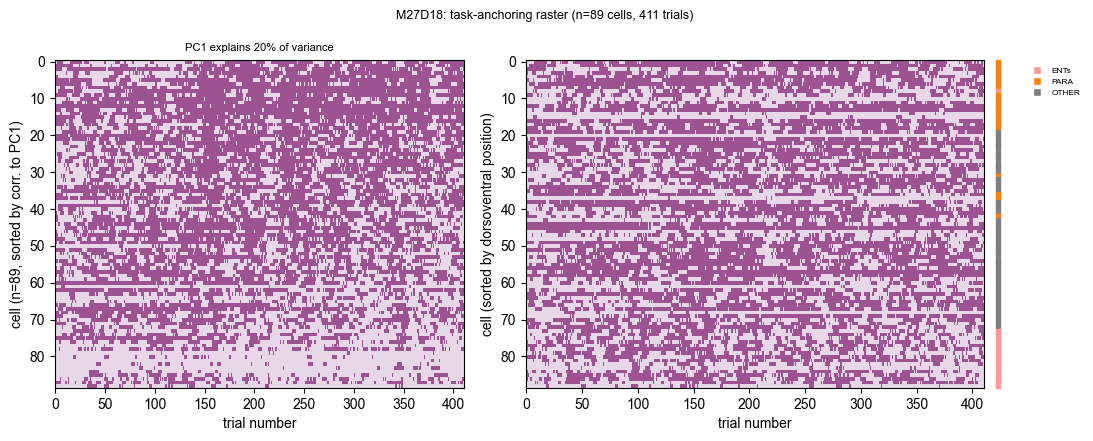

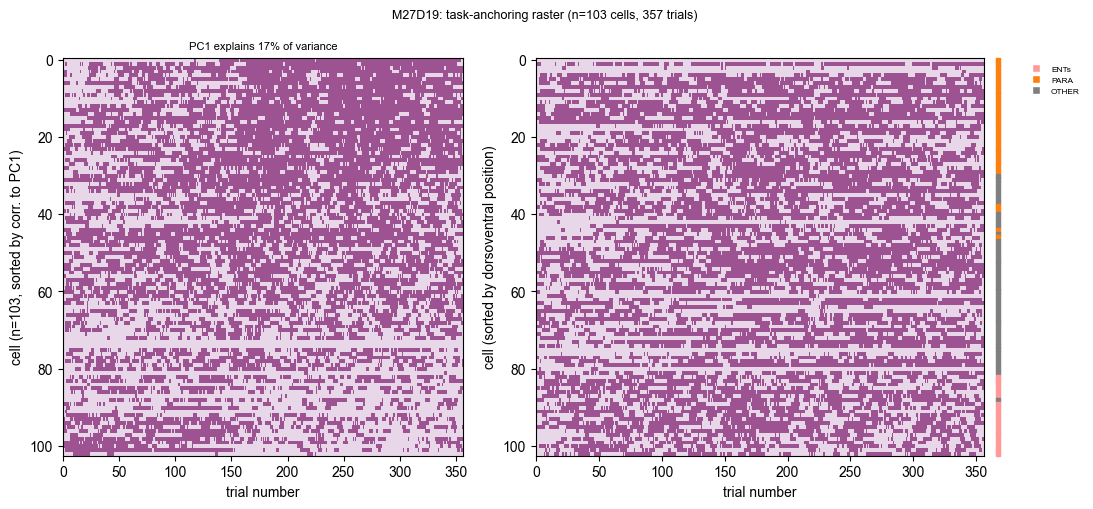

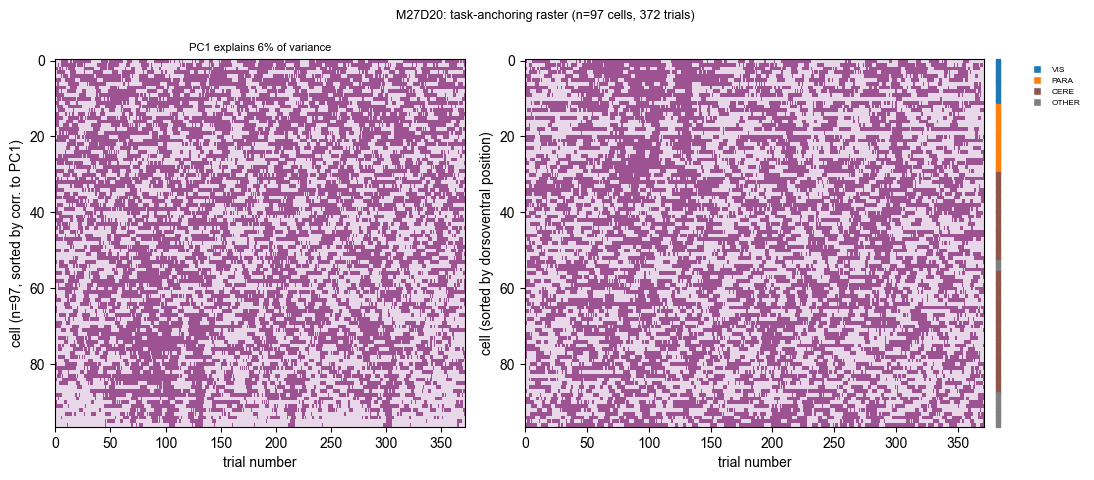

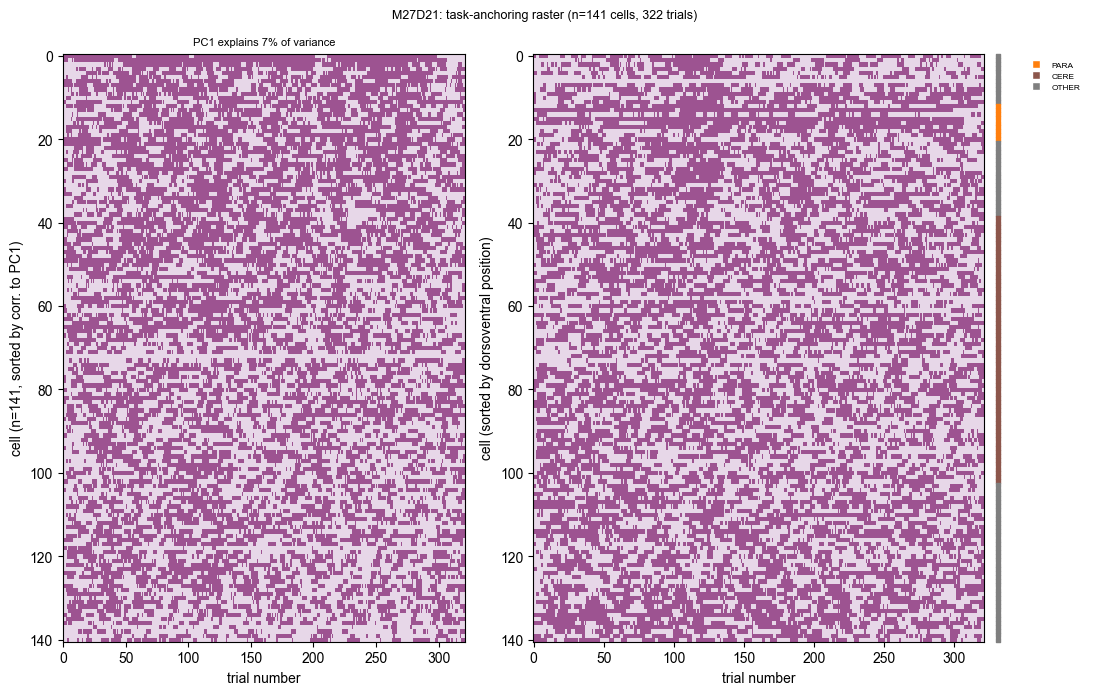

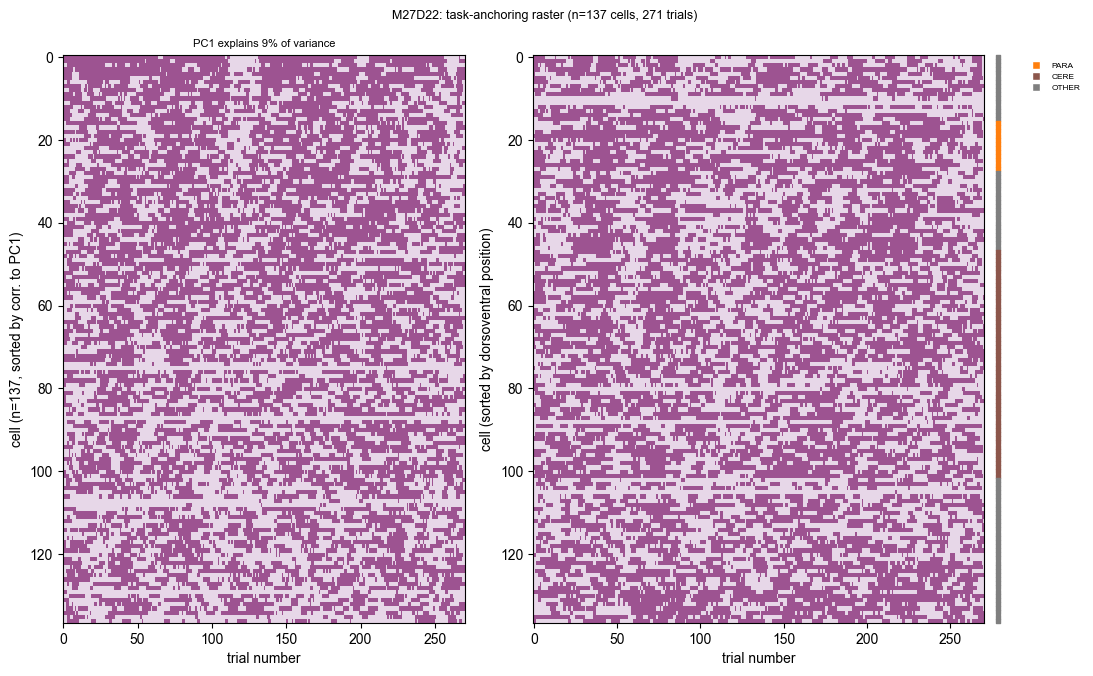

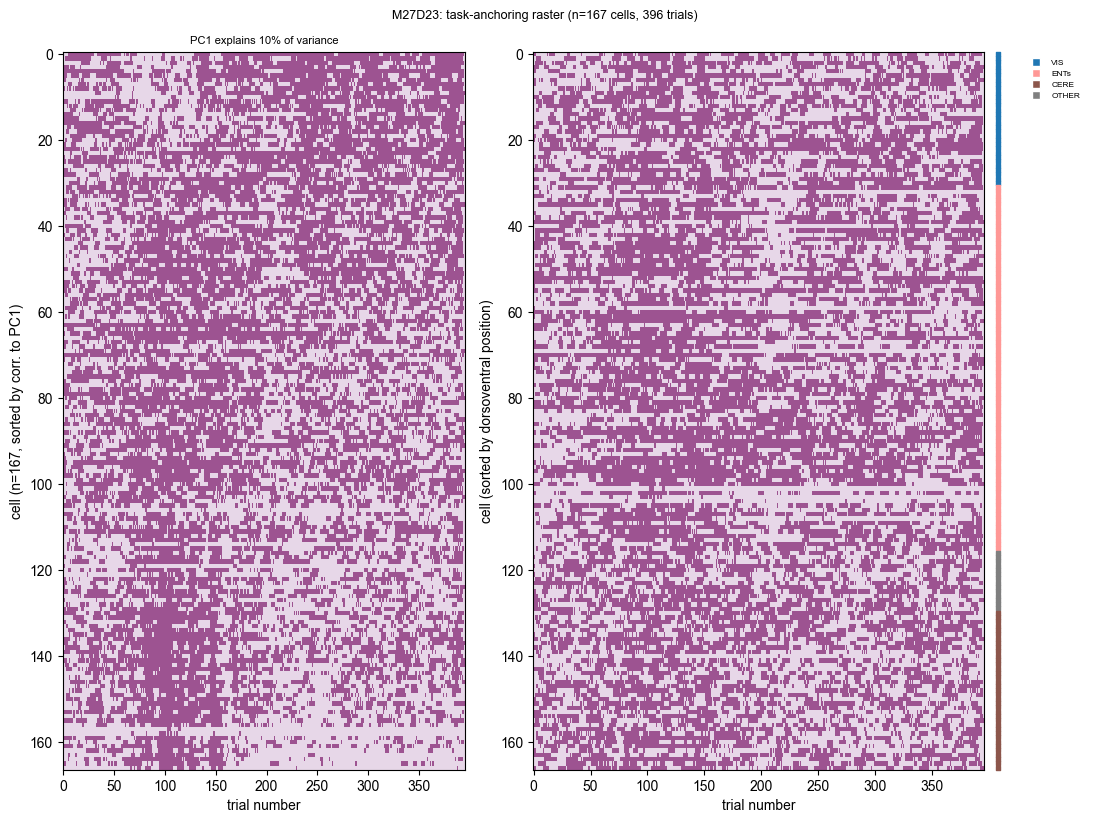

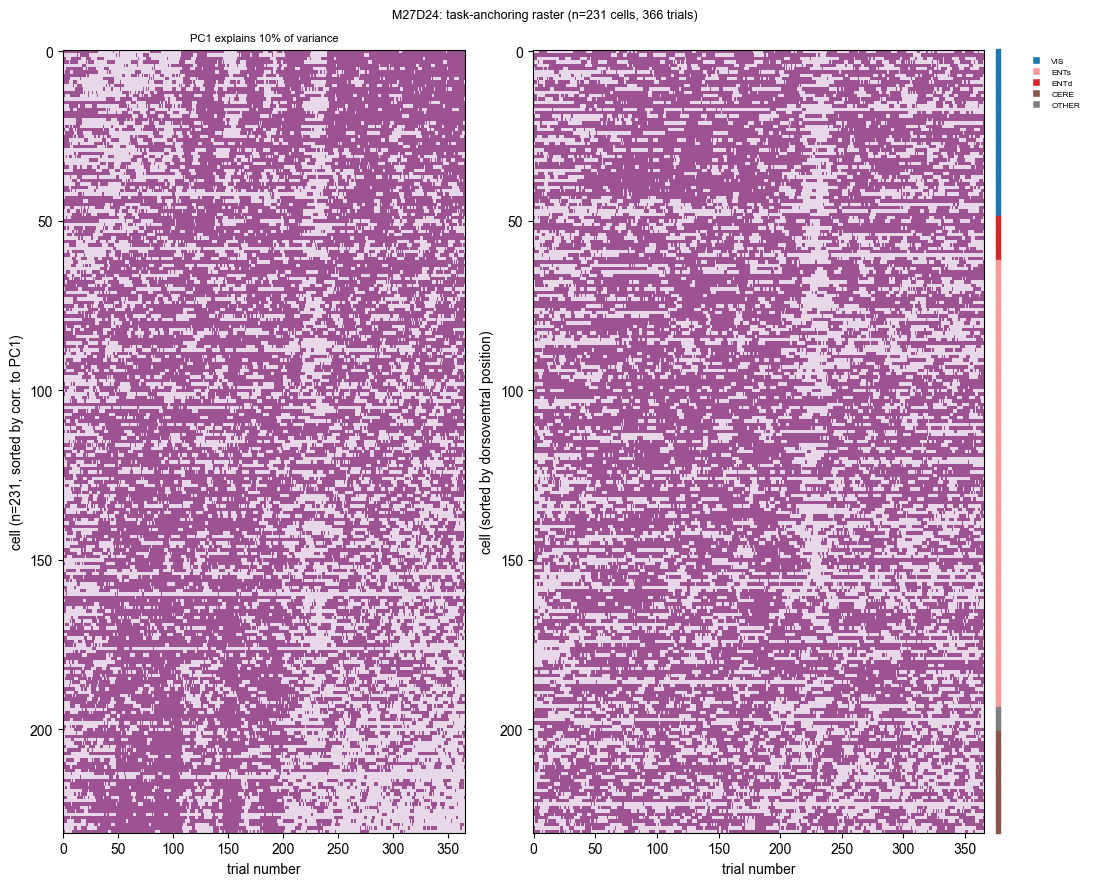

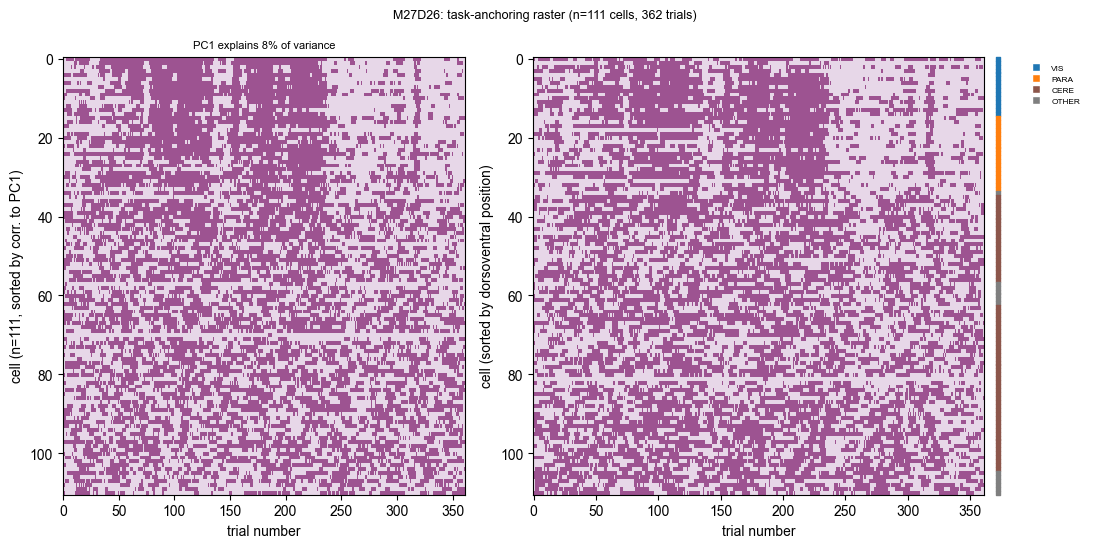

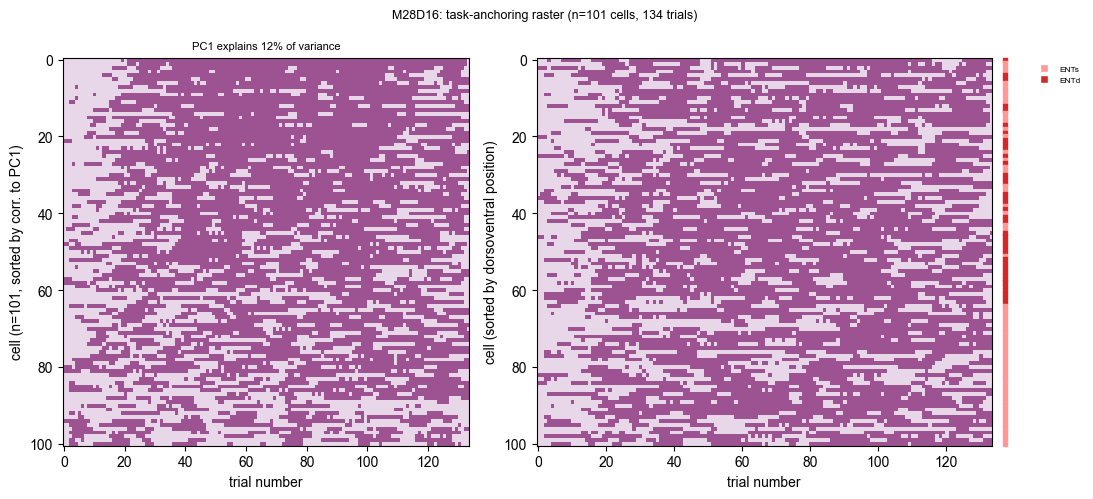

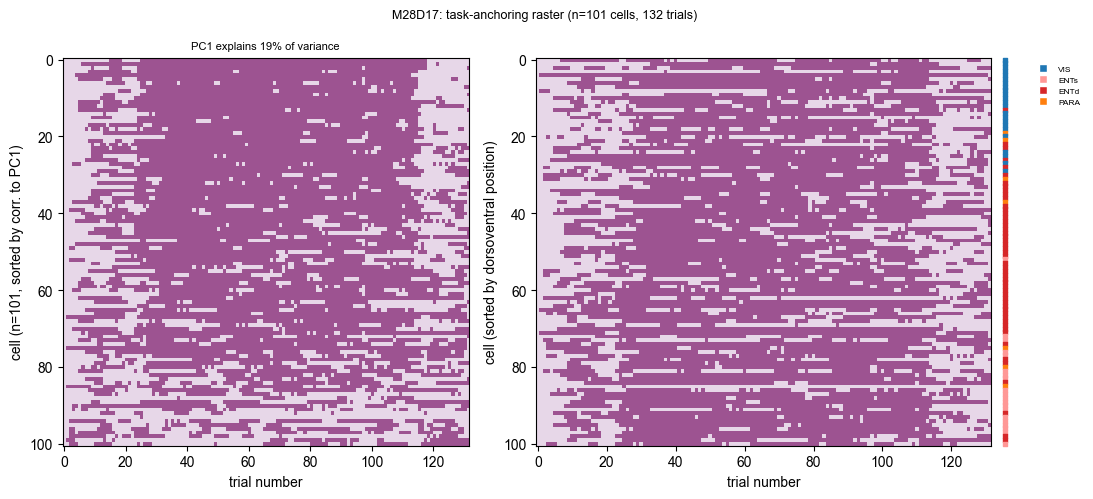

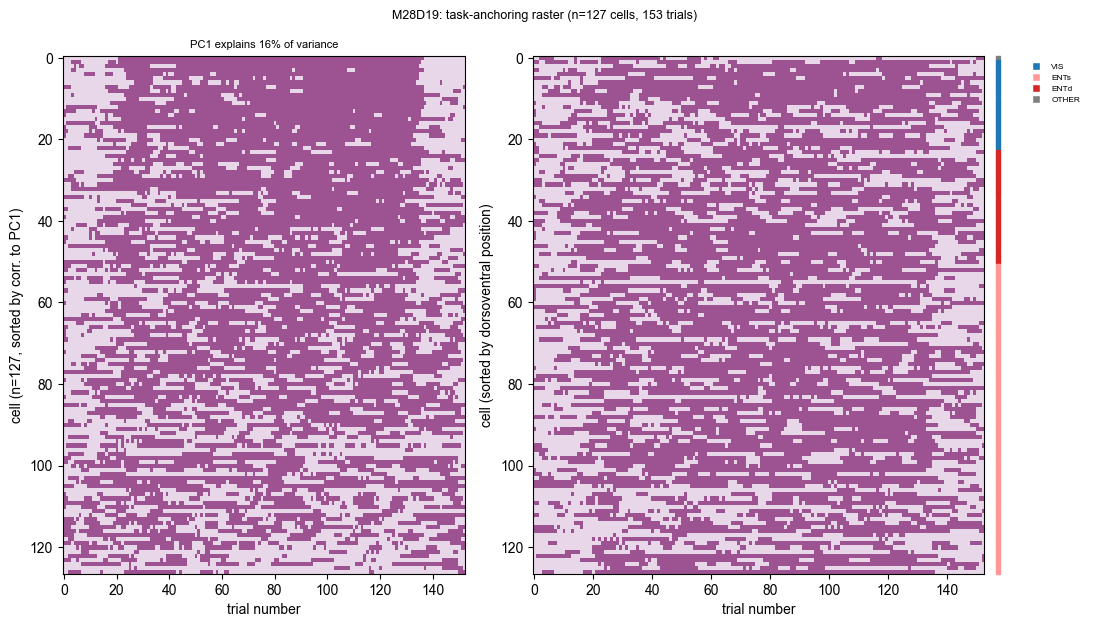

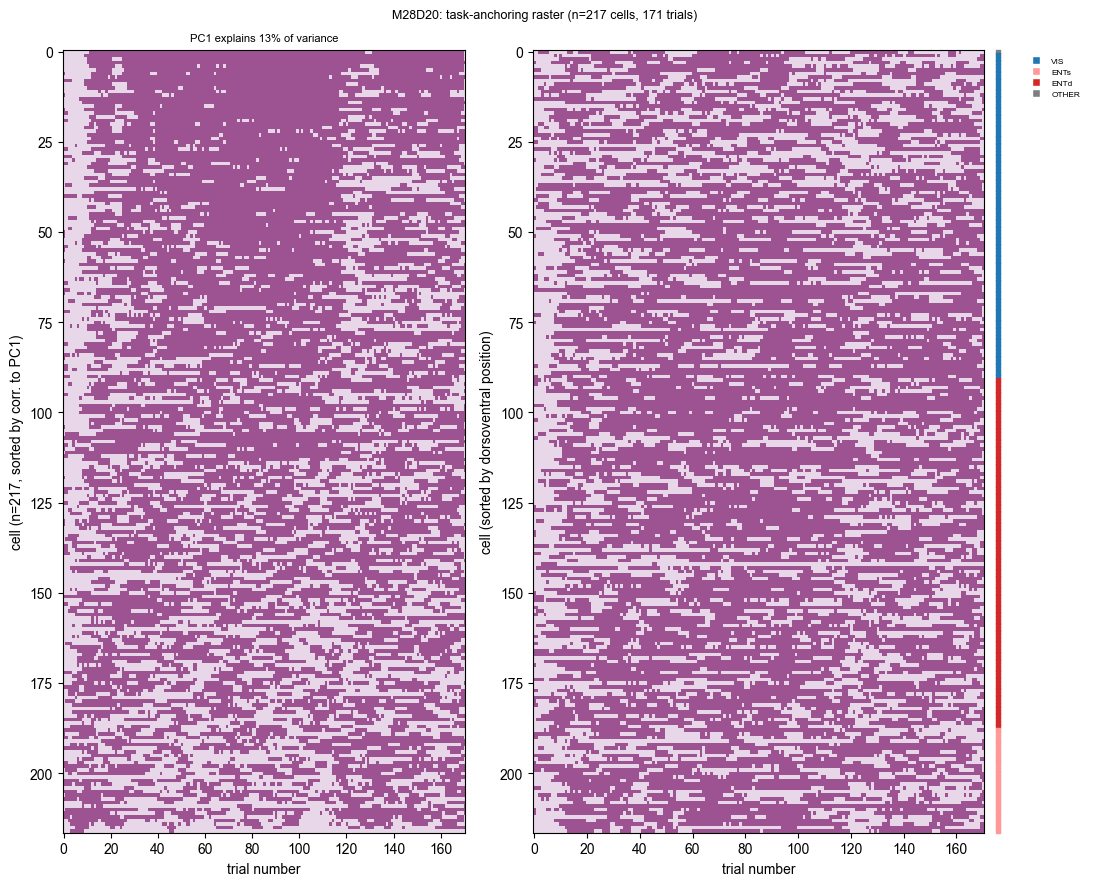

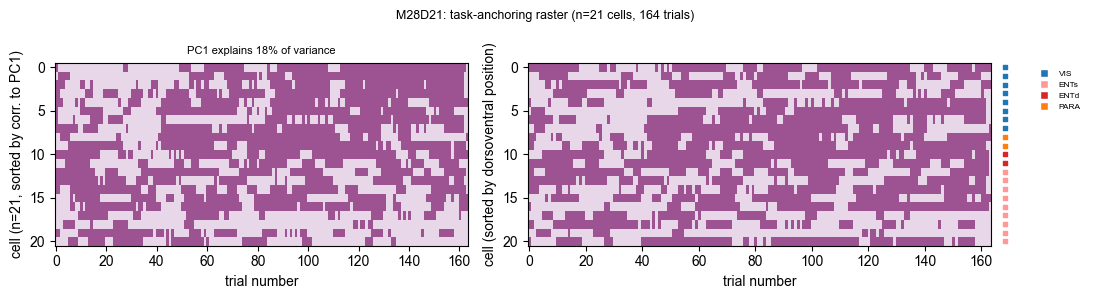

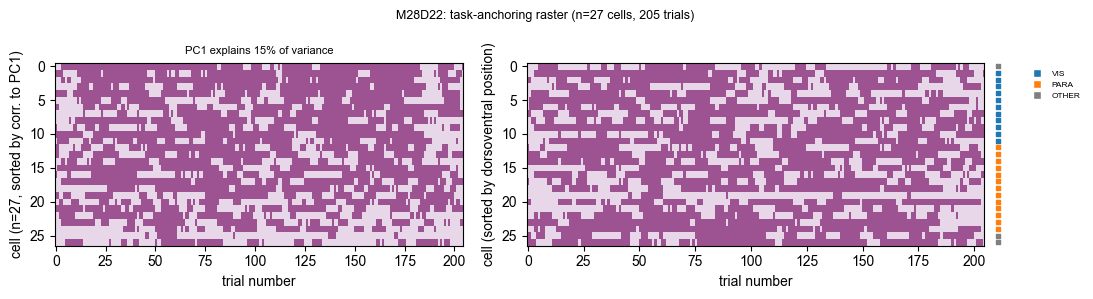

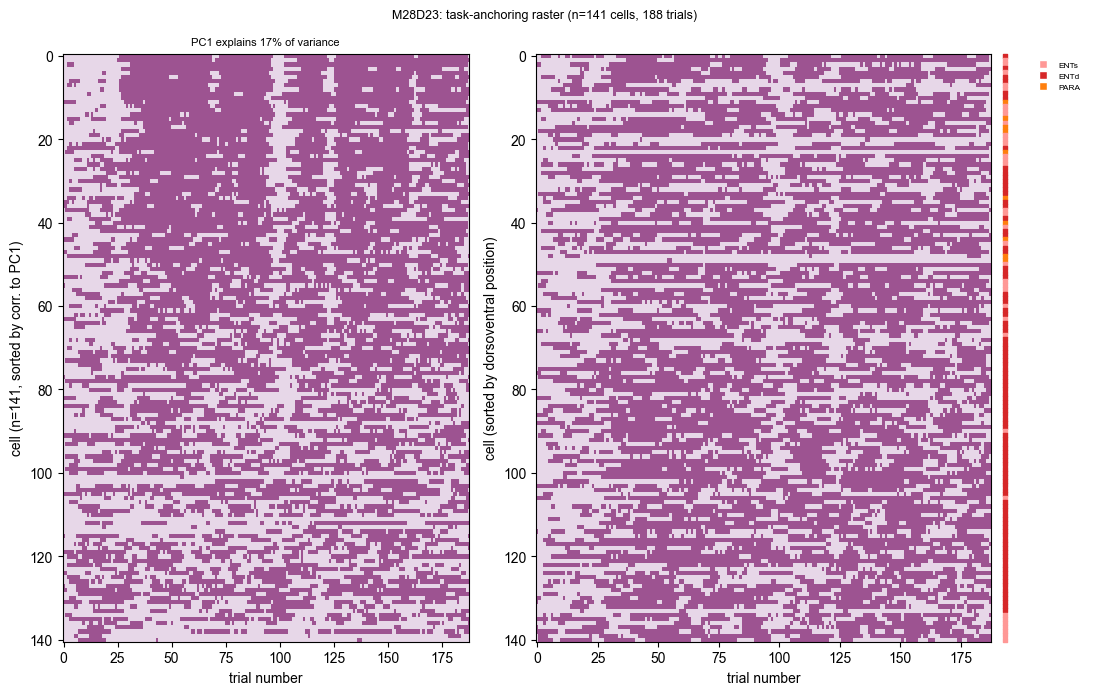

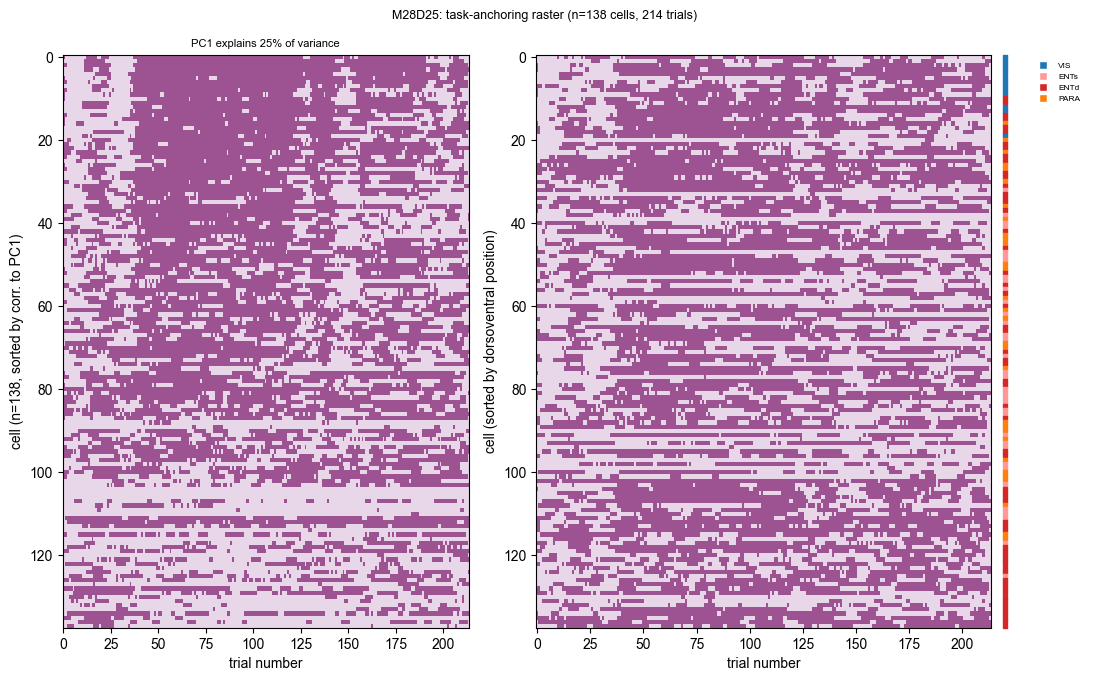

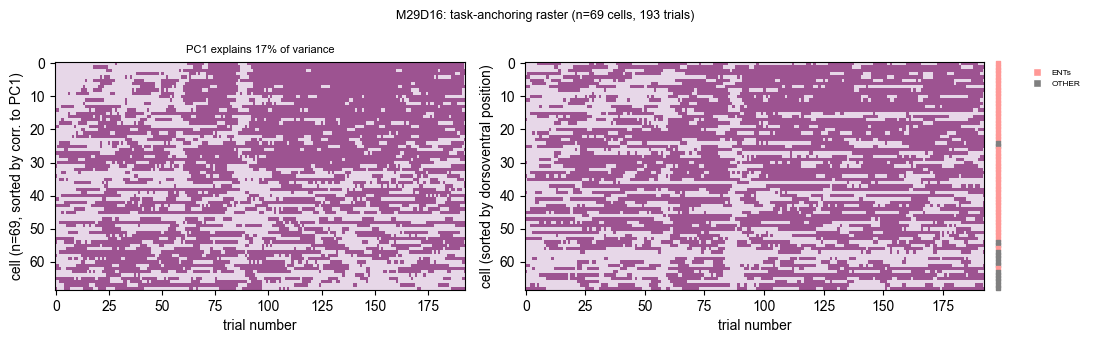

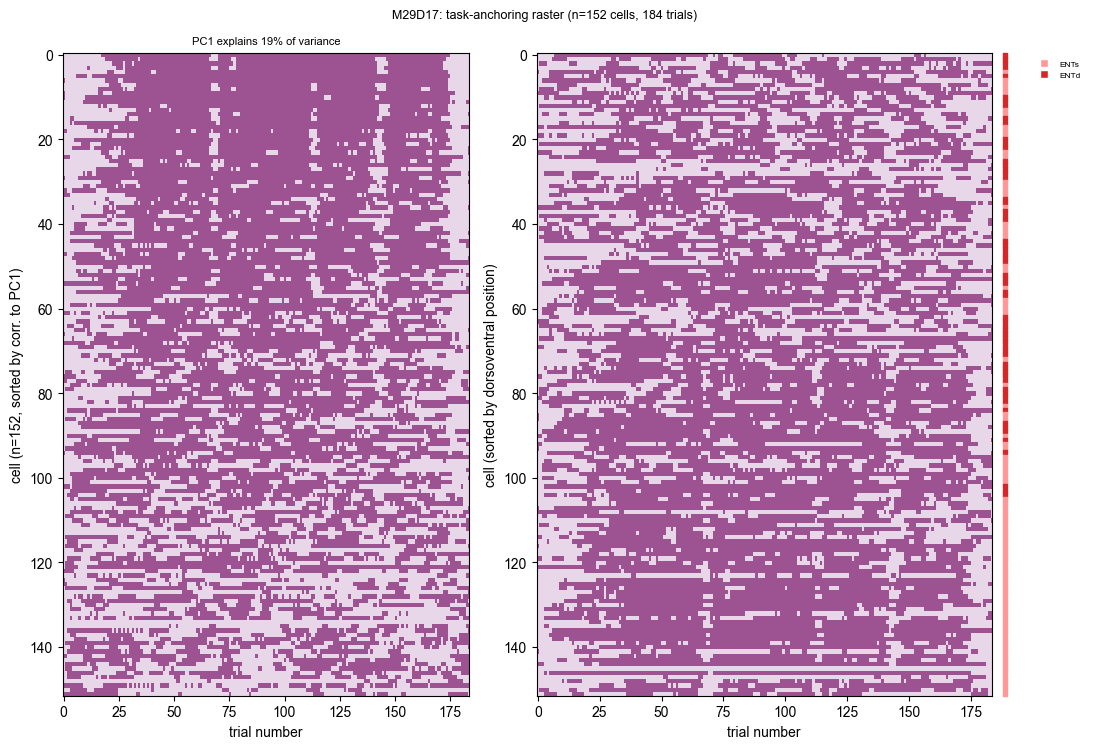

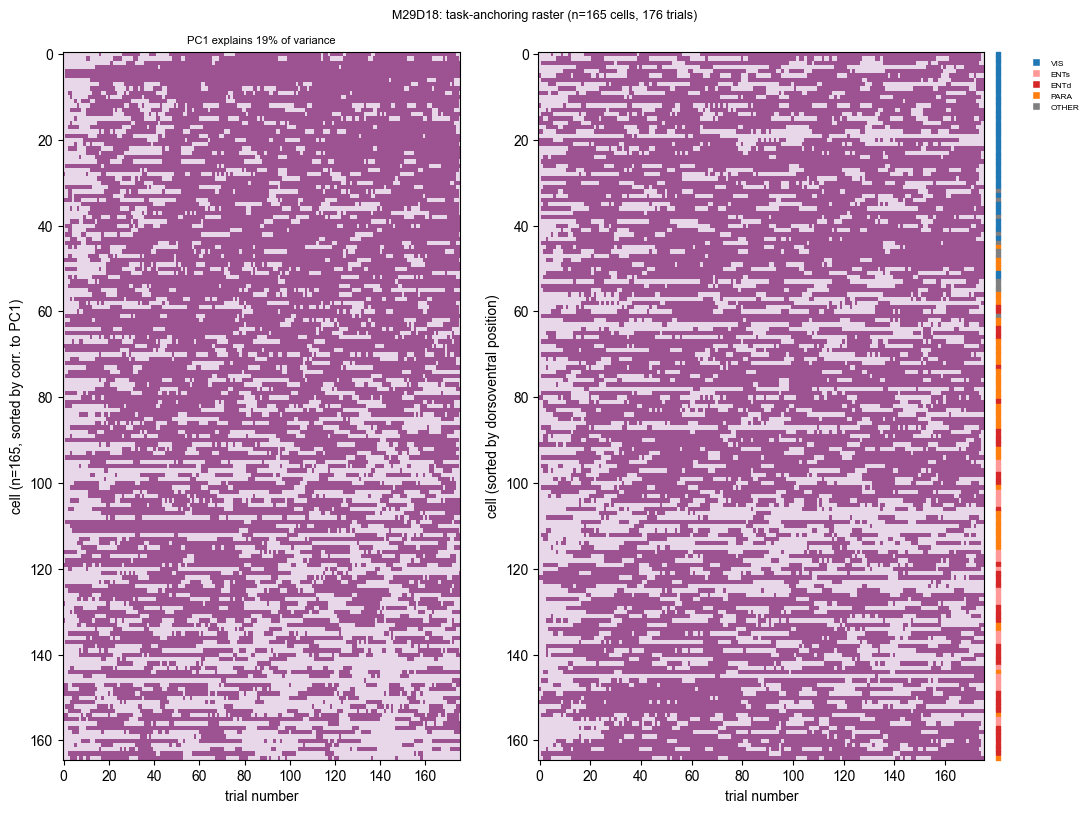

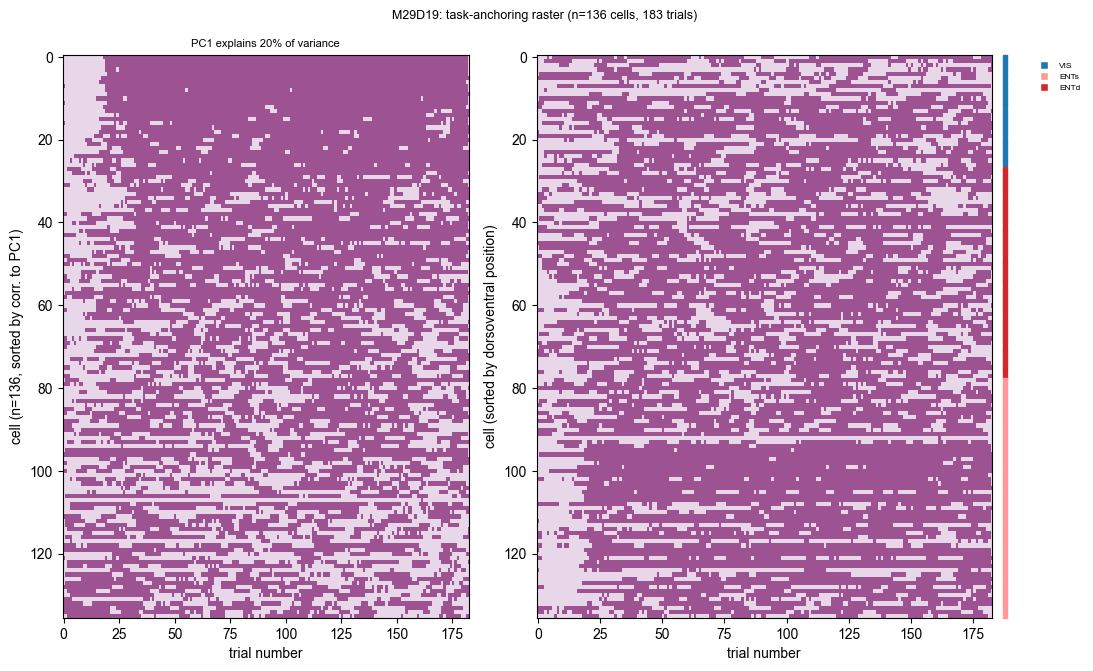

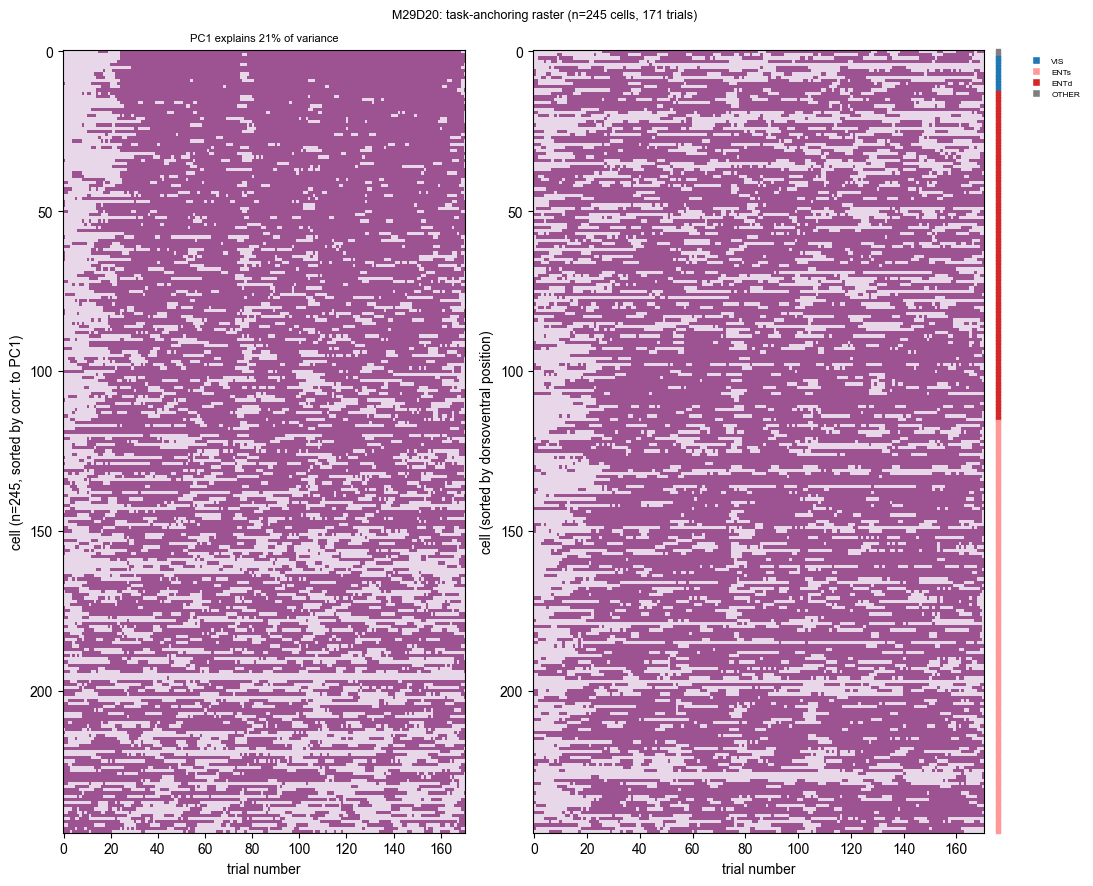

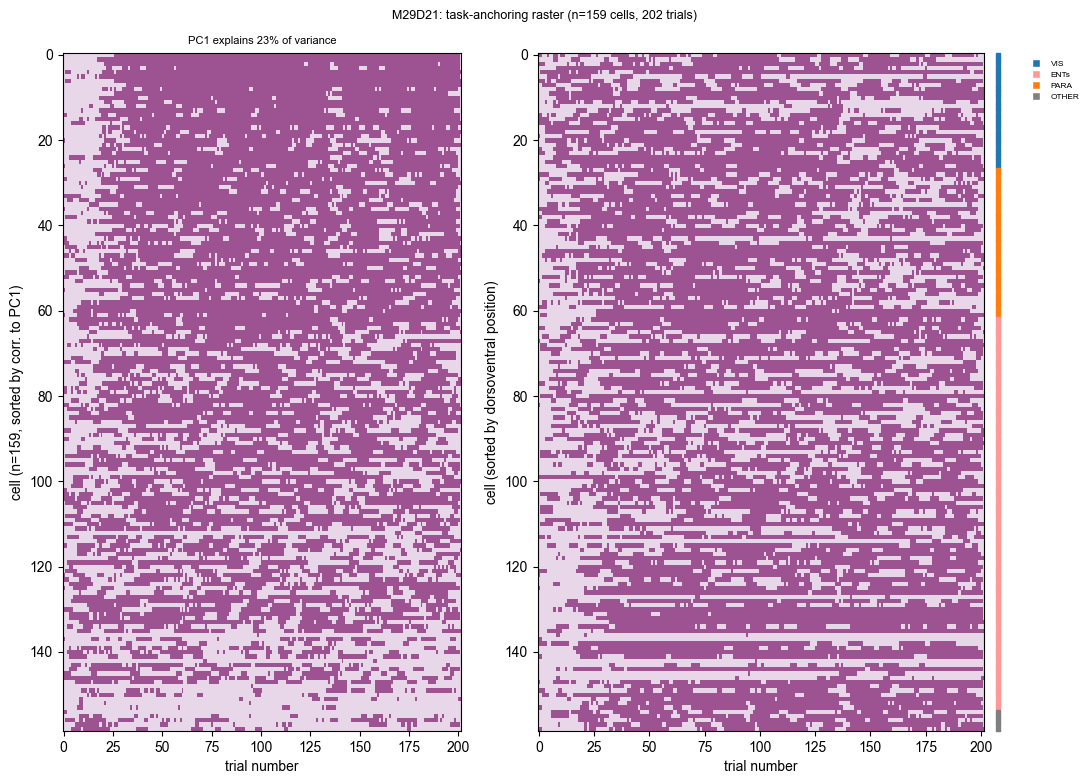

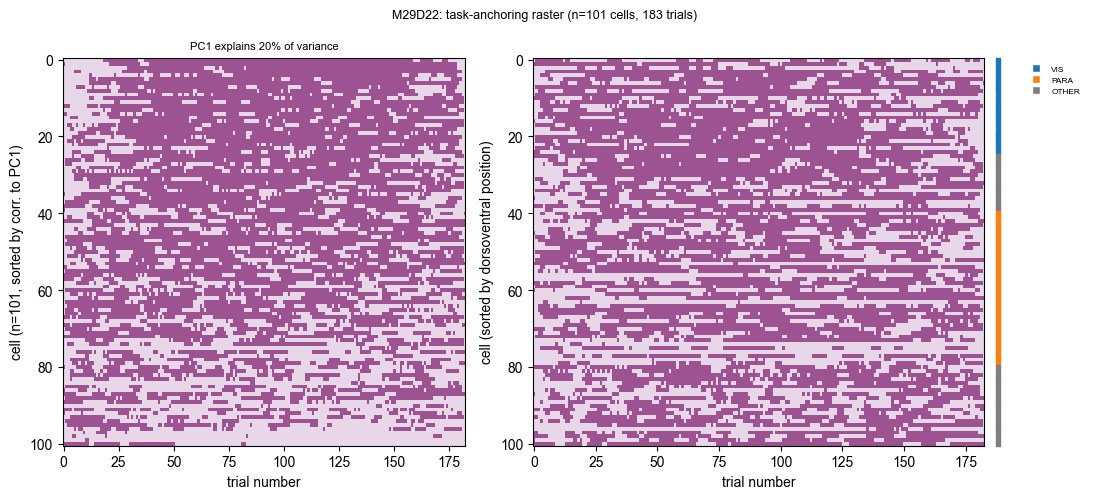

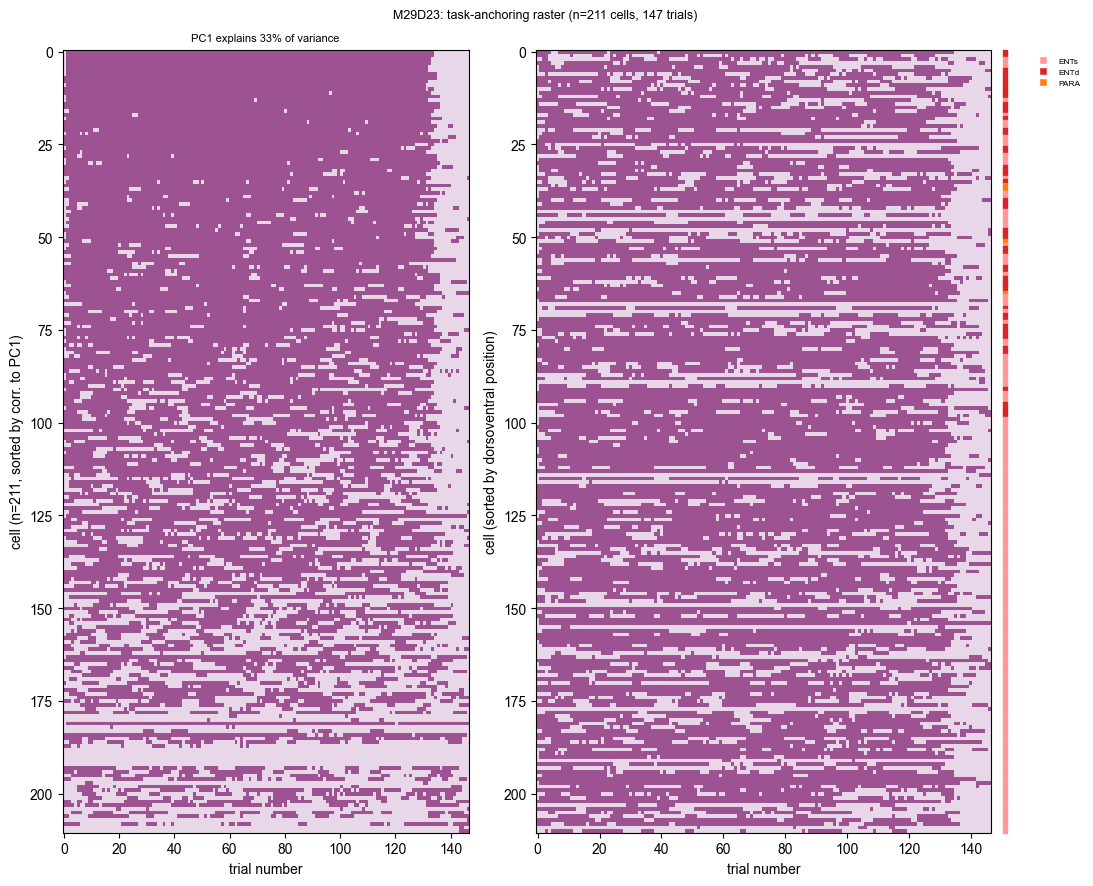

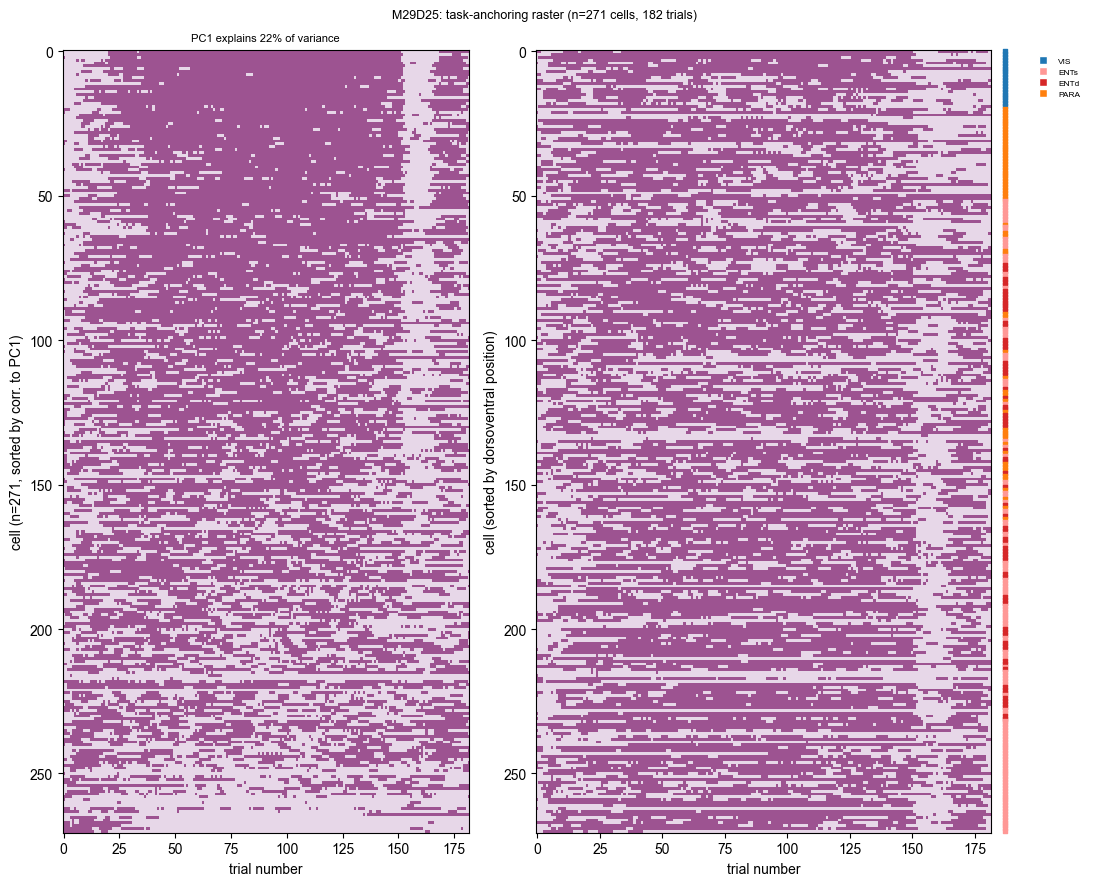

In [11]:
"""
Every session's anchoring raster, shown inline here (not just saved to disk
as separate files) -- rebuilt from the cached per-session results (label
matrix, PC1 correlations, dorsoventral position, brain region) produced by
the batch run over all sessions in cell_classifications.csv, so nothing here
needs to be recomputed. Left panel per session: PC1-sorted (no region
labels). Right panel: sorted by dorsoventral position, with a brain-region
color strip (VIS/ENT/PARA/PRE/SUB/CERE/OTHER).
"""
import glob
from matplotlib.lines import Line2D

cache_files = sorted(glob.glob(os.path.join(ALL_SESSIONS_DIR, '*_cache.npz')))
print(f'{len(cache_files)} sessions with cached results')

for cache_path in cache_files:
    d = np.load(cache_path, allow_pickle=True)
    label_matrix = d['label_matrix']
    dv_vals = d['dv_vals']
    regions = d['regions']
    pc1_corrs = d['pc1_corrs']
    pc1_var = float(d['pc1_explained_var'])
    n_trials = int(d['n_trials'])
    session_name = os.path.basename(cache_path).replace('_cache.npz', '')
    n_cells = label_matrix.shape[0]

    pc1_order = np.argsort(-pc1_corrs)
    dv_order = np.argsort(dv_vals)

    fig, axes = plt.subplots(1, 2, figsize=(11, max(3, min(9, n_cells * 0.05))),
                              gridspec_kw={'width_ratios': [1, 1.12]})

    ax = axes[0]
    ax.imshow(label_matrix[pc1_order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    ax.set_xlabel('trial number')
    ax.set_ylabel(f'cell (n={n_cells}, sorted by corr. to PC1)')
    ax.set_title(f'PC1 explains {pc1_var:.0%} of variance', fontsize=8)

    ax = axes[1]
    ax.imshow(label_matrix[dv_order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    ax.set_xlabel('trial number')
    ax.set_ylabel('cell (sorted by dorsoventral position)')
    xlim = ax.get_xlim()
    strip_x = xlim[1] + 0.03 * (xlim[1] - xlim[0])
    region_list = [str(r) for r in regions]
    for row_i, orig_i in enumerate(dv_order):
        ax.scatter(strip_x, row_i, color=REGION_COLORS[region_list[orig_i]], s=6, marker='s', clip_on=False)
    ax.set_xlim(xlim)
    handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=6, label=r)
               for r, c in REGION_COLORS.items() if r in set(region_list)]
    ax.legend(handles=handles, fontsize=6, loc='upper left', bbox_to_anchor=(1.08, 1.0), frameon=False)

    fig.suptitle(f'{session_name}: task-anchoring raster (n={n_cells} cells, {n_trials} trials)', fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Summary

- **Simulated (net7, ground truth known)**: reproduces the validated result
  from `net7_1D_track_simulation.ipynb` -- example grid and non-grid units
  show clean, well-separated trial clusters (a sharp block structure in the
  trial x trial correlation matrix) that match the true anchored/non-anchored
  phase per trial with high accuracy.
- **Biological (M25 D24, no ground truth)**: results are more variable than
  the simulated case, as expected given real spiking data is far noisier than
  a deterministic RNN's output, but genuine cluster structure is visible for
  many cells -- e.g. NGS 117 shows a sharp, deep block covering ~68% of
  trials (silhouette 0.72) with a corresponding clean, consistent firing band
  in its rate map, and even weaker examples like GC 112 (silhouette 0.57)
  show a real, if smaller, tightly-correlated subset of trials rather than a
  uniform correlation matrix with no structure. The population-level
  silhouette distribution (all GC/NGS cells in the session) quantifies how
  typical this is across the whole recording, not just the hand-picked
  examples above.
- **Takeaway**: the method transfers to real data reasonably well -- absolute
  correlation values are much lower than in the simulated case (real trial-to-
  trial variability is far higher than a deterministic RNN's), but the
  *relative* separation between the two clusters (as measured by silhouette
  score) remains meaningful for a substantial fraction of cells, and the
  resulting anchored-trial rate maps look like genuine, cleaner spatial tuning
  compared to the non-anchored trials. Cells with weak or absent clustering
  structure (silhouette near 0) should be treated as "insufficient evidence
  either way" rather than confidently non-anchored -- same caveat that
  applies to the spectral method when a cell's data is too sparse to classify
  reliably.
- **Population structure (Part C)**: collapsing every cell's label sequence
  onto its first principal component reveals a dominant population-wide
  anchoring pattern in both cases -- PC1 explains 22% of label variance in
  the simulated population (1024 units, corr. to PC1 range [-0.81, 0.66])
  and 15% in the biological population (63 cells, range [-0.67, 0.87]).
  Sorting the raster by correlation to PC1 makes the shared population-level
  transition visible even though individual cells differ a lot in exactly
  when/how strongly they anchor.
- **All sessions (Part D)**: the same PC1-sorted and dorsoventral-sorted
  rasters were computed for all 75 VR sessions in `cell_classifications.csv`
  (every recorded cell, not just GC/NGS), using the batch script
  `run_all_sessions_anchoring.py` -- 75/75 sessions succeeded (~23 min
  total). PC1 explained variance ranges from ~6% to ~33% across sessions,
  i.e. every session shows *some* shared population-level anchoring
  structure but the strength varies substantially session to session.
  Region coverage (VIS/ENTs/ENTd/PARA/PRE/SUB/CERE, from
  `all_cluster_brain_locations_chris.csv`) and dorsoventral position
  (`coord_SCs_y`) are shown alongside each session's raster so anchoring
  structure can be related to anatomical location by eye; per-session
  PDFs/PNGs and cached label matrices are also saved to
  `all_sessions_rasters/` for further analysis without recomputation.